# Librerias

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from __future__ import annotations
from pathlib import Path
from IPython.display import display
from scipy.stats import norm

# Funciones

In [2]:
def nombres_targets(anio: int) -> dict[str, str]:
    return {
        "nivel_nominal"     : TARGET_NOMINAL,
        "log_nominal"       : LOG_NOMINAL,
        "nivel_real_2024"   : f"ingreso_persona_laboral_negocio_tri_real_{anio}",
        "log_real_2024"     : f"log1p_ingreso_persona_laboral_negocio_tri_real_{anio}",
    }


def auditar_base(anio: int, ruta: Path) -> tuple[pd.DataFrame, dict]:
    """
    Esta funcion valida la consistencia de la base de datos para un año dado. 
    Verifica la existencia del archivo, la presencia de columnas obligatorias, la unicidad de llaves, y la validez de los valores de edad, ingreso y deflactor. Retorna la base y un diccionario con información resumida sobre la auditoría. 
    
    --------------
    Parametros
    anio : int
        Año de la base de datos a auditar.
    ruta : Path
        Ruta al archivo CSV de la base de datos.

    --------------

    """

    if not ruta.exists():
        raise FileNotFoundError(ruta)
    
    base = pd.read_csv(ruta, low_memory=False)
    targets = nombres_targets(anio)
    
    obligatorias = (
        KEY_COLS + list(targets.values()) + variables_comunes_numericas
        + variables_comunes_categoricas + variable_geografica_regional
        + variable_geografica_estatal + variables_pendientes + ["nivelaprob_desc"]
        + ["factor", "est_dis", "upm", "cve_ent", "deflactor_2024",
           "segsoc_desc_original"]
    )
    
    ausentes = sorted(set(obligatorias) - set(base.columns))
    
    if ausentes:
        raise KeyError(f"{anio}: columnas ausentes: {ausentes}")
    
    nominal         = pd.to_numeric(base[TARGET_NOMINAL], errors="coerce")
    real            = pd.to_numeric(base[targets["nivel_real_2024"]], errors="coerce")
    log_nominal     = pd.to_numeric(base[LOG_NOMINAL], errors="coerce")
    log_real        = pd.to_numeric(base[targets["log_real_2024"]], errors="coerce")
    deflactor       = pd.to_numeric(base["deflactor_2024"], errors="coerce")
    edad            = pd.to_numeric(base["edad"], errors="coerce")

    if base.empty or base[KEY_COLS].isna().any().any():
        raise ValueError(f"{anio}: base vacia o llaves incompletas.")
    
    if not base["anio"].eq(anio).all() or base.duplicated(KEY_COLS).any():
        raise ValueError(f"{anio}: año incorrecto o llave personal duplicada.")
    
    base["id_hogar_anio"]   = pd.MultiIndex.from_frame(base[HOGAR_COLS]).to_flat_index()
    base["id_persona_anio"] = pd.MultiIndex.from_frame(base[KEY_COLS]).to_flat_index()

    if base.id_persona_anio.nunique() != len(base):
        raise ValueError(f"{anio}: id_persona_anio no es unico.")   
    
    if base.id_hogar_anio.nunique() != base[HOGAR_COLS].drop_duplicates().shape[0]:
        raise ValueError(f"{anio}: colision de id_hogar_anio.")
    
    if not edad.ge(EDAD_MINIMA).all() or not (nominal.gt(0) & np.isfinite(nominal)).all():
        raise ValueError(f"{anio}: edad/ingreso fuera del universo.")
    
    if not (real.gt(0) & np.isfinite(real)).all() or not (
        deflactor.gt(0) & np.isfinite(deflactor)
    ).all() or deflactor.nunique() != 1:
        
        raise ValueError(f"{anio}: target real o factor invalido.")
    
    if anio == ANIO_REFERENCIA and not np.isclose(deflactor.iloc[0], 1):
        raise ValueError("El factor del año de referencia debe ser uno.")
    
    if not (
        np.allclose(log_nominal, np.log1p(nominal), rtol=1e-10, atol=1e-10)
        and np.allclose(real, nominal * deflactor, rtol=1e-10, atol=1e-10)
        and np.allclose(log_real, np.log1p(real), rtol=1e-10, atol=1e-10)
    ):
        
        raise ValueError(f"{anio}: targets o transformaciones inconsistentes.")
    
    if base[["region_banxico", "entidad", "cve_ent"]].isna().any().any():
        raise ValueError(f"{anio}: geografia incompleta.")
    
    codigos = base[["cve_ent", "entidad"]].drop_duplicates()
    if (
        codigos.cve_ent.nunique() != codigos.entidad.nunique()
        or codigos.duplicated("cve_ent").any()
        or codigos.duplicated("entidad").any()
    ):
        raise ValueError(f"{anio}: codigo y nombre estatal no son uno a uno.")
    peso = pd.to_numeric(base["factor"], errors="coerce")
    diseno_valido = bool(
        peso.gt(0).all() and np.isfinite(peso).all()
        and base[["est_dis", "upm"]].notna().all().all()
        and base["est_dis"].nunique() > 1 and base["upm"].nunique() > 1
    )

    fila = {
        "anio": anio, "archivo": str(ruta.relative_to(PROJECT_ROOT)),
        "n_personas": len(base),
        "n_hogares": base.id_hogar_anio.nunique(),
        "duplicados_persona": int(base.duplicated(KEY_COLS).sum()),
        "edad_minima_observada": float(edad.min()),
        "ingreso_nominal_minimo": float(nominal.min()),
        "deflactor_2024": float(deflactor.iloc[0]),
        "regiones": base.region_banxico.nunique(),
        "entidades": base.entidad.nunique(),
        "factor_valido_y_diseno_disponible": diseno_valido,
        "faltantes_factor": int(peso.isna().sum()),
        "faltantes_est_dis": int(base.est_dis.isna().sum()),
        "faltantes_upm": int(base.upm.isna().sum()),
    }

    return base, fila



# 14. Comparacion temporal de determinantes del ingreso laboral individual

**Pregunta.** ¿Como cambian entre 2018, 2020, 2022 y 2024 las asociaciones entre caracteristicas personales, laborales y territoriales y el ingreso laboral o de negocio trimestral de una persona adulta con ingreso positivo?

Consideraciones:

- Cada fila es una persona
- Los cuatro levantamientos ENIGH son **cortes transversales repetidos**, no un panel 
- No se sigue a las mismas personas ni hogares
- Los modelos separados describen cada corte
- El modelo **pooled** compara promedios condicionados y las interacciones con año permiten probar diferencias de pendientes
- La lectura sustantiva principal son **efectos marginales promedio en pesos nominales trimestrales**, calculados sobre toda la muestra analitica de cada año y acompañados de intervalos de confianza. 
- Las betas y los porcentajes siguen como lectura relativa complementaria. 
- El target principal es **log1p del ingreso nominal individual trimestral**. 
- Escolaridad se incorpora de forma trazable como predictor principal si pasa las validaciones
- El nucleo sin escolaridad queda para comparar sensibilidad
- La geografia principal son las regiones Banxico
- Las entidades federativas son una sensibilidad separada 
- La inferencia usa toda la muestra valida por año, sin seleccion por significancia ni holdout
- El notebook 13 sigue siendo el diagnostico detallado local de 2024
- Este notebook solo lee cuatro bases individuales ya exportadas por el 12 y no usa bases de hogares.

In [3]:
# Configuracion de la ejecucion
ANIO_REFERENCIA                         = 2024
ANIOS                                   = [2018, 2020, 2022, 2024]
ESPECIFICACION_GEOGRAFICA_PRINCIPAL     = "region_banxico"
EJECUTAR_ESPECIFICACION_ENTIDAD         = True
MOSTRAR_SUMMARIES_COMPLETOS             = True
EXPORTAR_RESULTADOS                     = True
EJECUTAR_MODELOS_PONDERADOS             = True
EJECUTAR_INTERACCIONES_COMPLETAS        = True
TARGET_PRINCIPAL                        = "log_ingreso_nominal"
EJECUTAR_TARGET_REAL_APROX              = False
TARGET_REAL_APROX_ES_SENSIBILIDAD       = True
COVARIANZA_INFERENCIA_PRINCIPAL         = "cluster_hogar"
COVARIANZA_SENSIBILIDAD                 = "HC3"

# Solo se usan si EJECUTAR_INTERACCIONES_COMPLETAS es False.
BLOQUES_INTERACCION                 = ["individuales", "laborales", "localidad", "region"]
VARIABLES_INTERACCION_MANUAL        = []
EJECUTAR_ESPECIFICACION_AMPLIADA    = True
SIMULACIONES_AME_PESOS              = 500
SEMILLA_AME_PESOS                   = 20260925
TAM_LOTE_AME_PESOS                  = 4096
INCREMENTOS_AME_PESOS = {
    "edad": 1, "horas_trabajos_total": 1, "n_trabajos": 1,
}
CALCULAR_AME_POOLED_INTERACCIONES   = True
ALFA                                = 0.05
EDAD_MINIMA                         = 18


In [4]:
# Validaciones de consistencia de la configuracion
if ANIOS != [2018, 2020, 2022, 2024] or ANIO_REFERENCIA not in ANIOS:
    raise ValueError("Revisar años y referencia temporal.")

if ESPECIFICACION_GEOGRAFICA_PRINCIPAL != "region_banxico":
    raise ValueError("El contrato fija region_banxico como especificacion principal.")

if SIMULACIONES_AME_PESOS < 200 or TAM_LOTE_AME_PESOS < 1:
    raise ValueError("Revisar simulaciones y tamaño de lote del AME.")

if not 0 < ALFA < 1:
    raise ValueError("ALFA debe estar entre cero y uno.")

if TARGET_PRINCIPAL != "log_ingreso_nominal" or not TARGET_REAL_APROX_ES_SENSIBILIDAD:
    raise ValueError("El log nominal es principal; el real aproximado solo es sensibilidad.")

if COVARIANZA_INFERENCIA_PRINCIPAL != "cluster_hogar" or COVARIANZA_SENSIBILIDAD != "HC3":
    raise ValueError("Revisar la jerarquia de covarianzas declarada.")

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "README.md").exists():
    raise FileNotFoundError("Abrir Jupyter desde la raiz del proyecto o notebooks/.")


In [5]:
# Configuracion de variables y bloques
KEY_COLS                        = ["anio", "folioviv", "foliohog", "numren"]
HOGAR_COLS                      = KEY_COLS[:3]
TARGET_NOMINAL                  = "ingreso_persona_laboral_negocio_tri"
LOG_NOMINAL                     = "log1p_ingreso_persona_laboral_negocio_tri"

variables_comunes_numericas     = [
    "edad", 
    "n_trabajos", 
    "horas_trabajos_total"
]

variables_comunes_categoricas   = [
    "sexo_desc", 
    "hablaind_desc", 
    "segsoc_desc", 
    "subor_principal_desc",
    "contrato_principal_desc", 
    "tam_loc_desc",
]

variable_geografica_regional    = ["region_banxico"]
variable_geografica_estatal     = ["entidad"]
variables_pendientes            = [
    "parentesco_desc", 
    "tam_emp_principal_desc", 
    "est_socio_desc",
]

VARIABLE_EDUCACION = "nivel_educativo_homologado"
ESTRUCTURALES = {
    "subor_principal_desc"      : "No aplica: sin trabajo principal reportado",
    "contrato_principal_desc"   : "No aplica: sin contrato principal documentado",
}
REFERENCIAS = {
    "sexo_desc": "Hombre",
    "hablaind_desc": "No",
    "segsoc_desc": "No",
    "subor_principal_desc": "No",
    "contrato_principal_desc": "No",
    "tam_loc_desc": "Localidades con 100 000 y más habitantes",
    "region_banxico": "Centro",
    "entidad": "Ciudad de Mexico",
    VARIABLE_EDUCACION: "Secundaria",
}
BLOQUES = {
    "individuales"  : ["edad", "sexo_desc", "hablaind_desc"],

    "laborales"     : ["n_trabajos", 
                       "horas_trabajos_total", 
                       "segsoc_desc",
                       "subor_principal_desc", 
                       "contrato_principal_desc"],

    "localidad"     : ["tam_loc_desc"],
    "region"        : ["region_banxico"],
    "escolaridad"   : [VARIABLE_EDUCACION],
}

INPUTS = {
    anio: PROJECT_ROOT / "data" / "processed" / f"determinantes_{anio}"
          / f"base_interpretable_personas_{anio}.csv.gz"
    for anio in ANIOS
}

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "comparacion_temporal_determinantes"

display(pd.DataFrame([
    {"parametro": k, "valor": str(v)} for k, v in {
        "ANIOS": ANIOS, "ANIO_REFERENCIA": ANIO_REFERENCIA,
        "ESPECIFICACION_GEOGRAFICA_PRINCIPAL": ESPECIFICACION_GEOGRAFICA_PRINCIPAL,
        "EJECUTAR_ESPECIFICACION_ENTIDAD": EJECUTAR_ESPECIFICACION_ENTIDAD,
        "MOSTRAR_SUMMARIES_COMPLETOS": MOSTRAR_SUMMARIES_COMPLETOS,
        "EXPORTAR_RESULTADOS": EXPORTAR_RESULTADOS,
        "EJECUTAR_MODELOS_PONDERADOS": EJECUTAR_MODELOS_PONDERADOS,
        "EJECUTAR_INTERACCIONES_COMPLETAS": EJECUTAR_INTERACCIONES_COMPLETAS,
        "TARGET_PRINCIPAL": TARGET_PRINCIPAL,
        "EJECUTAR_TARGET_REAL_APROX": EJECUTAR_TARGET_REAL_APROX,
        "TARGET_REAL_APROX_ES_SENSIBILIDAD": TARGET_REAL_APROX_ES_SENSIBILIDAD,
        "COVARIANZA_INFERENCIA_PRINCIPAL": COVARIANZA_INFERENCIA_PRINCIPAL,
        "COVARIANZA_SENSIBILIDAD": COVARIANZA_SENSIBILIDAD,
        "EJECUTAR_ESPECIFICACION_AMPLIADA": EJECUTAR_ESPECIFICACION_AMPLIADA,
        "SIMULACIONES_AME_PESOS": SIMULACIONES_AME_PESOS,
        "SEMILLA_AME_PESOS": SEMILLA_AME_PESOS,
        "TAM_LOTE_AME_PESOS": TAM_LOTE_AME_PESOS,
        "INCREMENTOS_AME_PESOS": INCREMENTOS_AME_PESOS,
        "CALCULAR_AME_POOLED_INTERACCIONES": CALCULAR_AME_POOLED_INTERACCIONES,
        "ALFA": ALFA, "EDAD_MINIMA": EDAD_MINIMA,
    }.items()
]))

,parametro,valor
0,ANIOS,"[2018, 2020, 2022, 2024]"
1,ANIO_REFERENCIA,2024
2,ESPECIFICACION_GEOGRAFICA_PRINCIPAL,region_banxico
3,EJECUTAR_ESPECIFICACION_ENTIDAD,True
4,MOSTRAR_SUMMARIES_COMPLETOS,True
5,EXPORTAR_RESULTADOS,True
6,EJECUTAR_MODELOS_PONDERADOS,True
7,EJECUTAR_INTERACCIONES_COMPLETAS,True
8,TARGET_PRINCIPAL,log_ingreso_nominal
9,EJECUTAR_TARGET_REAL_APROX,False


## 1. Lectura y auditoria de las cuatro bases

Se validan archivos, llaves, año, edad, ingreso positivo, transformaciones, geografia y variables de diseño. Se construyen identificadores explicitos de persona-año y hogar-año; los conteos mostrados son agregados y no se imprimen folios. Los targets reales tienen sufijo del **año de origen** en el archivo, aunque el factor los expresa aproximadamente en pesos de 2024. La consistencia aritmetica no valida por si misma la pertinencia economica del factor.

In [6]:

bases           = {}
filas_auditoria = []

for anio in ANIOS:
    bases[anio], fila = auditar_base(anio, INPUTS[anio])
    filas_auditoria.append(fila)

ids_temporales = pd.concat(
    [base[["anio", "id_hogar_anio", "id_persona_anio"]] for base in bases.values()], 
    ignore_index=True)

if ids_temporales.id_persona_anio.duplicated().any():
    raise ValueError("Colision de persona-año entre cortes.")

if ids_temporales.groupby("id_hogar_anio").anio.nunique().gt(1).any():
    raise ValueError("Un hogar-año se comparte entre años distintos.")

if ids_temporales.groupby("anio").id_hogar_anio.nunique().to_dict() != dict(zip(ANIOS, [fila["n_hogares"] for fila in filas_auditoria])):
    raise ValueError("Conteos de hogares-año inconsistentes.")

codigos_estatales = pd.concat([
    base[["cve_ent", "entidad"]].drop_duplicates() for base in bases.values()
], ignore_index=True).drop_duplicates()

if (codigos_estatales.groupby("cve_ent").entidad.nunique().gt(1).any()
    or codigos_estatales.groupby("entidad").cve_ent.nunique().gt(1).any()):

    raise ValueError("Codigo/nombre estatal cambia entre años.")

auditoria_bases_temporales = pd.DataFrame(filas_auditoria)

auditoria_bases_temporales

,anio,archivo,n_personas,n_hogares,duplicados_persona,edad_minima_observada,ingreso_nominal_minimo,deflactor_2024,regiones,entidades,factor_valido_y_diseno_disponible,faltantes_factor,faltantes_est_dis,faltantes_upm
0,2018,data\processed\determinantes_2018\base_interpr...,120054,67807,0,18.0,2.93,1.350404,4,32,True,0,0,0
1,2020,data\processed\determinantes_2020\base_interpr...,139394,79365,0,18.0,0.48,1.260204,4,32,True,0,0,0
2,2022,data\processed\determinantes_2022\base_interpr...,141514,80217,0,18.0,2.45,1.105118,4,32,True,0,0,0
3,2024,data\processed\determinantes_2024\base_interpr...,141579,80872,0,18.0,2.93,1.000000,4,32,True,0,0,0


## 2. Contrato comun, faltantes y referencias

Nucleo: tres predictores numericos y seis categoricos; la region se añade por separado. Los faltantes de subordinacion y contrato corresponden a rutas estructurales del cuestionario y reciben exactamente las etiquetas usadas en el notebook 13. Los faltantes originales permanecen en la auditoria. No se reagrupan categorias raras. Las referencias se fijan una vez; si falta una, se muestra la interseccion candidata y se detiene el ajuste. La codificacion de seguridad social se verifica contra el original conservado por el 12.

Escolaridad no entraba en el nucleo por una limitacion tecnica provisional de comparabilidad, no por irrelevancia sustantiva. Su omision puede alterar las asociaciones estimadas de edad, sexo, contrato, subordinacion, seguridad social y geografia. La seccion siguiente audita codigos y etiquetas antes de preparar el ampliado. Parentesco queda como sensibilidad futura. Tamaño de empresa y estrato socioeconomico requieren revisar dependencia laboral y nivel conceptual, respectivamente.

In [ ]:
SEGSOC_ORIGEN_ESPERADO = {
    2018: {"No": "No", "Sí": "Sí"},
    2020: {"No nóicpircseD .0202 y": "No", "Sí": "Sí"},
    2022: {"No nóicpircseD .2202 y": "No", "Sí": "Sí"},
    2024: {"No": "No", "Sí": "Sí"},
}

bases_modelo = {}

for anio, base in bases.items():
    pares = base[["segsoc_desc_original", "segsoc_desc"]].drop_duplicates()
    observados = dict(zip(pares.segsoc_desc_original, pares.segsoc_desc))

    if observados != SEGSOC_ORIGEN_ESPERADO[anio]:
        raise ValueError(f"{anio}: etiquetas de segsoc_desc inesperadas: {observados}")
    
    preparada = base.copy(deep=False)

    for variable, etiqueta in ESTRUCTURALES.items():
        preparada[variable] = preparada[variable].fillna(etiqueta)

    bases_modelo[anio] = preparada

variables_comparar = (
    variables_comunes_numericas + variables_comunes_categoricas
    + variable_geografica_regional + variable_geografica_estatal
    + ["nivelaprob_desc"] + variables_pendientes
)

filas_comparabilidad = []

for variable in variables_comparar:
    numerica    = variable in variables_comunes_numericas
    geografica  = variable in variable_geografica_regional + variable_geografica_estatal
    pendiente   = variable in variables_pendientes

    fila = {
        "variable"  : variable,
        "tipo"      : "numerica" if numerica else "categorica",
        
        "nivel_conceptual": (
            "individual" if variable in BLOQUES["individuales"]
            or variable == "nivelaprob_desc" else
            "laboral" if variable in BLOQUES["laborales"]
            or variable == "tam_emp_principal_desc" else
            "territorial" if geografica or variable == "tam_loc_desc" else
            "contexto_hogar" if variable == "est_socio_desc" else "parentesco"
        ),
        "referencia_comun": REFERENCIAS.get(variable),
        "incluida_nucleo": not pendiente and variable != "nivelaprob_desc",
        "incluida_ampliada": False,
        "pendiente": pendiente or variable == "nivelaprob_desc",
        "regla_armonizacion": (
            "2020/2022: correccion exacta de segsoc_desc validada con original"
            if variable == "segsoc_desc" else
            "faltante estructural con etiqueta explicita"
            if variable in ESTRUCTURALES else
            "homologacion trazable en nivel_educativo_homologado"
            if variable == "nivelaprob_desc" else
            "sin recodificacion; exige homologacion semantica"
            if pendiente else "misma definicion provisional"
        ),
        "motivo": (
            "codigo no exportado; mapeo por etiqueta exacta y catalogo oficial"
            if variable == "nivelaprob_desc" else
            "etiquetas y categorias difieren; sensibilidad futura"
            if variable == "parentesco_desc" else
            "dependencia con subordinacion y faltante estructural"
            if variable == "tam_emp_principal_desc" else
            "estrato del hogar; revisar nivel conceptual"
            if variable == "est_socio_desc" else ""
        ),
    }
    for anio in ANIOS:
        base = bases[anio]
        preparada = bases_modelo[anio]
        disponible = variable in base
        fila[f"disponible_{anio}"] = disponible
        fila[f"faltantes_{anio}"] = int(base[variable].isna().sum()) if disponible else None
        fila[f"faltantes_pct_{anio}"] = float(base[variable].isna().mean() * 100) if disponible else None
        if disponible and not numerica:
            conteos = preparada[variable].value_counts(dropna=False)
            fila[f"categorias_{anio}"] = " | ".join(sorted(map(str, conteos.index)))
            fila[f"frecuencia_minima_{anio}"] = int(conteos.min())
        else:
            fila[f"categorias_{anio}"] = None
            fila[f"frecuencia_minima_{anio}"] = None
    filas_comparabilidad.append(fila)

comparabilidad_variables = pd.DataFrame(filas_comparabilidad)
display(comparabilidad_variables)
display(comparabilidad_variables.loc[
    comparabilidad_variables.variable.isin(variables_pendientes),
    ["variable", "referencia_comun", "motivo"]
    + [f"categorias_{anio}" for anio in ANIOS]
])

,variable,tipo,nivel_conceptual,referencia_comun,incluida_nucleo,incluida_ampliada,pendiente,regla_armonizacion,motivo,disponible_2018,...,disponible_2022,faltantes_2022,faltantes_pct_2022,categorias_2022,frecuencia_minima_2022,disponible_2024,faltantes_2024,faltantes_pct_2024,categorias_2024,frecuencia_minima_2024
0,edad,numerica,individual,NaN,True,False,False,misma definicion provisional,,True,...,True,0,0.000000,NaN,NaN,True,0,0.000000,NaN,NaN
1,n_trabajos,numerica,laboral,NaN,True,False,False,misma definicion provisional,,True,...,True,0,0.000000,NaN,NaN,True,0,0.000000,NaN,NaN
2,horas_trabajos_total,numerica,laboral,NaN,True,False,False,misma definicion provisional,,True,...,True,0,0.000000,NaN,NaN,True,0,0.000000,NaN,NaN
3,sexo_desc,categorica,individual,Hombre,True,False,False,misma definicion provisional,,True,...,True,0,0.000000,Hombre | Mujer,59057.0,True,0,0.000000,Hombre | Mujer,59275.0
4,hablaind_desc,categorica,individual,No,True,False,False,misma definicion provisional,,True,...,True,0,0.000000,No | Sí,10760.0,True,0,0.000000,No | Sí,10997.0
5,segsoc_desc,categorica,laboral,No,True,False,False,2020/2022: correccion exacta de segsoc_desc va...,,True,...,True,0,0.000000,No | Sí,57996.0,True,0,0.000000,No | Sí,58278.0
6,subor_principal_desc,categorica,laboral,No,True,False,False,faltante estructural con etiqueta explicita,,True,...,True,4909,3.468915,No | No aplica: sin trabajo principal reportad...,4909.0,True,5205,3.676393,No | No aplica: sin trabajo principal reportad...,5205.0
7,contrato_principal_desc,categorica,laboral,No,True,False,False,faltante estructural con etiqueta explicita,,True,...,True,37559,26.540837,No | No aplica: sin contrato principal documen...,37559.0,True,37124,26.221403,No | No aplica: sin contrato principal documen...,37124.0
8,tam_loc_desc,categorica,territorial,Localidades con 100 000 y más habitantes,True,False,False,misma definicion provisional,,True,...,True,0,0.000000,Localidades con 100 000 y más habitantes | Loc...,18542.0,True,0,0.000000,Localidades con 100 000 y más habitantes | Loc...,16662.0
9,region_banxico,categorica,territorial,Centro,True,False,False,misma definicion provisional,,True,...,True,0,0.000000,Centro | Centro Norte | Norte | Sur,31882.0,True,0,0.000000,Centro | Centro Norte | Norte | Sur,31995.0


,variable,referencia_comun,motivo,categorias_2018,categorias_2020,categorias_2022,categorias_2024
12,parentesco_desc,NaN,etiquetas y categorias difieren; sensibilidad ...,Abuelo(a) | Ahijado(a) | Bisnieto(a) | Compadr...,Abuelo(a) | Ahijado(a) | Bisnieto(a) | Compadr...,Abuelo(a) | Ahijado(a) | Bisnieto(a) | Compadr...,Abuelo(a) | Ahijado(a) | Bisabuelo(a) | Bisnie...
13,tam_emp_principal_desc,NaN,dependencia con subordinacion y faltante estru...,De 1 persona | De 101 a 250 personas | De 11 a...,De 1 persona | De 101 a 250 personas | De 11 a...,De 1 persona | De 101 a 250 personas | De 11 a...,De 1 persona | De 101 a 250 personas | De 11 a...
14,est_socio_desc,NaN,estrato del hogar; revisar nivel conceptual,Alto | Bajo | Medio alto | Medio bajo,Alto | Bajo | Medio alto | Medio bajo,Alto | Bajo | Medio alto | Medio bajo,Alto | Bajo | Medio alto | Medio bajo


In [ ]:
CATEGORIAS_COMUNES  = {}
filas_referencias   = []

for variable in variables_comunes_categoricas + ["region_banxico", "entidad"]:
    conjuntos = {
        anio: set(bases_modelo[anio][variable].dropna().astype(str))
        for anio in ANIOS
    }
    referencia = REFERENCIAS[variable]
    interseccion = set.intersection(*conjuntos.values())
    iguales = all(c == conjuntos[ANIO_REFERENCIA] for c in conjuntos.values())
    for anio in ANIOS:
        filas_referencias.append({
            "anio": anio, "variable": variable, "referencia": referencia,
            "referencia_presente": referencia in conjuntos[anio],
            "categorias": " | ".join(sorted(conjuntos[anio])),
            "ausentes_vs_2024": " | ".join(sorted(conjuntos[ANIO_REFERENCIA] - conjuntos[anio])),
            "nuevas_vs_2024": " | ".join(sorted(conjuntos[anio] - conjuntos[ANIO_REFERENCIA])),
            "categorias_iguales_cuatro_anios": iguales,
        })
    if not iguales or referencia not in interseccion:
        print(pd.DataFrame(filas_referencias).loc[lambda d: d.variable.eq(variable)])
        raise ValueError(
            f"{variable}: categorias/referencia incompatibles. "
            f"Referencias comunes candidatas (no seleccionadas): {sorted(interseccion)}"
        )
    CATEGORIAS_COMUNES[variable] = [referencia] + sorted(conjuntos[ANIO_REFERENCIA] - {referencia})
referencias_categoricas = pd.DataFrame(filas_referencias)
display(referencias_categoricas[["anio", "variable", "referencia",
                                "referencia_presente", "categorias_iguales_cuatro_anios"]])

,anio,variable,referencia,referencia_presente,categorias_iguales_cuatro_anios
0,2018,sexo_desc,Hombre,True,True
1,2020,sexo_desc,Hombre,True,True
2,2022,sexo_desc,Hombre,True,True
3,2024,sexo_desc,Hombre,True,True
4,2018,hablaind_desc,No,True,True
5,2020,hablaind_desc,No,True,True
6,2022,hablaind_desc,No,True,True
7,2024,hablaind_desc,No,True,True
8,2018,segsoc_desc,No,True,True
9,2020,segsoc_desc,No,True,True


### Escolaridad: auditoria y homologacion trazable

Escolaridad es central para la pregunta sustantiva. El nucleo sin ella se conserva para medir sensibilidad de las otras betas, no como conclusion definitiva. Las bases exportadas incluyen **nivelaprob_desc**, pero no el codigo **nivelaprob**. En una auditoria de lectura previa, las etiquetas se cotejaron por llave de persona con poblacion.csv y cada etiqueta correspondio a un solo codigo en su año; el notebook **reconstruye el codigo desde la etiqueta exacta y el catalogo oficial**, sin afirmar que la base lo contiene ni leer microdatos adicionales.

Los [descriptores oficiales INEGI 2018](https://www.inegi.org.mx/contenidos/programas/enigh/nc/2018/microdatos/702825188061.pdf), [2020](https://www.inegi.org.mx/contenidos/programas/enigh/nc/2020/microdatos/889463901242.pdf), [2022](https://www.inegi.org.mx/contenidos/programas/enigh/nc/2022/microdatos/889463910626.pdf) y [2024](https://www.inegi.org.mx/contenidos/programas/enigh/nc/2024/microdatos/889463924494.pdf) documentan nivelaprob. El codigo 08 en 2024 es Especialidad; Maestria y Doctorado pasan a 09 y 10. La [SEP clasifica Especialidad, Maestria y Doctorado como posgrado](https://educacionsuperior.sep.gob.mx/Instituciones-SES/Instituciones-UPs). Se agregan en un grupo amplio **Posgrado**: no se equiparan sus diplomas ni se afirma que la categoria Especialidad existia antes de 2024.

Normal y Tecnica/comercial permanecen grupos separados: su ubicacion educativa exacta no se infiere del nombre. Profesional y Licenciatura/Ingenieria se agrupan en una clase amplia con el cambio de texto documentado. Ninguno y Preescolar se agrupan como instruccion nula/inicial. La referencia comun propuesta es Secundaria por significado estable y frecuencia suficiente. Toda etiqueta inesperada detiene el notebook; no hay grupo "otros".

In [25]:
FUENTES_EDUCACION = {
    2018: "INEGI doc_2018.pdf, p. 74, nivelaprob; https://www.inegi.org.mx/contenidos/programas/enigh/nc/2018/microdatos/702825188061.pdf",
    2020: "INEGI doc_2020.pdf, p. 79, nivelaprob; https://www.inegi.org.mx/contenidos/programas/enigh/nc/2020/microdatos/889463901242.pdf",
    2022: "INEGI doc_2022.pdf, p. 79, nivelaprob; https://www.inegi.org.mx/contenidos/programas/enigh/nc/2022/microdatos/889463910626.pdf",
    2024: "INEGI doc_2024.pdf, p. 89, nivelaprob; https://www.inegi.org.mx/contenidos/programas/enigh/nc/2024/microdatos/889463924494.pdf",
}
FUENTE_POSGRADO = "SEP: https://educacionsuperior.sep.gob.mx/Instituciones-SES/Instituciones-UPs"
# Codigo, etiqueta exacta en la base, nivel comparable y regla sustantiva.
CATALOGO_2018_2022 = [
    ("0", "Ninguno", "Sin escolaridad/inicial", "agregacion con preescolar"),
    ("1", "Preescolar", "Sin escolaridad/inicial", "agregacion de instruccion inicial"),
    ("2", "Primaria", "Primaria", "misma categoria"),
    ("3", "Secundaria", "Secundaria", "misma categoria"),
    ("4", "Preparatoria o bachillerato", "Media superior", "grupo amplio de bachillerato"),
    ("5", "Normal", "Normal", "categoria propia; no presumir equivalencia con licenciatura"),
    ("6", "Carrera técnica o comercial", "Tecnica/comercial", "categoria propia; cambio de texto en 2024"),
    ("7", "Profesional", "Licenciatura/profesional", "grupo amplio; cambio de texto en 2024"),
    ("8", "Maestría", "Posgrado", "agregacion de posgrado"),
    ("9", "Doctorado", "Posgrado", "agregacion de posgrado"),
]
CATALOGO_2024 = [
    ("00", "Ninguno", "Sin escolaridad/inicial", "agregacion con preescolar"),
    ("01", "Preescolar o kínder", "Sin escolaridad/inicial", "cambio de texto; instruccion inicial"),
    ("02", "Primaria", "Primaria", "misma categoria"),
    ("03", "Secundaria", "Secundaria", "misma categoria"),
    ("04", "Preparatoria o bachillerato", "Media superior", "grupo amplio de bachillerato"),
    ("05", "Normal", "Normal", "categoria propia; no presumir equivalencia con licenciatura"),
    ("06", "Estudios técnicos o comerciales", "Tecnica/comercial", "categoria propia; cambio de texto"),
    ("07", "Licenciatura o Ingeniería (profesional)", "Licenciatura/profesional", "grupo amplio; cambio de texto"),
    ("08", "Especialidad", "Posgrado", "nueva desagregacion 2024; posgrado segun SEP"),
    ("09", "Maestría", "Posgrado", "codigo desplazado por Especialidad"),
    ("10", "Doctorado", "Posgrado", "codigo desplazado por Especialidad"),
]
filas_mapeo = []
for anio in ANIOS:
    catalogo = CATALOGO_2024 if anio == 2024 else CATALOGO_2018_2022
    for codigo, etiqueta, nivel, regla in catalogo:
        filas_mapeo.append({
            "anio": anio, "variable_original": "nivelaprob_desc",
            "codigo_original_catalogo": codigo, "etiqueta_original": etiqueta,
            "nivel_educativo_homologado": nivel, "regla_aplicada": regla,
            "fuente": FUENTES_EDUCACION[anio],
            "justificacion_adicional": FUENTE_POSGRADO if nivel == "Posgrado" else "",
            "codigo_en_base_exportada": False,
        })
mapeo_escolaridad_homologada = pd.DataFrame(filas_mapeo)
if (mapeo_escolaridad_homologada.duplicated(["anio", "etiqueta_original"]).any()
    or mapeo_escolaridad_homologada.duplicated(["anio", "codigo_original_catalogo"]).any()):
    raise ValueError("Catalogo educativo ambiguo: codigo o etiqueta duplicados.")
filas_auditoria_educacion = []
filas_frecuencias_educacion = []
filas_validacion_educacion = []
for anio in ANIOS:
    base = bases[anio]
    catalogo = mapeo_escolaridad_homologada.loc[
        mapeo_escolaridad_homologada.anio.eq(anio)
    ]
    etiquetas = set(base.nivelaprob_desc.dropna())
    desconocidas = etiquetas - set(catalogo.etiqueta_original)
    if desconocidas:
        raise ValueError(f"{anio}: etiquetas educativas no contempladas: {sorted(desconocidas)}")
    por_etiqueta = catalogo.set_index("etiqueta_original")
    pesos = pd.to_numeric(base.factor, errors="coerce")
    conteos = base.groupby("nivelaprob_desc", dropna=False).size()
    pesos_etiqueta = pesos.groupby(base.nivelaprob_desc, dropna=False).sum()
    for fila in catalogo.to_dict(orient="records"):
        etiqueta = fila["etiqueta_original"]
        filas_auditoria_educacion.append({
            **fila, "frecuencia": int(conteos.get(etiqueta, 0)),
            "frecuencia_ponderada": float(pesos_etiqueta.get(etiqueta, 0)),
            "faltantes_originales_anio": int(base.nivelaprob_desc.isna().sum()),
            "categoria_presente": etiqueta in etiquetas,
            "categoria_inesperada": False,
            "observacion": fila["regla_aplicada"],
        })
    bases_modelo[anio]["nivelaprob_codigo_catalogo"] = (
        base.nivelaprob_desc.map(por_etiqueta.codigo_original_catalogo)
    )
    bases_modelo[anio][VARIABLE_EDUCACION] = (
        base.nivelaprob_desc.map(por_etiqueta.nivel_educativo_homologado)
    )
    if bases_modelo[anio][VARIABLE_EDUCACION].isna().sum() != base.nivelaprob_desc.isna().sum():
        raise ValueError(f"{anio}: perdida de filas por recodificacion educativa.")
    if not bases_modelo[anio].nivelaprob_desc.equals(base.nivelaprob_desc):
        raise ValueError(f"{anio}: se altero la etiqueta educativa original.")
    for nivel, grupo in bases_modelo[anio].groupby(VARIABLE_EDUCACION, dropna=False):
        filas_frecuencias_educacion.append({
            "anio": anio, "nivel_educativo_homologado": nivel,
            "frecuencia": len(grupo),
            "frecuencia_ponderada": float(pd.to_numeric(grupo.factor).sum()),
        })
    filas_validacion_educacion.append({
        "anio": anio, "etiquetas_no_faltantes_cubiertas": len(desconocidas) == 0,
        "faltantes_originales": int(base.nivelaprob_desc.isna().sum()),
        "filas_conservadas": len(bases_modelo[anio]) == len(base),
        "codigos_reconstruidos": int(bases_modelo[anio].nivelaprob_codigo_catalogo.notna().sum()),
        "referencia_presente": bool(bases_modelo[anio][VARIABLE_EDUCACION].eq("Secundaria").any()),
        "frecuencia_referencia": int(bases_modelo[anio][VARIABLE_EDUCACION].eq("Secundaria").sum()),
        "frecuencia_minima_nivel": int(bases_modelo[anio][VARIABLE_EDUCACION].value_counts().min()),
        "codigo_etiqueta_univoco_catalogo": bool(
            not catalogo.duplicated("codigo_original_catalogo").any()
            and not catalogo.duplicated("etiqueta_original").any()
        ),
    })
auditoria_escolaridad_por_anio = pd.DataFrame(filas_auditoria_educacion)
frecuencias_escolaridad_homologada = pd.DataFrame(filas_frecuencias_educacion)
validaciones_escolaridad = pd.DataFrame(filas_validacion_educacion)
conjuntos_educativos = {
    anio: set(bases_modelo[anio][VARIABLE_EDUCACION].dropna()) for anio in ANIOS
}
etiquetas_por_anio = {
    anio: set(bases[anio].nivelaprob_desc.dropna()) for anio in ANIOS
}
for anio in ANIOS:
    fila_anio = validaciones_escolaridad.anio.eq(anio)
    validaciones_escolaridad.loc[fila_anio, "etiquetas_ausentes_vs_2024"] = (
        " | ".join(sorted(etiquetas_por_anio[ANIO_REFERENCIA] - etiquetas_por_anio[anio]))
    )
    validaciones_escolaridad.loc[fila_anio, "etiquetas_nuevas_vs_2024"] = (
        " | ".join(sorted(etiquetas_por_anio[anio] - etiquetas_por_anio[ANIO_REFERENCIA]))
    )
    validaciones_escolaridad.loc[fila_anio, "niveles_ausentes_vs_2024"] = (
        " | ".join(sorted(conjuntos_educativos[ANIO_REFERENCIA] - conjuntos_educativos[anio]))
    )
categorias_educativas_iguales = all(
    categorias == conjuntos_educativos[ANIO_REFERENCIA]
    for categorias in conjuntos_educativos.values()
)
HOMOLOGACION_APTA = bool(
    categorias_educativas_iguales
    and validaciones_escolaridad[
        ["etiquetas_no_faltantes_cubiertas", "filas_conservadas", "referencia_presente"]
    ].all().all()
    and validaciones_escolaridad.frecuencia_referencia.ge(1000).all()
    and validaciones_escolaridad.frecuencia_minima_nivel.ge(30).all()
    and validaciones_escolaridad.codigo_etiqueta_univoco_catalogo.all()
)
if HOMOLOGACION_APTA:
    CATEGORIAS_COMUNES[VARIABLE_EDUCACION] = [
        "Secundaria"
    ] + sorted(conjuntos_educativos[ANIO_REFERENCIA] - {"Secundaria"})
    referencias_categoricas = pd.concat([
        referencias_categoricas,
        pd.DataFrame([{
            "anio": anio, "variable": VARIABLE_EDUCACION,
            "referencia": "Secundaria", "referencia_presente": True,
            "categorias": " | ".join(CATEGORIAS_COMUNES[VARIABLE_EDUCACION]),
            "ausentes_vs_2024": "", "nuevas_vs_2024": "",
            "categorias_iguales_cuatro_anios": True,
        } for anio in ANIOS])
    ], ignore_index=True)
estado_escolaridad = (
    "homologacion_preparada_sujeta_a_validacion_manual"
    if HOMOLOGACION_APTA else "bloqueada; solo nucleo preliminar"
)
EJECUTAR_AMPLIADO = EJECUTAR_ESPECIFICACION_AMPLIADA and HOMOLOGACION_APTA
comparabilidad_variables.loc[
    comparabilidad_variables.variable.eq("nivelaprob_desc"), "pendiente"
] = not HOMOLOGACION_APTA
comparabilidad_variables = pd.concat([
    comparabilidad_variables,
    pd.DataFrame([{
        "variable": VARIABLE_EDUCACION, "tipo": "categorica",
        "nivel_conceptual": "individual", "referencia_comun": "Secundaria",
        "incluida_nucleo": False, "incluida_ampliada": EJECUTAR_AMPLIADO,
        "pendiente": not HOMOLOGACION_APTA,
        "regla_armonizacion": "catalogos oficiales por año y agrupacion educativa explicita",
        "motivo": "variable sustantiva central; codigos reconstruidos desde etiquetas exactas",
        **{
            clave: valor for anio in ANIOS for clave, valor in {
                f"disponible_{anio}": True,
                f"faltantes_{anio}": int(validaciones_escolaridad.loc[
                    validaciones_escolaridad.anio.eq(anio), "faltantes_originales"
                ].iloc[0]),
                f"faltantes_pct_{anio}": float(
                    bases[anio].nivelaprob_desc.isna().mean() * 100
                ),
                f"categorias_{anio}": " | ".join(sorted(conjuntos_educativos[anio])),
                f"frecuencia_minima_{anio}": int(
                    frecuencias_escolaridad_homologada.loc[
                        frecuencias_escolaridad_homologada.anio.eq(anio)
                        & frecuencias_escolaridad_homologada.nivel_educativo_homologado.notna(),
                        "frecuencia"
                    ].min()
                ),
            }.items()
        },
    }])
], ignore_index=True)
display(auditoria_escolaridad_por_anio)
display(frecuencias_escolaridad_homologada)
display(validaciones_escolaridad)
display(pd.DataFrame([{
    "estado": estado_escolaridad, "ampliado_preparado": EJECUTAR_AMPLIADO,
    "categorias_iguales": categorias_educativas_iguales,
    "referencia": "Secundaria",
}]))

,anio,variable_original,codigo_original_catalogo,etiqueta_original,nivel_educativo_homologado,regla_aplicada,fuente,justificacion_adicional,codigo_en_base_exportada,frecuencia,frecuencia_ponderada,faltantes_originales_anio,categoria_presente,categoria_inesperada,observacion
0,2018,nivelaprob_desc,0,Ninguno,Sin escolaridad/inicial,agregacion con preescolar,"INEGI doc_2018.pdf, p. 74, nivelaprob; https:/...",,False,4833,2104510.0,0,True,False,agregacion con preescolar
1,2018,nivelaprob_desc,1,Preescolar,Sin escolaridad/inicial,agregacion de instruccion inicial,"INEGI doc_2018.pdf, p. 74, nivelaprob; https:/...",,False,101,47427.0,0,True,False,agregacion de instruccion inicial
2,2018,nivelaprob_desc,2,Primaria,Primaria,misma categoria,"INEGI doc_2018.pdf, p. 74, nivelaprob; https:/...",,False,29209,12290745.0,0,True,False,misma categoria
3,2018,nivelaprob_desc,3,Secundaria,Secundaria,misma categoria,"INEGI doc_2018.pdf, p. 74, nivelaprob; https:/...",,False,36552,15812240.0,0,True,False,misma categoria
4,2018,nivelaprob_desc,4,Preparatoria o bachillerato,Media superior,grupo amplio de bachillerato,"INEGI doc_2018.pdf, p. 74, nivelaprob; https:/...",,False,23626,11556255.0,0,True,False,grupo amplio de bachillerato
5,2018,nivelaprob_desc,5,Normal,Normal,categoria propia; no presumir equivalencia con...,"INEGI doc_2018.pdf, p. 74, nivelaprob; https:/...",,False,584,257336.0,0,True,False,categoria propia; no presumir equivalencia con...
6,2018,nivelaprob_desc,6,Carrera técnica o comercial,Tecnica/comercial,categoria propia; cambio de texto en 2024,"INEGI doc_2018.pdf, p. 74, nivelaprob; https:/...",,False,3953,2067964.0,0,True,False,categoria propia; cambio de texto en 2024
7,2018,nivelaprob_desc,7,Profesional,Licenciatura/profesional,grupo amplio; cambio de texto en 2024,"INEGI doc_2018.pdf, p. 74, nivelaprob; https:/...",,False,19276,10685250.0,0,True,False,grupo amplio; cambio de texto en 2024
8,2018,nivelaprob_desc,8,Maestría,Posgrado,agregacion de posgrado,"INEGI doc_2018.pdf, p. 74, nivelaprob; https:/...",SEP: https://educacionsuperior.sep.gob.mx/Inst...,False,1597,1026096.0,0,True,False,agregacion de posgrado
9,2018,nivelaprob_desc,9,Doctorado,Posgrado,agregacion de posgrado,"INEGI doc_2018.pdf, p. 74, nivelaprob; https:/...",SEP: https://educacionsuperior.sep.gob.mx/Inst...,False,323,194212.0,0,True,False,agregacion de posgrado


,anio,nivel_educativo_homologado,frecuencia,frecuencia_ponderada
0,2018,Licenciatura/profesional,19276,10685250.0
1,2018,Media superior,23626,11556255.0
2,2018,Normal,584,257336.0
3,2018,Posgrado,1920,1220308.0
4,2018,Primaria,29209,12290745.0
5,2018,Secundaria,36552,15812240.0
6,2018,Sin escolaridad/inicial,4934,2151937.0
7,2018,Tecnica/comercial,3953,2067964.0
8,2020,Licenciatura/profesional,24322,11368428.0
9,2020,Media superior,28896,12268685.0


,anio,etiquetas_no_faltantes_cubiertas,faltantes_originales,filas_conservadas,codigos_reconstruidos,referencia_presente,frecuencia_referencia,frecuencia_minima_nivel,codigo_etiqueta_univoco_catalogo,etiquetas_ausentes_vs_2024,etiquetas_nuevas_vs_2024,niveles_ausentes_vs_2024
0,2018,True,0,True,120054,True,36552,584,True,Especialidad | Estudios técnicos o comerciales...,Carrera técnica o comercial | Preescolar | Pro...,
1,2020,True,0,True,139394,True,41757,663,True,Especialidad | Estudios técnicos o comerciales...,Carrera técnica o comercial | Preescolar | Pro...,
2,2022,True,0,True,141514,True,42029,651,True,Especialidad | Estudios técnicos o comerciales...,Carrera técnica o comercial | Preescolar | Pro...,
3,2024,True,0,True,141579,True,42046,422,True,,,


,estado,ampliado_preparado,categorias_iguales,referencia
0,homologacion_preparada_sujeta_a_validacion_manual,True,True,Secundaria


## 3. Targets, diseño y propositos

Se conservan cuatro escalas: nivel nominal trimestral, log1p nominal, nivel real aproximado en pesos de 2024 y log1p real. El analisis **principal** usa log1p nominal. El nivel nominal es secundario; el log real aproximado permanece como sensibilidad **desactivada por defecto**. Los coeficientes de log1p se leen en la escala de 1+ingreso: para una dummy, 100(exp(beta)-1) es la diferencia porcentual en 1+ingreso frente a su referencia. No es exactamente una diferencia porcentual del ingreso. En particular, multiplicar un monto anual por un factor no equivale exactamente a sumar una constante tras log1p, aunque la discrepancia sea pequeña si el ingreso esta suficientemente alejado de cero.

El factor real actual fue calibrado con un benchmark de ingreso corriente **del hogar** y aplicado aqui al ingreso laboral **individual**. El target real no sera principal hasta aprobar un deflactor apropiado para ingreso laboral individual. Interceptos y montos nominales entre años no representan pesos de poder adquisitivo comparable. Los efectos fijos de año pooled absorben diferencias promedio condicionadas de nivel, pero no convierten ingresos nominales en reales ni solucionan por si solos toda la comparabilidad monetaria.

**Inferencia:** todas las personas validas, sin particion, con EE agrupados por hogar como criterio principal. HC3 es sensibilidad y los errores convencionales son referencia. Agrupar por hogar capta dependencia intrahogar, pero no reproduce estratos, UPM, ponderadores y replicas del diseño ENIGH. **Prediccion:** una eventual evaluacion separada usaria train/valid agrupados por hogar y preprocesamiento aprendido solo en train; MAE/RMSE no deciden significancia.

In [26]:
variables_modelo_nucleo = (
    variables_comunes_numericas + variables_comunes_categoricas
    + variable_geografica_regional
)
variables_modelo_principal = (
    variables_comunes_numericas + variables_comunes_categoricas
    + ([VARIABLE_EDUCACION] if EJECUTAR_AMPLIADO else [])
    + variable_geografica_regional
)
ESPECIFICACIONES = {"regional_nucleo": variables_modelo_nucleo}
if EJECUTAR_AMPLIADO:
    ESPECIFICACIONES["regional_ampliado"] = variables_modelo_principal
if EJECUTAR_ESPECIFICACION_ENTIDAD:
    ESPECIFICACIONES["estatal_nucleo"] = (
        variables_comunes_numericas + variables_comunes_categoricas
        + variable_geografica_estatal
    )
    if EJECUTAR_AMPLIADO:
        ESPECIFICACIONES["estatal_ampliado_sensibilidad"] = (
            variables_comunes_numericas + variables_comunes_categoricas
            + [VARIABLE_EDUCACION] + variable_geografica_estatal
        )
ESPECIFICACION_PRINCIPAL = (
    "regional_ampliado" if EJECUTAR_AMPLIADO else "regional_nucleo"
)
if not HOMOLOGACION_APTA:
    print("Escolaridad bloqueada: nucleo preliminar; no es conclusion sustantiva definitiva.")
for nombre, variables in ESPECIFICACIONES.items():
    if "region_banxico" in variables and "entidad" in variables:
        raise ValueError(f"{nombre}: no combinar dos geografias.")
    if len(variables) != len(set(variables)):
        raise ValueError(f"{nombre}: predictores repetidos.")

ESCALA_PRINCIPAL = "log_nominal"
if TARGET_PRINCIPAL != "log_ingreso_nominal":
    raise ValueError("Target principal semantico inesperado.")
if nombres_targets(ANIO_REFERENCIA)[ESCALA_PRINCIPAL] != LOG_NOMINAL:
    raise ValueError("La escala principal no corresponde a la columna nominal existente.")
TARGETS_ANUALES = [ESCALA_PRINCIPAL, "nivel_nominal"]
if EJECUTAR_TARGET_REAL_APROX:
    TARGETS_ANUALES.append("log_real_2024")
display(pd.DataFrame([
    {"especificacion": nombre, "predictores": " | ".join(variables),
     "target_principal": TARGET_PRINCIPAL,
     "target_secundario": TARGET_NOMINAL,
     "target_real_aprox_activo": EJECUTAR_TARGET_REAL_APROX}
    for nombre, variables in ESPECIFICACIONES.items()
]))

def construir_matriz(base, variables):
    matriz = pd.DataFrame(index=base.index)
    info = [{"termino": "const", "variable": "intercepto",
             "categoria": None, "referencia": None, "tipo": "intercepto"}]
    for variable in variables:
        if variable in variables_comunes_numericas:
            serie = pd.to_numeric(base[variable], errors="coerce")
            if serie.isna().any() or not np.isfinite(serie).all():
                raise ValueError(f"{variable}: numerica no finita o faltante.")
            matriz[variable] = serie.astype(float)
            info.append({"termino": variable, "variable": variable,
                         "categoria": None, "referencia": None, "tipo": "numerica"})
        else:
            if variable not in CATEGORIAS_COMUNES:
                raise KeyError(f"Categorias no aprobadas para {variable}.")
            serie = base[variable].astype(str)
            if set(serie) != set(CATEGORIAS_COMUNES[variable]):
                raise ValueError(f"{variable}: categorias observadas distintas del contrato.")
            for categoria in CATEGORIAS_COMUNES[variable][1:]:
                termino = f"{variable}__{categoria}"
                matriz[termino] = serie.eq(categoria).astype(float)
                info.append({"termino": termino, "variable": variable,
                             "categoria": categoria,
                             "referencia": REFERENCIAS[variable],
                             "tipo": "categorica"})
    matriz = sm.add_constant(matriz, has_constant="add")
    if matriz.isna().any().any() or not np.isfinite(matriz.to_numpy()).all():
        raise ValueError("Matriz incompleta o no finita.")
    if np.linalg.matrix_rank(matriz.to_numpy().T @ matriz.to_numpy()) != matriz.shape[1]:
        raise ValueError("Matriz sin rango completo; revisar dependencia exacta.")
    return matriz, pd.DataFrame(info)


def codigos_hogar(base):
    codigos, _ = pd.factorize(base["id_hogar_anio"])
    if len(np.unique(codigos)) < 2:
        raise ValueError("Se requieren al menos dos hogares para EE agrupados.")
    return codigos


def variantes_covarianza(ajuste, base):
    return {
        "convencional": ajuste,
        "HC3": ajuste.get_robustcov_results(cov_type="HC3", use_t=False),
        "cluster_hogar": ajuste.get_robustcov_results(
            cov_type="cluster", groups=codigos_hogar(base),
            use_correction=True, use_t=False
        ),
    }


INCREMENTO_TABLAS_CONTINUAS = 1
UNIDADES_CONTINUAS = {
    "edad": "un año de edad",
    "horas_trabajos_total": "una hora en la unidad temporal original",
    "n_trabajos": "un trabajo adicional",
}
ESCALAS_LOG = {"log_nominal", "log_real_2024", "log_real_2024_sensibilidad"}


def transformar_beta_log(beta, incremento=1):
    if not np.isfinite(incremento) or incremento <= 0:
        raise ValueError("El incremento debe ser positivo y finito.")
    return 100 * (np.exp(incremento * beta) - 1)


def coeficientes_de(modelo, info, contexto):
    meta = info.set_index("termino")
    terminos = modelo.model.exog_names
    intervalos = np.asarray(modelo.conf_int(alpha=ALFA))
    filas = []
    for j, termino in enumerate(terminos):
        detalle = meta.loc[termino]
        beta = float(np.asarray(modelo.params)[j])
        ci_inferior, ci_superior = map(float, intervalos[j])
        es_log = contexto["escala_target"] in ESCALAS_LOG
        transformable = es_log and detalle["tipo"] in {"numerica", "categorica", "efecto_anio"}
        unidad = (
            UNIDADES_CONTINUAS.get(detalle["variable"], "una unidad")
            if detalle["tipo"] == "numerica" else
            f"{detalle['categoria']} frente a {detalle['referencia']}"
            if detalle["tipo"] in {"categorica", "efecto_anio"} else
            "no aplica"
        )
        efecto = transformar_beta_log(beta, INCREMENTO_TABLAS_CONTINUAS) if transformable else np.nan
        interpretacion = (
            f"{unidad}: {efecto:.2f}% de diferencia en 1+ingreso; "
            "aproximacion porcentual para el ingreso original, asociacion no causal."
            if transformable else
            "Interaccion en escala log; interpretar su efecto total por año."
            if es_log and detalle["tipo"] == "interaccion" else
            "Intercepto tecnico; consultar tabla separada."
            if es_log and detalle["tipo"] == "intercepto" else
            "Modelo en niveles: coeficiente en unidades monetarias nominales."
        )
        filas.append({
            **contexto, "termino": termino, "variable": detalle["variable"],
            "categoria": detalle["categoria"], "referencia": detalle["referencia"],
            "tipo_variable": detalle["tipo"],
            "coeficiente": beta,
            "beta_log": beta if es_log else np.nan,
            "ci_log_inferior": ci_inferior if es_log else np.nan,
            "ci_log_superior": ci_superior if es_log else np.nan,
            "efecto_porcentual": efecto,
            "efecto_porcentual_ci_inferior": (
                transformar_beta_log(ci_inferior, INCREMENTO_TABLAS_CONTINUAS)
                if transformable else np.nan
            ),
            "efecto_porcentual_ci_superior": (
                transformar_beta_log(ci_superior, INCREMENTO_TABLAS_CONTINUAS)
                if transformable else np.nan
            ),
            "unidad_cambio": unidad, "interpretacion": interpretacion,
            "es_aproximacion_ingreso": bool(transformable),
            "error_estandar": float(np.asarray(modelo.bse)[j]),
            "estadistico": float(np.asarray(modelo.tvalues)[j]),
            "p_value": float(np.asarray(modelo.pvalues)[j]),
            "intervalo_inferior": float(intervalos[j, 0]),
            "intervalo_superior": float(intervalos[j, 1]),
            "n_personas": int(modelo.nobs),
            "r2": float(modelo.rsquared),
            "r2_ajustado": float(modelo.rsquared_adj),
            "aic": float(modelo.aic), "bic": float(modelo.bic),
            "categoria_ausente": False, "modelo_no_estimable": False,
        })
    return pd.DataFrame(filas)


def pruebas_categoricas(modelo, info, contexto):
    filas = []
    nombres = modelo.model.exog_names
    for variable, bloque in info.loc[info.tipo.eq("categorica")].groupby("variable"):
        terminos = bloque.termino.tolist()
        restriccion = np.zeros((len(terminos), len(nombres)))
        for j, termino in enumerate(terminos):
            restriccion[j, nombres.index(termino)] = 1
        prueba = modelo.wald_test(restriccion, use_f=False, scalar=True)
        filas.append({
            **contexto, "variable": variable, "terminos_probados": " | ".join(terminos),
            "estadistico": float(prueba.statistic),
            "gl_restricciones": len(terminos), "gl_denominador": np.nan,
            "p_value": float(prueba.pvalue),
            "interpretacion": "H0: coeficientes del bloque iguales a cero; no causal.",
            "n_grupos": contexto["n_hogares"],
        })
    return pd.DataFrame(filas)

,especificacion,predictores,target_principal,target_secundario,target_real_aprox_activo
0,regional_nucleo,edad | n_trabajos | horas_trabajos_total | sex...,log_ingreso_nominal,ingreso_persona_laboral_negocio_tri,False
1,regional_ampliado,edad | n_trabajos | horas_trabajos_total | sex...,log_ingreso_nominal,ingreso_persona_laboral_negocio_tri,False
2,estatal_nucleo,edad | n_trabajos | horas_trabajos_total | sex...,log_ingreso_nominal,ingreso_persona_laboral_negocio_tri,False
3,estatal_ampliado_sensibilidad,edad | n_trabajos | horas_trabajos_total | sex...,log_ingreso_nominal,ingreso_persona_laboral_negocio_tri,False


## 4. Modelos separados por año

Cada año recibe los mismos predictores, transformaciones y referencias aprobadas. OLS log nominal con escolaridad homologada es la especificacion sustantiva principal si la auditoria pasa; el nucleo sin escolaridad permite comparar betas sobre la misma muestra. El nivel nominal es secundario; el real aproximado solo se activa como sensibilidad. EE agrupados por hogar gobiernan conclusiones y Wald; HC3 es sensibilidad y los convencionales solo referencia del **mismo ajuste**. Un bloque categorico se contrasta conjuntamente. Un IC de 95% no implica causalidad.

La sensibilidad estatal reemplaza region; no se introducen ambas geografias en una regresion. La WLS usa factor normalizado y se ejecuta solo si factor, estrato y UPM pasan la auditoria. WLS y agrupacion por hogar **no** reconstruyen el diseño complejo completo.

In [27]:
filas_metricas_anuales = []
tablas_coeficientes_anuales = []
tablas_pruebas_anuales = []
modelos_anuales_principales = {}
DISENO_VALIDO_CUATRO = bool(
    auditoria_bases_temporales.factor_valido_y_diseno_disponible.all()
)
PONDERADOS_EJECUTADOS = EJECUTAR_MODELOS_PONDERADOS and DISENO_VALIDO_CUATRO

for anio in ANIOS:
    base = bases_modelo[anio]
    targets = nombres_targets(anio)
    muestra_comun = base.loc[base[VARIABLE_EDUCACION].notna()] if EJECUTAR_AMPLIADO else base
    print(f"{anio}: perdida por escolaridad = {len(base) - len(muestra_comun)} personas")
    especificaciones_anio = dict(ESPECIFICACIONES)
    if EJECUTAR_AMPLIADO and len(muestra_comun) != len(base):
        especificaciones_anio["regional_nucleo_muestra_comun"] = variables_modelo_nucleo
    for especificacion, variables in especificaciones_anio.items():
        base_ajuste = (muestra_comun if ("ampliado" in especificacion or
                       especificacion.endswith("_muestra_comun")) else base)
        n_hogares = base_ajuste.id_hogar_anio.nunique()
        X, info = construir_matriz(base_ajuste, variables)
        for escala_target in TARGETS_ANUALES:
            y = pd.to_numeric(base_ajuste[targets[escala_target]], errors="coerce")
            if y.isna().any() or not np.isfinite(y).all():
                raise ValueError(f"{anio}: target {escala_target} no finito.")
            ajuste = sm.OLS(y, X).fit()
            resultados_covarianza = variantes_covarianza(ajuste, base_ajuste)
            if (especificacion == ESPECIFICACION_PRINCIPAL
                and escala_target == ESCALA_PRINCIPAL):
                modelos_anuales_principales[anio] = {
                    "info": info.copy(),
                    "X": X.copy(deep=False),
                    "resultados": {
                        nombre: resultados_covarianza[nombre]
                        for nombre in (COVARIANZA_INFERENCIA_PRINCIPAL,
                                       COVARIANZA_SENSIBILIDAD)
                    },
                }
            if MOSTRAR_SUMMARIES_COMPLETOS and (
                especificacion == ESPECIFICACION_PRINCIPAL
                and escala_target == ESCALA_PRINCIPAL
            ):
                print(f"OLS principal {anio}: {especificacion}, {escala_target}; EE hogar")
                display(resultados_covarianza[
                    COVARIANZA_INFERENCIA_PRINCIPAL
                ].summary())
            contexto = {
                "anio": anio, "especificacion": especificacion,
                "escala_target": escala_target, "estimador": "OLS",
                "n_hogares": n_hogares,
            }
            filas_metricas_anuales.append({
                **contexto, "n_personas": int(ajuste.nobs),
                "r2": float(ajuste.rsquared),
                "r2_ajustado": float(ajuste.rsquared_adj),
                "aic": float(ajuste.aic), "bic": float(ajuste.bic),
            })
            for covarianza, resultado in resultados_covarianza.items():
                etiqueta = {**contexto, "tipo_covarianza": covarianza}
                tablas_coeficientes_anuales.append(
                    coeficientes_de(resultado, info, etiqueta)
                )
                tablas_pruebas_anuales.append(
                    pruebas_categoricas(resultado, info, etiqueta)
                )
        if (
            PONDERADOS_EJECUTADOS and especificacion == ESPECIFICACION_PRINCIPAL
        ):
            pesos = pd.to_numeric(base_ajuste["factor"], errors="coerce")
            pesos_normalizados = pesos / pesos.mean()
            y = pd.to_numeric(base_ajuste[targets[ESCALA_PRINCIPAL]], errors="coerce")
            ajuste_wls = sm.WLS(y, X, weights=pesos_normalizados).fit()
            contexto = {
                "anio": anio, "especificacion": especificacion,
                "escala_target": ESCALA_PRINCIPAL, "estimador": "WLS_sensibilidad",
                "n_hogares": n_hogares,
            }
            filas_metricas_anuales.append({
                **contexto, "n_personas": int(ajuste_wls.nobs),
                "r2": float(ajuste_wls.rsquared),
                "r2_ajustado": float(ajuste_wls.rsquared_adj),
                "aic": float(ajuste_wls.aic), "bic": float(ajuste_wls.bic),
            })
            for covarianza, resultado in variantes_covarianza(ajuste_wls, base_ajuste).items():
                etiqueta = {**contexto, "tipo_covarianza": covarianza}
                tablas_coeficientes_anuales.append(
                    coeficientes_de(resultado, info, etiqueta)
                )
                tablas_pruebas_anuales.append(
                    pruebas_categoricas(resultado, info, etiqueta)
                )

metricas_modelos_anuales = pd.DataFrame(filas_metricas_anuales)
coeficientes_modelos_anuales = pd.concat(tablas_coeficientes_anuales, ignore_index=True)
pruebas_conjuntas_anuales = pd.concat(tablas_pruebas_anuales, ignore_index=True)
display(metricas_modelos_anuales)
display(pruebas_conjuntas_anuales.loc[
    pruebas_conjuntas_anuales.especificacion.eq(ESPECIFICACION_PRINCIPAL)
    & pruebas_conjuntas_anuales.escala_target.eq(ESCALA_PRINCIPAL)
    & pruebas_conjuntas_anuales.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL)
    & pruebas_conjuntas_anuales.estimador.eq("OLS")
])
display(pd.DataFrame([{
    "ponderados_solicitados": EJECUTAR_MODELOS_PONDERADOS,
    "diseno_disponible_cuatro_anios": DISENO_VALIDO_CUATRO,
    "ponderados_ejecutados": PONDERADOS_EJECUTADOS,
    "normalizacion": "factor dividido por su media dentro de cada año",
}]))

2018: perdida por escolaridad = 0 personas
OLS principal 2018: regional_ampliado, log_nominal; EE hogar


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        OLS Regression Results                                       
=====================================================================================================
Dep. Variable:     log1p_ingreso_persona_laboral_negocio_tri   R-squared:                       0.446
Model:                                                   OLS   Adj. R-squared:                  0.446
Method:                                        Least Squares   F-statistic:                     3018.
Date:                                     vie., 25 sep. 2026   Prob (F-statistic):               0.00
Time:                                               13:25:05   Log-Likelihood:            -1.6522e+05
No. Observations:                                     120054   AIC:                         3.305e+05
Df Residuals:                                         120030   BIC:                         3.307e+05
Df Model:                                                 23                                         
Covariance Type:                                     cluster                                         
==========================================================================================================================================
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------
const                                                                      9.3823      0.060    156.514      0.000       9.265       9.500
edad                                                                       0.0037      0.000     14.317      0.000       0.003       0.004
n_trabajos                                                                -0.0418      0.011     -3.940      0.000      -0.063      -0.021
horas_trabajos_total                                                       0.0168      0.000     81.841      0.000       0.016       0.017
sexo_desc__Mujer                                                          -0.3968      0.006    -64.588      0.000      -0.409      -0.385
hablaind_desc__Sí                                                         -0.2489      0.014    -17.883      0.000      -0.276      -0.222
segsoc_desc__Sí                                                            0.2999      0.007     40.864      0.000       0.285       0.314
subor_principal_desc__No aplica: sin trabajo principal reportado          -0.3710      0.026    -14.159      0.000      -0.422      -0.320
subor_principal_desc__Sí                                                  -0.8485      0.056    -15.047      0.000      -0.959      -0.738
contrato_principal_desc__No aplica: sin contrato principal documentado    -1.2634      0.056    -22.443      0.000      -1.374      -1.153
contrato_principal_desc__Sí                                                0.3357      0.007     51.512      0.000       0.323       0.348
tam_loc_desc__Localidades con 15 000 a 99 999 habitantes                  -0.0524      0.009     -5.764      0.000      -0.070      -0.035
tam_loc_desc__Localidades con 2 500 a 14 999 habitantes                   -0.1001      0.010    -10.412      0.000      -0.119      -0.081
tam_loc_desc__Localidades con menos de 2 500 habitantes                   -0.2255      0.007    -30.216      0.000      -0.240      -0.211
nivel_educativo_homologado__Licenciatura/profesional                       0.5266      0.009     57.881      0.000       0.509       0.544
nivel_educativo_homologado__Media superior                                 0.0802      0.008     10.369      0.000       0.065       0.095
nivel_educativo_homologado__Normal                                         0.5730      0.049     11.583      0.000       0.476       0.670
nivel_educativo_homologado__Posgrado              

2020: perdida por escolaridad = 0 personas
OLS principal 2020: regional_ampliado, log_nominal; EE hogar


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        OLS Regression Results                                       
=====================================================================================================
Dep. Variable:     log1p_ingreso_persona_laboral_negocio_tri   R-squared:                       0.429
Model:                                                   OLS   Adj. R-squared:                  0.429
Method:                                        Least Squares   F-statistic:                     3542.
Date:                                     vie., 25 sep. 2026   Prob (F-statistic):               0.00
Time:                                               13:25:12   Log-Likelihood:            -1.9825e+05
No. Observations:                                     139394   AIC:                         3.966e+05
Df Residuals:                                         139370   BIC:                         3.968e+05
Df Model:                                                 23                                         
Covariance Type:                                     cluster                                         
==========================================================================================================================================
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------
const                                                                      9.2134      0.052    177.023      0.000       9.111       9.315
edad                                                                       0.0036      0.000     14.749      0.000       0.003       0.004
n_trabajos                                                                -0.0666      0.010     -6.606      0.000      -0.086      -0.047
horas_trabajos_total                                                       0.0171      0.000     89.262      0.000       0.017       0.017
sexo_desc__Mujer                                                          -0.3900      0.006    -66.817      0.000      -0.401      -0.379
hablaind_desc__Sí                                                         -0.2850      0.013    -21.253      0.000      -0.311      -0.259
segsoc_desc__Sí                                                            0.2794      0.007     38.417      0.000       0.265       0.294
subor_principal_desc__No aplica: sin trabajo principal reportado          -0.2925      0.023    -12.767      0.000      -0.337      -0.248
subor_principal_desc__Sí                                                  -0.8059      0.049    -16.600      0.000      -0.901      -0.711
contrato_principal_desc__No aplica: sin contrato principal documentado    -1.2418      0.048    -25.750      0.000      -1.336      -1.147
contrato_principal_desc__Sí                                                0.4538      0.006     70.437      0.000       0.441       0.466
tam_loc_desc__Localidades con 15 000 a 99 999 habitantes                  -0.0216      0.009     -2.408      0.016      -0.039      -0.004
tam_loc_desc__Localidades con 2 500 a 14 999 habitantes                   -0.0577      0.009     -6.130      0.000      -0.076      -0.039
tam_loc_desc__Localidades con menos de 2 500 habitantes                   -0.1043      0.007    -14.407      0.000      -0.118      -0.090
nivel_educativo_homologado__Licenciatura/profesional                       0.4604      0.009     53.616      0.000       0.444       0.477
nivel_educativo_homologado__Media superior                                 0.0606      0.007      8.161      0.000       0.046       0.075
nivel_educativo_homologado__Normal                                         0.5359      0.044     12.283      0.000       0.450       0.621
nivel_educativo_homologado__Posgrado              

2022: perdida por escolaridad = 0 personas
OLS principal 2022: regional_ampliado, log_nominal; EE hogar


...

2024: perdida por escolaridad = 0 personas
OLS principal 2024: regional_ampliado, log_nominal; EE hogar


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        OLS Regression Results                                       
=====================================================================================================
Dep. Variable:     log1p_ingreso_persona_laboral_negocio_tri   R-squared:                       0.442
Model:                                                   OLS   Adj. R-squared:                  0.442
Method:                                        Least Squares   F-statistic:                     3467.
Date:                                     vie., 25 sep. 2026   Prob (F-statistic):               0.00
Time:                                               13:25:27   Log-Likelihood:            -1.8603e+05
No. Observations:                                     141579   AIC:                         3.721e+05
Df Residuals:                                         141555   BIC:                         3.723e+05
Df Model:                                                 23                                         
Covariance Type:                                     cluster                                         
==========================================================================================================================================
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------
const                                                                      9.8321      0.056    174.224      0.000       9.722       9.943
edad                                                                       0.0016      0.000      7.254      0.000       0.001       0.002
n_trabajos                                                                -0.0207      0.009     -2.180      0.029      -0.039      -0.002
horas_trabajos_total                                                       0.0171      0.000     90.733      0.000       0.017       0.017
sexo_desc__Mujer                                                          -0.3644      0.005    -71.169      0.000      -0.374      -0.354
hablaind_desc__Sí                                                         -0.2675      0.012    -22.042      0.000      -0.291      -0.244
segsoc_desc__Sí                                                            0.2799      0.007     42.189      0.000       0.267       0.293
subor_principal_desc__No aplica: sin trabajo principal reportado          -0.5299      0.025    -21.006      0.000      -0.579      -0.480
subor_principal_desc__Sí                                                  -0.7623      0.054    -14.208      0.000      -0.868      -0.657
contrato_principal_desc__No aplica: sin contrato principal documentado    -1.1393      0.053    -21.316      0.000      -1.244      -1.035
contrato_principal_desc__Sí                                                0.3108      0.006     54.859      0.000       0.300       0.322
tam_loc_desc__Localidades con 15 000 a 99 999 habitantes                  -0.0615      0.008     -7.683      0.000      -0.077      -0.046
tam_loc_desc__Localidades con 2 500 a 14 999 habitantes                   -0.1231      0.008    -14.537      0.000      -0.140      -0.106
tam_loc_desc__Localidades con menos de 2 500 habitantes                   -0.2243      0.006    -35.024      0.000      -0.237      -0.212
nivel_educativo_homologado__Licenciatura/profesional                       0.3907      0.007     53.336      0.000       0.376       0.405
nivel_educativo_homologado__Media superior                                 0.0620      0.006      9.614      0.000       0.049       0.075
nivel_educativo_homologado__Normal                                         0.3895      0.050      7.791      0.000       0.291       0.487
nivel_educativo_homologado__Posgrado              

,anio,especificacion,escala_target,estimador,n_hogares,n_personas,r2,r2_ajustado,aic,bic
0,2018,regional_nucleo,log_nominal,OLS,67807,120054,0.409436,0.409357,3.382390e+05,3.384038e+05
1,2018,regional_nucleo,nivel_nominal,OLS,67807,120054,0.068501,0.068377,2.859853e+06,2.860018e+06
2,2018,regional_ampliado,log_nominal,OLS,67807,120054,0.446389,0.446283,3.304956e+05,3.307283e+05
3,2018,regional_ampliado,nivel_nominal,OLS,67807,120054,0.113326,0.113156,2.853946e+06,2.854179e+06
4,2018,regional_ampliado,log_nominal,WLS_sensibilidad,67807,120054,0.467206,0.467104,3.725009e+05,3.727336e+05
5,2018,estatal_nucleo,log_nominal,OLS,67807,120054,0.417189,0.416976,3.367084e+05,3.371447e+05
6,2018,estatal_nucleo,nivel_nominal,OLS,67807,120054,0.072549,0.072209,2.859386e+06,2.859822e+06
7,2018,estatal_ampliado_sensibilidad,log_nominal,OLS,67807,120054,0.454553,0.454321,3.287679e+05,3.292721e+05
8,2018,estatal_ampliado_sensibilidad,nivel_nominal,OLS,67807,120054,0.117406,0.117031,2.853448e+06,2.853953e+06
9,2020,regional_nucleo,log_nominal,OLS,79365,139394,0.400825,0.400756,4.032760e+05,4.034433e+05


,anio,especificacion,escala_target,estimador,n_hogares,tipo_covarianza,variable,terminos_probados,estadistico,gl_restricciones,gl_denominador,p_value,interpretacion,n_grupos
58,2018,regional_ampliado,log_nominal,OLS,67807,cluster_hogar,contrato_principal_desc,contrato_principal_desc__No aplica: sin contra...,3230.962005,2,NaN,0.000000e+00,H0: coeficientes del bloque iguales a cero; no...,67807
59,2018,regional_ampliado,log_nominal,OLS,67807,cluster_hogar,hablaind_desc,hablaind_desc__Sí,319.813166,1,NaN,1.590735e-71,H0: coeficientes del bloque iguales a cero; no...,67807
60,2018,regional_ampliado,log_nominal,OLS,67807,cluster_hogar,nivel_educativo_homologado,nivel_educativo_homologado__Licenciatura/profe...,7601.333459,7,NaN,0.000000e+00,H0: coeficientes del bloque iguales a cero; no...,67807
61,2018,regional_ampliado,log_nominal,OLS,67807,cluster_hogar,region_banxico,region_banxico__Centro Norte | region_banxico_...,1429.458467,3,NaN,1.193623e-309,H0: coeficientes del bloque iguales a cero; no...,67807
62,2018,regional_ampliado,log_nominal,OLS,67807,cluster_hogar,segsoc_desc,segsoc_desc__Sí,1669.849591,1,NaN,0.000000e+00,H0: coeficientes del bloque iguales a cero; no...,67807
63,2018,regional_ampliado,log_nominal,OLS,67807,cluster_hogar,sexo_desc,sexo_desc__Mujer,4171.645312,1,NaN,0.000000e+00,H0: coeficientes del bloque iguales a cero; no...,67807
64,2018,regional_ampliado,log_nominal,OLS,67807,cluster_hogar,subor_principal_desc,subor_principal_desc__No aplica: sin trabajo p...,412.169062,2,NaN,3.152285e-90,H0: coeficientes del bloque iguales a cero; no...,67807
65,2018,regional_ampliado,log_nominal,OLS,67807,cluster_hogar,tam_loc_desc,tam_loc_desc__Localidades con 15 000 a 99 999 ...,934.972333,3,NaN,2.296893e-202,H0: coeficientes del bloque iguales a cero; no...,67807
262,2020,regional_ampliado,log_nominal,OLS,79365,cluster_hogar,contrato_principal_desc,contrato_principal_desc__No aplica: sin contra...,5731.986240,2,NaN,0.000000e+00,H0: coeficientes del bloque iguales a cero; no...,79365
263,2020,regional_ampliado,log_nominal,OLS,79365,cluster_hogar,hablaind_desc,hablaind_desc__Sí,451.696879,1,NaN,3.081977e-100,H0: coeficientes del bloque iguales a cero; no...,79365


,ponderados_solicitados,diseno_disponible_cuatro_anios,ponderados_ejecutados,normalizacion
0,True,True,True,factor dividido por su media dentro de cada año


In [28]:
orden_comparacion = [
    "estimador", "especificacion", "escala_target", "tipo_covarianza", "termino"
]
coeficientes_modelos_anuales = coeficientes_modelos_anuales.sort_values(
    orden_comparacion + ["anio"]
).reset_index(drop=True)
coeficientes_modelos_anuales["signo"] = np.sign(
    coeficientes_modelos_anuales.coeficiente
).astype(int)
coeficientes_modelos_anuales["significativa_descriptiva"] = (
    coeficientes_modelos_anuales.p_value < ALFA
)
grupos = coeficientes_modelos_anuales.groupby(orden_comparacion, dropna=False)
coeficientes_modelos_anuales["signo_previo"] = grupos.signo.shift()
coeficientes_modelos_anuales["significativa_previa"] = grupos.significativa_descriptiva.shift()
coeficientes_modelos_anuales["cambio_signo_descriptivo"] = (
    coeficientes_modelos_anuales.signo_previo.notna()
    & coeficientes_modelos_anuales.signo.ne(coeficientes_modelos_anuales.signo_previo)
)
coeficientes_modelos_anuales["entrada_significancia_descriptiva"] = (
    coeficientes_modelos_anuales.significativa_previa.eq(False)
    & coeficientes_modelos_anuales.significativa_descriptiva
)
coeficientes_modelos_anuales["salida_significancia_descriptiva"] = (
    coeficientes_modelos_anuales.significativa_previa.eq(True)
    & ~coeficientes_modelos_anuales.significativa_descriptiva
)
coeficientes_modelos_anuales["amplitud_intervalo"] = (
    coeficientes_modelos_anuales.intervalo_superior
    - coeficientes_modelos_anuales.intervalo_inferior
)
display(coeficientes_modelos_anuales.loc[
    coeficientes_modelos_anuales.especificacion.eq(ESPECIFICACION_PRINCIPAL)
    & coeficientes_modelos_anuales.escala_target.eq(ESCALA_PRINCIPAL)
    & coeficientes_modelos_anuales.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL)
    & coeficientes_modelos_anuales.estimador.eq("OLS"),
    ["anio", "variable", "termino", "coeficiente", "error_estandar",
     "intervalo_inferior", "intervalo_superior",
     "significativa_descriptiva", "cambio_signo_descriptivo"]
].head(40))

,anio,variable,termino,coeficiente,error_estandar,intervalo_inferior,intervalo_superior,significativa_descriptiva,cambio_signo_descriptivo
2424,2018,intercepto,const,9.382315,0.059946,9.264824,9.499806,True,False
2425,2020,intercepto,const,9.213412,0.052046,9.111403,9.315421,True,False
2426,2022,intercepto,const,9.780938,0.063810,9.655874,9.906002,True,False
2427,2024,intercepto,const,9.832131,0.056434,9.721523,9.942740,True,False
2428,2018,contrato_principal_desc,contrato_principal_desc__No aplica: sin contra...,-1.263423,0.056295,-1.373760,-1.153087,True,False
2429,2020,contrato_principal_desc,contrato_principal_desc__No aplica: sin contra...,-1.241819,0.048226,-1.336340,-1.147299,True,False
2430,2022,contrato_principal_desc,contrato_principal_desc__No aplica: sin contra...,-1.365775,0.061068,-1.485467,-1.246083,True,False
2431,2024,contrato_principal_desc,contrato_principal_desc__No aplica: sin contra...,-1.139283,0.053447,-1.244036,-1.034530,True,False
2432,2018,contrato_principal_desc,contrato_principal_desc__Sí,0.335723,0.006517,0.322950,0.348497,True,False
2433,2020,contrato_principal_desc,contrato_principal_desc__Sí,0.453775,0.006442,0.441148,0.466401,True,False


In [29]:
filas_comparacion = []
if EJECUTAR_AMPLIADO:
    for anio in ANIOS:
        n_total = int(auditoria_bases_temporales.loc[
            auditoria_bases_temporales.anio.eq(anio), "n_personas"
        ].iloc[0])
        n_comun = int(bases_modelo[anio][VARIABLE_EDUCACION].notna().sum())
        etapas = [(
            "incorporacion_escolaridad_muestra_comun",
            "regional_nucleo_muestra_comun" if n_comun < n_total else "regional_nucleo",
            "regional_ampliado",
        )]
        if n_comun < n_total:
            etapas.insert(0, (
                "cambio_muestra_sin_escolaridad",
                "regional_nucleo", "regional_nucleo_muestra_comun"
            ))
        for etapa, nombre_nucleo, nombre_ampliado in etapas:
            filtro = (
                coeficientes_modelos_anuales.anio.eq(anio)
                & coeficientes_modelos_anuales.escala_target.eq(ESCALA_PRINCIPAL)
                & coeficientes_modelos_anuales.tipo_covarianza.eq(
                    COVARIANZA_INFERENCIA_PRINCIPAL
                )
                & coeficientes_modelos_anuales.estimador.eq("OLS")
            )
            anterior = coeficientes_modelos_anuales.loc[
                filtro & coeficientes_modelos_anuales.especificacion.eq(nombre_nucleo)
            ].set_index("termino")
            posterior = coeficientes_modelos_anuales.loc[
                filtro & coeficientes_modelos_anuales.especificacion.eq(nombre_ampliado)
            ].set_index("termino")
            if anterior.empty or posterior.empty:
                raise ValueError(f"{anio}: falta un modelo para comparar {etapa}.")
            for termino in anterior.index.intersection(posterior.index):
                a, b = anterior.loc[termino], posterior.loc[termino]
                delta = float(b.coeficiente - a.coeficiente)
                filas_comparacion.append({
                    "anio": anio, "etapa": etapa, "termino": termino,
                    "variable": a.variable, "modelo_nucleo": nombre_nucleo,
                    "modelo_ampliado": nombre_ampliado,
                    "tipo_covarianza": COVARIANZA_INFERENCIA_PRINCIPAL,
                    "n_total": n_total, "n_muestra_comun": n_comun,
                    "n_perdidas_educacion": n_total - n_comun,
                    "n_anterior": int(a.n_personas), "n_posterior": int(b.n_personas),
                    "coeficiente_nucleo": float(a.coeficiente),
                    "coeficiente_ampliado": float(b.coeficiente),
                    "cambio_absoluto": delta,
                    "cambio_porcentual": (
                        100 * delta / abs(float(a.coeficiente))
                        if abs(float(a.coeficiente)) > 1e-8 else np.nan
                    ),
                    "cambio_signo": int(np.sign(a.coeficiente) != np.sign(b.coeficiente)),
                    "ee_nucleo": float(a.error_estandar),
                    "ee_ampliado": float(b.error_estandar),
                    "cambio_ee": float(b.error_estandar - a.error_estandar),
                    "ic_nucleo_inferior": float(a.intervalo_inferior),
                    "ic_nucleo_superior": float(a.intervalo_superior),
                    "ic_ampliado_inferior": float(b.intervalo_inferior),
                    "ic_ampliado_superior": float(b.intervalo_superior),
                    "significativo_nucleo": bool(a.significativa_descriptiva),
                    "significativo_ampliado": bool(b.significativa_descriptiva),
                    "cambio_significancia": bool(
                        a.significativa_descriptiva != b.significativa_descriptiva
                    ),
                    "r2_nucleo": float(a.r2), "r2_ampliado": float(b.r2),
                    "cambio_r2": float(b.r2 - a.r2),
                    "r2_ajustado_nucleo": float(a.r2_ajustado),
                    "r2_ajustado_ampliado": float(b.r2_ajustado),
                    "cambio_r2_ajustado": float(b.r2_ajustado - a.r2_ajustado),
                    "aic_nucleo": float(a.aic), "aic_ampliado": float(b.aic),
                    "cambio_aic": float(b.aic - a.aic),
                    "bic_nucleo": float(a.bic), "bic_ampliado": float(b.bic),
                    "cambio_bic": float(b.bic - a.bic),
                    "interpretacion": "sensibilidad descriptiva; no prueba sesgo ni causalidad",
                })
comparacion_modelo_nucleo_ampliado = pd.DataFrame(filas_comparacion)
coeficientes_escolaridad_por_anio = coeficientes_modelos_anuales.loc[
    coeficientes_modelos_anuales.especificacion.eq("regional_ampliado")
    & coeficientes_modelos_anuales.escala_target.eq(ESCALA_PRINCIPAL)
    & coeficientes_modelos_anuales.estimador.eq("OLS")
    & coeficientes_modelos_anuales.tipo_covarianza.eq(
        COVARIANZA_INFERENCIA_PRINCIPAL
    )
    & coeficientes_modelos_anuales.variable.eq(VARIABLE_EDUCACION)
].copy()
pruebas_conjuntas_escolaridad = pruebas_conjuntas_anuales.loc[
    pruebas_conjuntas_anuales.especificacion.eq("regional_ampliado")
    & pruebas_conjuntas_anuales.escala_target.eq(ESCALA_PRINCIPAL)
    & pruebas_conjuntas_anuales.estimador.eq("OLS")
    & pruebas_conjuntas_anuales.tipo_covarianza.eq(
        COVARIANZA_INFERENCIA_PRINCIPAL
    )
    & pruebas_conjuntas_anuales.variable.eq(VARIABLE_EDUCACION)
].copy()
display(comparacion_modelo_nucleo_ampliado.head(20))
display(coeficientes_escolaridad_por_anio)
display(pruebas_conjuntas_escolaridad)

,anio,etapa,termino,variable,modelo_nucleo,modelo_ampliado,tipo_covarianza,n_total,n_muestra_comun,n_perdidas_educacion,...,r2_ajustado_nucleo,r2_ajustado_ampliado,cambio_r2_ajustado,aic_nucleo,aic_ampliado,cambio_aic,bic_nucleo,bic_ampliado,cambio_bic,interpretacion
0,2018,incorporacion_escolaridad_muestra_comun,const,intercepto,regional_nucleo,regional_ampliado,cluster_hogar,120054,120054,0,...,0.409357,0.446283,0.036926,338238.969688,330495.592548,-7743.377140,338403.796535,330728.289274,-7675.507261,sensibilidad descriptiva; no prueba sesgo ni c...
1,2018,incorporacion_escolaridad_muestra_comun,contrato_principal_desc__No aplica: sin contra...,contrato_principal_desc,regional_nucleo,regional_ampliado,cluster_hogar,120054,120054,0,...,0.409357,0.446283,0.036926,338238.969688,330495.592548,-7743.377140,338403.796535,330728.289274,-7675.507261,sensibilidad descriptiva; no prueba sesgo ni c...
2,2018,incorporacion_escolaridad_muestra_comun,contrato_principal_desc__Sí,contrato_principal_desc,regional_nucleo,regional_ampliado,cluster_hogar,120054,120054,0,...,0.409357,0.446283,0.036926,338238.969688,330495.592548,-7743.377140,338403.796535,330728.289274,-7675.507261,sensibilidad descriptiva; no prueba sesgo ni c...
3,2018,incorporacion_escolaridad_muestra_comun,edad,edad,regional_nucleo,regional_ampliado,cluster_hogar,120054,120054,0,...,0.409357,0.446283,0.036926,338238.969688,330495.592548,-7743.377140,338403.796535,330728.289274,-7675.507261,sensibilidad descriptiva; no prueba sesgo ni c...
4,2018,incorporacion_escolaridad_muestra_comun,hablaind_desc__Sí,hablaind_desc,regional_nucleo,regional_ampliado,cluster_hogar,120054,120054,0,...,0.409357,0.446283,0.036926,338238.969688,330495.592548,-7743.377140,338403.796535,330728.289274,-7675.507261,sensibilidad descriptiva; no prueba sesgo ni c...
5,2018,incorporacion_escolaridad_muestra_comun,horas_trabajos_total,horas_trabajos_total,regional_nucleo,regional_ampliado,cluster_hogar,120054,120054,0,...,0.409357,0.446283,0.036926,338238.969688,330495.592548,-7743.377140,338403.796535,330728.289274,-7675.507261,sensibilidad descriptiva; no prueba sesgo ni c...
6,2018,incorporacion_escolaridad_muestra_comun,n_trabajos,n_trabajos,regional_nucleo,regional_ampliado,cluster_hogar,120054,120054,0,...,0.409357,0.446283,0.036926,338238.969688,330495.592548,-7743.377140,338403.796535,330728.289274,-7675.507261,sensibilidad descriptiva; no prueba sesgo ni c...
7,2018,incorporacion_escolaridad_muestra_comun,region_banxico__Centro Norte,region_banxico,regional_nucleo,regional_ampliado,cluster_hogar,120054,120054,0,...,0.409357,0.446283,0.036926,338238.969688,330495.592548,-7743.377140,338403.796535,330728.289274,-7675.507261,sensibilidad descriptiva; no prueba sesgo ni c...
8,2018,incorporacion_escolaridad_muestra_comun,region_banxico__Norte,region_banxico,regional_nucleo,regional_ampliado,cluster_hogar,120054,120054,0,...,0.409357,0.446283,0.036926,338238.969688,330495.592548,-7743.377140,338403.796535,330728.289274,-7675.507261,sensibilidad descriptiva; no prueba sesgo ni c...
9,2018,incorporacion_escolaridad_muestra_comun,region_banxico__Sur,region_banxico,regional_nucleo,regional_ampliado,cluster_hogar,120054,120054,0,...,0.409357,0.446283,0.036926,338238.969688,330495.592548,-7743.377140,338403.796535,330728.289274,-7675.507261,sensibilidad descriptiva; no prueba sesgo ni c...


,anio,especificacion,escala_target,estimador,n_hogares,tipo_covarianza,termino,variable,categoria,referencia,...,categoria_ausente,modelo_no_estimable,signo,significativa_descriptiva,signo_previo,significativa_previa,cambio_signo_descriptivo,entrada_significancia_descriptiva,salida_significancia_descriptiva,amplitud_intervalo
2452,2018,regional_ampliado,log_nominal,OLS,67807,cluster_hogar,nivel_educativo_homologado__Licenciatura/profe...,nivel_educativo_homologado,Licenciatura/profesional,Secundaria,...,False,False,1,True,NaN,NaN,False,False,False,0.035662
2453,2020,regional_ampliado,log_nominal,OLS,79365,cluster_hogar,nivel_educativo_homologado__Licenciatura/profe...,nivel_educativo_homologado,Licenciatura/profesional,Secundaria,...,False,False,1,True,1.0,True,False,False,False,0.033659
2454,2022,regional_ampliado,log_nominal,OLS,80217,cluster_hogar,nivel_educativo_homologado__Licenciatura/profe...,nivel_educativo_homologado,Licenciatura/profesional,Secundaria,...,False,False,1,True,1.0,True,False,False,False,0.029981
2455,2024,regional_ampliado,log_nominal,OLS,80872,cluster_hogar,nivel_educativo_homologado__Licenciatura/profe...,nivel_educativo_homologado,Licenciatura/profesional,Secundaria,...,False,False,1,True,1.0,True,False,False,False,0.028712
2456,2018,regional_ampliado,log_nominal,OLS,67807,cluster_hogar,nivel_educativo_homologado__Media superior,nivel_educativo_homologado,Media superior,Secundaria,...,False,False,1,True,NaN,NaN,False,False,False,0.030333
2457,2020,regional_ampliado,log_nominal,OLS,79365,cluster_hogar,nivel_educativo_homologado__Media superior,nivel_educativo_homologado,Media superior,Secundaria,...,False,False,1,True,1.0,True,False,False,False,0.029112
2458,2022,regional_ampliado,log_nominal,OLS,80217,cluster_hogar,nivel_educativo_homologado__Media superior,nivel_educativo_homologado,Media superior,Secundaria,...,False,False,1,True,1.0,True,False,False,False,0.026873
2459,2024,regional_ampliado,log_nominal,OLS,80872,cluster_hogar,nivel_educativo_homologado__Media superior,nivel_educativo_homologado,Media superior,Secundaria,...,False,False,1,True,1.0,True,False,False,False,0.025269
2460,2018,regional_ampliado,log_nominal,OLS,67807,cluster_hogar,nivel_educativo_homologado__Normal,nivel_educativo_homologado,Normal,Secundaria,...,False,False,1,True,NaN,NaN,False,False,False,0.193906
2461,2020,regional_ampliado,log_nominal,OLS,79365,cluster_hogar,nivel_educativo_homologado__Normal,nivel_educativo_homologado,Normal,Secundaria,...,False,False,1,True,1.0,True,False,False,False,0.171022


,anio,especificacion,escala_target,estimador,n_hogares,tipo_covarianza,variable,terminos_probados,estadistico,gl_restricciones,gl_denominador,p_value,interpretacion,n_grupos
60,2018,regional_ampliado,log_nominal,OLS,67807,cluster_hogar,nivel_educativo_homologado,nivel_educativo_homologado__Licenciatura/profe...,7601.333459,7,NaN,0.0,H0: coeficientes del bloque iguales a cero; no...,67807
264,2020,regional_ampliado,log_nominal,OLS,79365,cluster_hogar,nivel_educativo_homologado,nivel_educativo_homologado__Licenciatura/profe...,6952.083488,7,NaN,0.0,H0: coeficientes del bloque iguales a cero; no...,79365
468,2022,regional_ampliado,log_nominal,OLS,80217,cluster_hogar,nivel_educativo_homologado,nivel_educativo_homologado__Licenciatura/profe...,8276.305645,7,NaN,0.0,H0: coeficientes del bloque iguales a cero; no...,80217
672,2024,regional_ampliado,log_nominal,OLS,80872,cluster_hogar,nivel_educativo_homologado,nivel_educativo_homologado__Licenciatura/profe...,6949.830791,7,NaN,0.0,H0: coeficientes del bloque iguales a cero; no...,80872


## 5. Lectura relativa complementaria

Los forest plots muestran estimacion e IC de la especificacion principal log nominal con EE agrupados por hogar. Las trayectorias unen estimaciones de cortes distintos, no personas seguidas. Se separan variables numericas, binarias, laborales, escolaridad, localidad y geografia. La entidad se grafica en paneles legibles. Un cambio de signo o significancia anual es descriptivo; la prueba formal procede de interacciones con año.

In [30]:
tabla_visual = coeficientes_modelos_anuales.loc[
    coeficientes_modelos_anuales.estimador.eq("OLS")
    & coeficientes_modelos_anuales.escala_target.eq(ESCALA_PRINCIPAL)
    & coeficientes_modelos_anuales.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL)
    & coeficientes_modelos_anuales.variable.ne("intercepto")
].copy()
figuras_temporales = {}
colores_anio = {
    2018: "#2070a0", 2020: "#c55a35", 2022: "#488060", 2024: "#65527f"
}


def forest_por_terminos(tabla, terminos, titulo):
    sub = tabla.loc[tabla.termino.isin(terminos)]
    if sub.empty:
        raise ValueError(f"Sin terminos para {titulo}.")
    etiquetas = [t for t in terminos if t in set(sub.termino)]
    fig, ax = plt.subplots(figsize=(10, max(3, 0.55 * len(etiquetas) + 1.5)))
    desplazamientos = {2018: -0.27, 2020: -0.09, 2022: 0.09, 2024: 0.27}
    posiciones = {termino: j for j, termino in enumerate(etiquetas)}
    for anio in ANIOS:
        corte = sub.loc[sub.anio.eq(anio)]
        for _, fila in corte.iterrows():
            y = posiciones[fila.termino] + desplazamientos[anio]
            ax.errorbar(
                fila.efecto_porcentual, y,
                xerr=[[fila.efecto_porcentual - fila.efecto_porcentual_ci_inferior],
                      [fila.efecto_porcentual_ci_superior - fila.efecto_porcentual]],
                fmt="o", color=colores_anio[anio], capsize=2,
            )
        ax.plot([], [], "o", color=colores_anio[anio], label=str(anio))
    ax.axvline(0, color="0.35", linewidth=0.8)
    nombres = []
    for termino in etiquetas:
        fila = sub.loc[sub.termino.eq(termino)].iloc[0]
        nombres.append(
            f"{fila.categoria} vs {fila.referencia}"
            if fila.tipo_variable == "categorica" else
            f"{fila.variable} ({fila.unidad_cambio})"
        )
    ax.set_yticks(range(len(etiquetas)), nombres)
    ax.invert_yaxis()
    ax.set_xlabel("Diferencia porcentual aproximada (%) e IC 95%; exacta en 1+ingreso")
    ax.set_title(titulo)
    ax.legend(ncol=4, frameon=False)
    fig.tight_layout()
    return fig


def trayectorias_por_terminos(tabla, terminos, titulo):
    fig, ejes = plt.subplots(
        len(terminos), 1, figsize=(8, max(3, 2.3 * len(terminos))),
        squeeze=False, sharex=True,
    )
    for ax, termino in zip(ejes[:, 0], terminos):
        corte = tabla.loc[tabla.termino.eq(termino)].sort_values("anio")
        ax.errorbar(
            corte.anio, corte.efecto_porcentual,
            yerr=[corte.efecto_porcentual - corte.efecto_porcentual_ci_inferior,
                  corte.efecto_porcentual_ci_superior - corte.efecto_porcentual],
            fmt="o-", capsize=3, color="#2070a0",
        )
        ax.axhline(0, color="0.5", linewidth=0.7)
        fila = corte.iloc[0]
        ax.set_ylabel(
            f"{fila.categoria} vs {fila.referencia}"
            if fila.tipo_variable == "categorica" else
            f"{fila.variable} ({fila.unidad_cambio})"
        )
        ax.set_xticks(ANIOS)
    ejes[0, 0].set_title(titulo)
    ejes[-1, 0].set_xlabel("Corte ENIGH; diferencia porcentual aproximada (%) en eje vertical")
    fig.tight_layout()
    return fig


regional_visual = tabla_visual.loc[
    tabla_visual.especificacion.eq(ESPECIFICACION_PRINCIPAL)
]
grupos_figura = {
    "numericas": variables_comunes_numericas,
    "binarias": ["sexo_desc", "hablaind_desc", "segsoc_desc"],
    "laborales_categoricas": ["subor_principal_desc", "contrato_principal_desc"],
    "localidad": ["tam_loc_desc"],
    "region": ["region_banxico"],
    **({"escolaridad": [VARIABLE_EDUCACION]} if EJECUTAR_AMPLIADO else {}),
}
for nombre, variables in grupos_figura.items():
    terminos = regional_visual.loc[
        regional_visual.variable.isin(variables), "termino"
    ].drop_duplicates().tolist()
    fig = forest_por_terminos(regional_visual, terminos, nombre.replace("_", " ").title())
    figuras_temporales[f"forest_{nombre}"] = fig
    plt.close(fig)
for nombre in ["numericas", "binarias"]:
    terminos = regional_visual.loc[
        regional_visual.variable.isin(grupos_figura[nombre]), "termino"
    ].drop_duplicates().tolist()
    fig = trayectorias_por_terminos(
        regional_visual, terminos, f"Trayectorias: {nombre}"
    )
    figuras_temporales[f"trayectorias_{nombre}"] = fig
    plt.close(fig)

if EJECUTAR_ESPECIFICACION_ENTIDAD:
    estatal_visual = tabla_visual.loc[
        tabla_visual.especificacion.eq("estatal_ampliado_sensibilidad" if EJECUTAR_AMPLIADO else "estatal_nucleo")
        & tabla_visual.variable.eq("entidad")
    ]
    terminos_entidad = estatal_visual.termino.drop_duplicates().tolist()
    for inicio in range(0, len(terminos_entidad), 8):
        bloque = terminos_entidad[inicio:inicio + 8]
        fig = forest_por_terminos(
            estatal_visual, bloque,
            f"Entidades {inicio + 1}-{inicio + len(bloque)} (ref. Ciudad de Mexico)"
        )
        figuras_temporales[f"forest_entidad_{inicio // 8 + 1}"] = fig
        plt.close(fig)

mapa = regional_visual.pivot(index="termino", columns="anio", values="efecto_porcentual")
fig, ax = plt.subplots(figsize=(8, max(5, 0.42 * len(mapa) + 1)))
limite = float(np.nanmax(np.abs(mapa.to_numpy())))
sns.heatmap(mapa, cmap="BrBG", center=0, vmin=-limite, vmax=limite,
            annot=True, fmt=".2f", cbar_kws={"label": "Diferencia porcentual aproximada (%)"}, ax=ax)
ax.set_title("Diferencia aproximada; exacta en 1+ingreso. No prueba cambio temporal")
ax.set_xlabel("Año")
ax.set_ylabel("Termino")
fig.tight_layout()
figuras_temporales["mapa_signos_magnitudes"] = fig
plt.close(fig)

## 6. Modelo pooled con efectos de año

Se apilan cuatro cortes con identificadores explicitos de persona-año y hogar-año. La referencia temporal es 2024. Los coeficientes de año describen diferencias promedio condicionadas de **log1p nominal**; absorben diferencias medias de nivel, pero no deflactan los ingresos ni vuelven directamente comparables interceptos o montos nominales. La especificacion regional ampliada es principal si escolaridad pasa las validaciones; el nucleo es sensibilidad. La alternativa estatal reemplaza region. El clustering pooled usa hogar-año, nunca folios aislados. WLS divide factor por su media dentro de cada año y es sensibilidad, no inferencia de diseño muestral completo.

In [31]:
columnas_pool = list(dict.fromkeys(
    KEY_COLS + ["id_hogar_anio", "id_persona_anio"]
    + variables_comunes_numericas + variables_comunes_categoricas
    + variable_geografica_regional + variable_geografica_estatal
    + [VARIABLE_EDUCACION, "factor", "est_dis", "upm"]
))
partes_pool = []
for anio in ANIOS:
    parte = bases_modelo[anio][columnas_pool].copy()
    nombres = nombres_targets(anio)
    for escala, columna in nombres.items():
        parte[f"target_{escala}"] = pd.to_numeric(
            bases_modelo[anio][columna], errors="coerce"
        ).to_numpy()
    partes_pool.append(parte)
apilada = pd.concat(partes_pool, ignore_index=True)
if len(apilada) != int(auditoria_bases_temporales.n_personas.sum()):
    raise ValueError("El apilado cambio el universo.")
if apilada.id_persona_anio.duplicated().any() or apilada.duplicated(KEY_COLS).any():
    raise ValueError("Persona-año repetida al apilar cortes.")
if apilada.groupby("id_hogar_anio").anio.nunique().gt(1).any():
    raise ValueError("Colision de hogar-año entre cortes.")
if apilada.groupby("anio").id_hogar_anio.nunique().to_dict() != dict(zip(
    ANIOS, auditoria_bases_temporales.n_hogares.tolist()
)):
    raise ValueError("Conteos de hogares-año alterados al apilar.")
anios_otros = [anio for anio in ANIOS if anio != ANIO_REFERENCIA]
apilada_principal = (
    apilada.loc[apilada[VARIABLE_EDUCACION].notna()].copy()
    if EJECUTAR_AMPLIADO else apilada
)
n_hogares_pool = apilada_principal.id_hogar_anio.nunique()


def matriz_pooled(base, variables):
    X, info = construir_matriz(base, variables)
    for anio in anios_otros:
        termino = f"anio__{anio}"
        X[termino] = base.anio.eq(anio).astype(float)
        info = pd.concat([
            info, pd.DataFrame([{
                "termino": termino, "variable": "anio",
                "categoria": anio, "referencia": ANIO_REFERENCIA,
                "tipo": "efecto_anio",
            }])
        ], ignore_index=True)
    if np.linalg.matrix_rank(X.to_numpy().T @ X.to_numpy()) != X.shape[1]:
        raise ValueError("Pooled sin rango completo.")
    return X, info


filas_coeficientes_pooled = []
resumen_pooled = []
especificaciones_pool = {
    "pooled_regional_nucleo": (apilada, variables_modelo_nucleo),
}
if EJECUTAR_AMPLIADO:
    especificaciones_pool["pooled_regional_ampliado"] = (
        apilada_principal, variables_modelo_principal
    )
    if len(apilada_principal) != len(apilada):
        especificaciones_pool["pooled_regional_nucleo_muestra_comun"] = (
            apilada_principal, variables_modelo_nucleo
        )
if EJECUTAR_ESPECIFICACION_ENTIDAD:
    nombre_estatal = (
        "estatal_ampliado_sensibilidad" if EJECUTAR_AMPLIADO else "estatal_nucleo"
    )
    especificaciones_pool["pooled_" + nombre_estatal] = (
        apilada_principal, ESPECIFICACIONES[nombre_estatal]
    )
ESPECIFICACION_POOLED_PRINCIPAL = (
    "pooled_regional_ampliado" if EJECUTAR_AMPLIADO else "pooled_regional_nucleo"
)
for nombre, (base_ajuste, variables) in especificaciones_pool.items():
    X, info = matriz_pooled(base_ajuste, variables)
    y = base_ajuste["target_" + ESCALA_PRINCIPAL].astype(float)
    ajuste = sm.OLS(y, X).fit()
    if nombre == ESPECIFICACION_POOLED_PRINCIPAL:
        X_pooled_regional, info_pooled_regional = X, info
        y_pool = y
        ajuste_pooled_regional = ajuste
        apilada_interacciones = base_ajuste
        if MOSTRAR_SUMMARIES_COMPLETOS:
            display(variantes_covarianza(ajuste, base_ajuste)[
                COVARIANZA_INFERENCIA_PRINCIPAL
            ].summary())
    for covarianza, resultado in variantes_covarianza(ajuste, base_ajuste).items():
        filas_coeficientes_pooled.append(coeficientes_de(
            resultado, info,
            {"especificacion": nombre, "escala_target": ESCALA_PRINCIPAL,
             "estimador": "OLS", "tipo_covarianza": covarianza,
             "n_hogares": base_ajuste.id_hogar_anio.nunique()}
        ))
    resumen_pooled.append({
        "especificacion": nombre, "estimador": "OLS",
        "n_personas": len(base_ajuste),
        "n_hogares": base_ajuste.id_hogar_anio.nunique(),
        "r2": ajuste.rsquared, "r2_ajustado": ajuste.rsquared_adj,
        "aic": ajuste.aic, "bic": ajuste.bic,
    })
if EJECUTAR_TARGET_REAL_APROX:
    ajuste_real = sm.OLS(
        apilada_interacciones["target_log_real_2024"].astype(float),
        X_pooled_regional
    ).fit()
    for covarianza, resultado in variantes_covarianza(
        ajuste_real, apilada_interacciones
    ).items():
        filas_coeficientes_pooled.append(coeficientes_de(
            resultado, info_pooled_regional,
            {"especificacion": ESPECIFICACION_POOLED_PRINCIPAL,
             "escala_target": "log_real_2024_sensibilidad",
             "estimador": "OLS", "tipo_covarianza": covarianza,
             "n_hogares": n_hogares_pool}
        ))
if PONDERADOS_EJECUTADOS:
    pesos_pool = pd.to_numeric(apilada_interacciones.factor, errors="coerce")
    pesos_pool = pesos_pool / pesos_pool.groupby(
        apilada_interacciones.anio
    ).transform("mean")
    ajuste_pooled_wls = sm.WLS(
        y_pool, X_pooled_regional, weights=pesos_pool
    ).fit()
    for covarianza, resultado in variantes_covarianza(
        ajuste_pooled_wls, apilada_interacciones
    ).items():
        filas_coeficientes_pooled.append(coeficientes_de(
            resultado, info_pooled_regional,
            {"especificacion": ESPECIFICACION_POOLED_PRINCIPAL,
             "escala_target": ESCALA_PRINCIPAL, "estimador": "WLS_sensibilidad",
             "tipo_covarianza": covarianza, "n_hogares": n_hogares_pool}
        ))
    resumen_pooled.append({
        "especificacion": ESPECIFICACION_POOLED_PRINCIPAL,
        "estimador": "WLS_sensibilidad",
        "n_personas": len(apilada_interacciones),
        "n_hogares": n_hogares_pool,
        "r2": ajuste_pooled_wls.rsquared,
        "r2_ajustado": ajuste_pooled_wls.rsquared_adj,
        "aic": ajuste_pooled_wls.aic, "bic": ajuste_pooled_wls.bic,
    })
coeficientes_modelo_pooled = pd.concat(filas_coeficientes_pooled, ignore_index=True)
display(pd.DataFrame(resumen_pooled))
display(coeficientes_modelo_pooled.loc[
    coeficientes_modelo_pooled.variable.eq("anio")
    & coeficientes_modelo_pooled.especificacion.eq(ESPECIFICACION_POOLED_PRINCIPAL)
    & coeficientes_modelo_pooled.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL)
    & coeficientes_modelo_pooled.estimador.eq("OLS"),
    ["especificacion", "termino", "coeficiente", "intervalo_inferior",
     "intervalo_superior", "p_value"]
])

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     target_log_nominal   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.453
Method:                 Least Squares   F-statistic:                 1.264e+04
Date:              vie., 25 sep. 2026   Prob (F-statistic):               0.00
Time:                        13:25:43   Log-Likelihood:            -7.4207e+05
No. Observations:              542541   AIC:                         1.484e+06
Df Residuals:                  542514   BIC:                         1.484e+06
Df Model:                          26                                         
Covariance Type:              cluster                                         
==========================================================================================================================================
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------
const                                                                      9.8514      0.029    340.767      0.000       9.795       9.908
edad                                                                       0.0029      0.000     24.649      0.000       0.003       0.003
n_trabajos                                                                -0.0397      0.005     -7.975      0.000      -0.049      -0.030
horas_trabajos_total                                                       0.0169   9.65e-05    175.492      0.000       0.017       0.017
sexo_desc__Mujer                                                          -0.3849      0.003   -137.870      0.000      -0.390      -0.379
hablaind_desc__Sí                                                         -0.2574      0.006    -39.670      0.000      -0.270      -0.245
segsoc_desc__Sí                                                            0.2812      0.003     80.356      0.000       0.274       0.288
subor_principal_desc__No aplica: sin trabajo principal reportado          -0.4173      0.013    -33.354      0.000      -0.442      -0.393
subor_principal_desc__Sí                                                  -0.8511      0.027    -31.190      0.000      -0.905      -0.798
contrato_principal_desc__No aplica: sin contrato principal documentado    -1.2533      0.027    -46.126      0.000      -1.307      -1.200
contrato_principal_desc__Sí                                                0.3566      0.003    117.129      0.000       0.351       0.363
tam_loc_desc__Localidades con 15 000 a 99 999 habitantes                  -0.0430      0.004    -10.077      0.000      -0.051      -0.035
tam_loc_desc__Localidades con 2 500 a 14 999 habitantes                   -0.0942      0.005    -20.913      0.000      -0.103      -0.085
tam_loc_desc__Localidades con menos de 2 500 habitantes                   -0.1817      0.003    -52.296      0.000      -0.188      -0.175
nivel_educativo_homologado__Licenciatura/profesional                       0.4503      0.004    110.912      0.000       0.442       0.458
nivel_educativo_homologado__Media superior                                 0.0676      0.004     19.042      0.000       0.061       0.075
nivel_educativo_homologado__Normal                                         0.5025      0.023     21.932      0.000       0.458       0.547
nivel_educativo_homologado__Posgrado                                       1.0451      0.009    116.634      0.000       1.028       1.063
nivel_educativo_homologado__Primaria                                      -0.1484      0.004    -36.558      0.000      -0.156      -0.140
nivel_educativo_homologad

,especificacion,estimador,n_personas,n_hogares,r2,r2_ajustado,aic,bic
0,pooled_regional_nucleo,OLS,542541,308261,0.422786,0.422765,1.513237e+06,1.513461e+06
1,pooled_regional_ampliado,OLS,542541,308261,0.452896,0.452869,1.484185e+06,1.484487e+06
2,pooled_estatal_ampliado_sensibilidad,OLS,542541,308261,0.460672,0.460618,1.476474e+06,1.477090e+06
3,pooled_regional_ampliado,WLS_sensibilidad,542541,308261,0.473150,0.473125,1.676872e+06,1.677174e+06


,especificacion,termino,coeficiente,intervalo_inferior,intervalo_superior,p_value
138,pooled_regional_ampliado,anio__2018,-0.500205,-0.507925,-0.492484,0.0
139,pooled_regional_ampliado,anio__2020,-0.499962,-0.507514,-0.492410,0.0
140,pooled_regional_ampliado,anio__2022,-0.207188,-0.214402,-0.199975,0.0


## 7. Interacciones con año

El coeficiente principal de un predictor es su asociacion en **2024**. La interaccion predictor × 2018, 2020 o 2022 es la diferencia condicionada frente a 2024. El efecto total en otro año suma coeficiente principal e interaccion; su IC usa la covarianza del mismo resultado agrupado por hogar-año. Para escolaridad, cada dummy y efecto total se lee respecto de **Secundaria**, no como rendimiento causal de obtener un titulo. Una prima educativa observada puede reflejar experiencia potencial, calidad educativa, campo de estudio u otros factores no disponibles. No se infiere cambio a partir de dos p-values anuales distintos.

Por defecto se incluyen interacciones de todos los bloques del modelo regional principal, incluida escolaridad cuando este validada. La prueba conjunta del bloque educativo contrasta todas sus interacciones con año. Una ejecucion acotada puede especificar bloques manuales, pero omitir escolaridad deja sin estimar su contraste temporal y debe quedar etiquetado. La alternativa estatal permanece separada.

In [32]:
if EJECUTAR_INTERACCIONES_COMPLETAS:
    variables_interaccion = (
        BLOQUES["individuales"] + BLOQUES["laborales"]
        + BLOQUES["localidad"] + BLOQUES["region"]
        + (BLOQUES["escolaridad"] if EJECUTAR_AMPLIADO else [])
    )
else:
    bloques_invalidos = sorted(set(BLOQUES_INTERACCION) - set(BLOQUES))
    if bloques_invalidos:
        raise ValueError(f"Bloques de interaccion desconocidos: {bloques_invalidos}")
    variables_interaccion = list(dict.fromkeys(
        [v for bloque in BLOQUES_INTERACCION for v in BLOQUES[bloque]]
        + VARIABLES_INTERACCION_MANUAL
    ))
variables_interaccion = list(dict.fromkeys(variables_interaccion))
if not variables_interaccion or not set(variables_interaccion).issubset(
    ESPECIFICACIONES[ESPECIFICACION_PRINCIPAL]
):
    raise ValueError("Interacciones vacias o fuera de la especificacion regional.")
display(pd.DataFrame([
    {"bloque": bloque, "variables_interactuadas": " | ".join(
        v for v in lista if v in variables_interaccion
    ) or "no incluidas"}
    for bloque, lista in BLOQUES.items()
]))

X_interacciones = X_pooled_regional.copy()
info_interacciones = info_pooled_regional.copy()
filas_interacciones = []
info_base = info_pooled_regional.loc[
    info_pooled_regional.variable.isin(variables_interaccion)
    & ~info_pooled_regional.tipo.eq("efecto_anio")
].copy()
for variable in variables_interaccion:
    terminos_base = info_base.loc[info_base.variable.eq(variable)]
    if terminos_base.empty:
        raise ValueError(f"Sin terminos base para {variable}.")
    for _, detalle in terminos_base.iterrows():
        for anio in anios_otros:
            termino = f"{detalle.termino}:anio__{anio}"
            X_interacciones[termino] = (
                X_pooled_regional[detalle.termino]
                * X_pooled_regional[f"anio__{anio}"]
            )
            registro = {
                "termino": termino, "variable": variable,
                "categoria": detalle.categoria,
                "referencia": detalle.referencia, "tipo": "interaccion",
                "termino_base": detalle.termino, "anio": anio,
            }
            filas_interacciones.append(registro)
            info_interacciones = pd.concat([
                info_interacciones,
                pd.DataFrame([{k: registro[k] for k in [
                    "termino", "variable", "categoria", "referencia", "tipo"
                ]}])
            ], ignore_index=True)
interacciones_en_memoria = pd.DataFrame(filas_interacciones)
if np.linalg.matrix_rank(
    X_interacciones.to_numpy().T @ X_interacciones.to_numpy()
) != X_interacciones.shape[1]:
    raise ValueError("Interacciones sin rango completo; revisar categorias.")
ajuste_interacciones = sm.OLS(y_pool, X_interacciones).fit()
modelo_interacciones_principal = variantes_covarianza(
    ajuste_interacciones, apilada_interacciones
)[COVARIANZA_INFERENCIA_PRINCIPAL]
if MOSTRAR_SUMMARIES_COMPLETOS:
    display(modelo_interacciones_principal.summary())
coeficientes_modelo_pooled = pd.concat([
    coeficientes_modelo_pooled,
    coeficientes_de(
        modelo_interacciones_principal, info_interacciones,
        {"especificacion": "pooled_interacciones_regionales",
         "escala_target": ESCALA_PRINCIPAL, "estimador": "OLS",
         "tipo_covarianza": COVARIANZA_INFERENCIA_PRINCIPAL, "n_hogares": n_hogares_pool}
    )
], ignore_index=True)
display(interacciones_en_memoria[
    ["variable", "termino_base", "anio", "termino"]
].head(20))

,bloque,variables_interactuadas
0,individuales,edad | sexo_desc | hablaind_desc
1,laborales,n_trabajos | horas_trabajos_total | segsoc_des...
2,localidad,tam_loc_desc
3,region,region_banxico
4,escolaridad,nivel_educativo_homologado


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     target_log_nominal   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     3637.
Date:              vie., 25 sep. 2026   Prob (F-statistic):               0.00
Time:                        13:26:10   Log-Likelihood:            -7.4121e+05
No. Observations:              542541   AIC:                         1.483e+06
Df Residuals:                  542445   BIC:                         1.484e+06
Df Model:                          95                                         
Covariance Type:              cluster                                         
=====================================================================================================================================================
                                                                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------------
const                                                                                 9.8321      0.056    174.224      0.000       9.722       9.943
edad                                                                                  0.0016      0.000      7.254      0.000       0.001       0.002
n_trabajos                                                                           -0.0207      0.009     -2.180      0.029      -0.039      -0.002
horas_trabajos_total                                                                  0.0171      0.000     90.733      0.000       0.017       0.017
sexo_desc__Mujer                                                                     -0.3644      0.005    -71.169      0.000      -0.374      -0.354
hablaind_desc__Sí                                                                    -0.2675      0.012    -22.042      0.000      -0.291      -0.244
segsoc_desc__Sí                                                                       0.2799      0.007     42.189      0.000       0.267       0.293
subor_principal_desc__No aplica: sin trabajo principal reportado                     -0.5299      0.025    -21.006      0.000      -0.579      -0.480
subor_principal_desc__Sí                                                             -0.7623      0.054    -14.208      0.000      -0.868      -0.657
contrato_principal_desc__No aplica: sin contrato principal documentado               -1.1393      0.053    -21.316      0.000      -1.244      -1.035
contrato_principal_desc__Sí                                                           0.3108      0.006     54.859      0.000       0.300       0.322
tam_loc_desc__Localidades con 15 000 a 99 999 habitantes                             -0.0615      0.008     -7.683      0.000      -0.077      -0.046
tam_loc_desc__Localidades con 2 500 a 14 999 habitantes                              -0.1231      0.008    -14.537      0.000      -0.140      -0.106
tam_loc_desc__Localidades con menos de 2 500 habitantes                              -0.2243      0.006    -35.024      0.000      -0.237      -0.212
nivel_educativo_homologado__Licenciatura/profesional                                  0.3907      0.007     53.336      0.000       0.376       0.405
nivel_educativo_homologado__Media superior                                            0.0620      0.006      9.614      0.000       0.049       0.075
nivel_educativo_homologado__Normal                                                    0.3895      0.050      7.791      0.000       0.291       0.487
nivel_educativo_homologado__Posgrado                                               

,variable,termino_base,anio,termino
0,edad,edad,2018,edad:anio__2018
1,edad,edad,2020,edad:anio__2020
2,edad,edad,2022,edad:anio__2022
3,sexo_desc,sexo_desc__Mujer,2018,sexo_desc__Mujer:anio__2018
4,sexo_desc,sexo_desc__Mujer,2020,sexo_desc__Mujer:anio__2020
5,sexo_desc,sexo_desc__Mujer,2022,sexo_desc__Mujer:anio__2022
6,hablaind_desc,hablaind_desc__Sí,2018,hablaind_desc__Sí:anio__2018
7,hablaind_desc,hablaind_desc__Sí,2020,hablaind_desc__Sí:anio__2020
8,hablaind_desc,hablaind_desc__Sí,2022,hablaind_desc__Sí:anio__2022
9,n_trabajos,n_trabajos,2018,n_trabajos:anio__2018


## 8. Efectos totales y pruebas de Wald

Se calculan efectos totales por corte e IC de combinaciones lineales usando coeficientes y covarianza **del mismo ajuste agrupado por hogar-año**. Los Wald contrastan interacciones individuales, bloques categoricos (incluida escolaridad), familias y conjunto total. La tabla registra covarianza, terminos, estadistico, grados de libertad asintoticos, p-value y numero de grupos. P pequeño indica evidencia de diferencia condicionada, no causalidad. Una categoria educativa significativa en un año y no en otro no demuestra cambio; se consulta su interaccion y el Wald conjunto educativo. Multiplicidad queda pendiente.

In [33]:
nombres_inter = modelo_interacciones_principal.model.exog_names
parametros_inter = np.asarray(modelo_interacciones_principal.params)
cov_inter = np.asarray(modelo_interacciones_principal.cov_params())
zcrit = norm.ppf(1 - ALFA / 2)


def contraste_lineal(pesos):
    beta = float(pesos @ parametros_inter)
    varianza = float(pesos @ cov_inter @ pesos)
    if varianza < -1e-10:
        raise ValueError("Varianza negativa del contraste.")
    ee = float(np.sqrt(max(varianza, 0)))
    z = beta / ee if ee > 0 else np.nan
    return {
        "coeficiente": beta, "error_estandar": ee,
        "intervalo_inferior": beta - zcrit * ee,
        "intervalo_superior": beta + zcrit * ee,
        "p_value": float(2 * norm.sf(abs(z))) if np.isfinite(z) else np.nan,
    }


filas_efectos = []
for termino_base, bloque in interacciones_en_memoria.groupby("termino_base", sort=False):
    detalle = bloque.iloc[0]
    for anio in ANIOS:
        pesos_total = np.zeros(len(nombres_inter))
        pesos_total[nombres_inter.index(termino_base)] = 1
        pesos_diferencia = np.zeros(len(nombres_inter))
        if anio != ANIO_REFERENCIA:
            termino = bloque.loc[bloque.anio.eq(anio), "termino"].iloc[0]
            pesos_total[nombres_inter.index(termino)] = 1
            pesos_diferencia[nombres_inter.index(termino)] = 1
        total = contraste_lineal(pesos_total)
        diferencia = (
            contraste_lineal(pesos_diferencia) if anio != ANIO_REFERENCIA
            else {"coeficiente": 0.0, "error_estandar": 0.0,
                  "intervalo_inferior": 0.0, "intervalo_superior": 0.0,
                  "p_value": np.nan}
        )
        filas_efectos.append({
            "anio": anio, "anio_referencia": ANIO_REFERENCIA,
            "variable": detalle.variable, "termino_base": termino_base,
            "categoria": detalle.categoria, "referencia": detalle.referencia,
            **{f"efecto_total_{k}": v for k, v in total.items()},
            **{f"diferencia_vs_2024_{k}": v for k, v in diferencia.items()},
            "tipo_covarianza": COVARIANZA_INFERENCIA_PRINCIPAL,
            "n_personas": len(apilada_interacciones), "n_hogares": n_hogares_pool,
            "n_grupos": n_hogares_pool,
        })
efectos_totales_interacciones = pd.DataFrame(filas_efectos)
display(efectos_totales_interacciones.head(20))


def prueba_wald_temporal(nombre, variables, tipo):
    terminos = interacciones_en_memoria.loc[
        interacciones_en_memoria.variable.isin(variables), "termino"
    ].tolist()
    if not terminos:
        return {
            "hipotesis": nombre, "tipo": tipo, "variables": " | ".join(variables),
            "terminos_probados": "", "estadistico": np.nan,
            "gl_restricciones": 0, "gl_denominador": np.nan, "p_value": np.nan,
            "interpretacion": "No incluido en la ejecucion parcial.",
            "conclusion_descriptiva": "no_estimado",
            "tipo_covarianza": COVARIANZA_INFERENCIA_PRINCIPAL,
            "n_grupos": n_hogares_pool,
        }
    R = np.zeros((len(terminos), len(nombres_inter)))
    for j, termino in enumerate(terminos):
        R[j, nombres_inter.index(termino)] = 1
    prueba = modelo_interacciones_principal.wald_test(
        R, use_f=False, scalar=True
    )
    p = float(prueba.pvalue)
    return {
        "hipotesis": nombre, "tipo": tipo,
        "variables": " | ".join(variables),
        "terminos_probados": " | ".join(terminos),
        "estadistico": float(prueba.statistic),
        "gl_restricciones": len(terminos),
        "gl_denominador": np.nan, "p_value": p,
        "tipo_covarianza": COVARIANZA_INFERENCIA_PRINCIPAL,
        "n_grupos": n_hogares_pool,
        "interpretacion": "H0: interacciones de estos terminos iguales a cero.",
        "conclusion_descriptiva": (
            "evidencia de diferencia temporal condicionada, no causal"
            if p < ALFA else
            "sin evidencia suficiente de diferencia temporal condicionada"
        ),
    }


filas_wald = []
for variable in variables_comunes_numericas:
    filas_wald.append(
        prueba_wald_temporal(variable, [variable], "continua_por_anio")
    )
for variable in variables_comunes_categoricas + ["region_banxico"] + (
    [VARIABLE_EDUCACION] if EJECUTAR_AMPLIADO else []
):
    filas_wald.append(
        prueba_wald_temporal(variable, [variable], "bloque_categorico_por_anio")
    )
for bloque, variables in {
    "individuales": BLOQUES["individuales"],
    "laborales": BLOQUES["laborales"],
    "territoriales": BLOQUES["localidad"] + BLOQUES["region"],
    **({"escolaridad": BLOQUES["escolaridad"]} if EJECUTAR_AMPLIADO else {}),
    "todas_las_interacciones": variables_interaccion,
}.items():
    filas_wald.append(
        prueba_wald_temporal(bloque, variables, "familia_temporal")
    )
pruebas_wald_temporales = pd.DataFrame(filas_wald)
display(pruebas_wald_temporales[
    ["hipotesis", "tipo", "tipo_covarianza", "n_grupos",
     "gl_restricciones", "estadistico", "p_value",
     "conclusion_descriptiva"]
])
interacciones_escolaridad_anio = pd.concat([
    coeficientes_modelo_pooled.loc[
        coeficientes_modelo_pooled.especificacion.eq("pooled_interacciones_regionales")
        & coeficientes_modelo_pooled.variable.eq(VARIABLE_EDUCACION)
        & coeficientes_modelo_pooled.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL)
    ].assign(origen="coeficiente_modelo"),
    efectos_totales_interacciones.loc[
        efectos_totales_interacciones.variable.eq(VARIABLE_EDUCACION)
    ].assign(origen="efecto_total_por_anio"),
], ignore_index=True)
display(interacciones_escolaridad_anio)

,anio,anio_referencia,variable,termino_base,categoria,referencia,efecto_total_coeficiente,efecto_total_error_estandar,efecto_total_intervalo_inferior,efecto_total_intervalo_superior,efecto_total_p_value,diferencia_vs_2024_coeficiente,diferencia_vs_2024_error_estandar,diferencia_vs_2024_intervalo_inferior,diferencia_vs_2024_intervalo_superior,diferencia_vs_2024_p_value,tipo_covarianza,n_personas,n_hogares,n_grupos
0,2018,2024,edad,edad,NaN,NaN,0.003657,0.000255,0.003156,0.004158,1.703692e-46,0.002077,0.000336,0.001419,0.002735,6.113954e-10,cluster_hogar,542541,308261,308261
1,2020,2024,edad,edad,NaN,NaN,0.003625,0.000246,0.003144,0.004107,3.140139e-49,0.002045,0.000328,0.001402,0.002689,4.720847e-10,cluster_hogar,542541,308261,308261
2,2022,2024,edad,edad,NaN,NaN,0.002753,0.000225,0.002312,0.003195,2.354781e-34,0.001173,0.000313,0.000559,0.001787,1.809864e-04,cluster_hogar,542541,308261,308261
3,2024,2024,edad,edad,NaN,NaN,0.001580,0.000218,0.001153,0.002007,4.048827e-13,0.000000,0.000000,0.000000,0.000000,NaN,cluster_hogar,542541,308261,308261
4,2018,2024,sexo_desc,sexo_desc__Mujer,Mujer,Hombre,-0.396837,0.006144,-0.408879,-0.384795,0.000000e+00,-0.032402,0.007998,-0.048078,-0.016726,5.095934e-05,cluster_hogar,542541,308261,308261
5,2020,2024,sexo_desc,sexo_desc__Mujer,Mujer,Hombre,-0.390002,0.005837,-0.401442,-0.378562,0.000000e+00,-0.025567,0.007765,-0.040786,-0.010349,9.920798e-04,cluster_hogar,542541,308261,308261
6,2022,2024,sexo_desc,sexo_desc__Mujer,Mujer,Hombre,-0.390854,0.005299,-0.401241,-0.380467,0.000000e+00,-0.026419,0.007369,-0.040862,-0.011976,3.370060e-04,cluster_hogar,542541,308261,308261
7,2024,2024,sexo_desc,sexo_desc__Mujer,Mujer,Hombre,-0.364435,0.005121,-0.374471,-0.354399,0.000000e+00,0.000000,0.000000,0.000000,0.000000,NaN,cluster_hogar,542541,308261,308261
8,2018,2024,hablaind_desc,hablaind_desc__Sí,Sí,No,-0.248925,0.013919,-0.276206,-0.221643,1.583610e-71,0.018564,0.018466,-0.017630,0.054757,3.147721e-01,cluster_hogar,542541,308261,308261
9,2020,2024,hablaind_desc,hablaind_desc__Sí,Sí,No,-0.284991,0.013409,-0.311273,-0.258709,3.082498e-100,-0.017503,0.018085,-0.052949,0.017944,3.331458e-01,cluster_hogar,542541,308261,308261


,hipotesis,tipo,tipo_covarianza,n_grupos,gl_restricciones,estadistico,p_value,conclusion_descriptiva
0,edad,continua_por_anio,cluster_hogar,308261,3,53.952114,1.148758e-11,"evidencia de diferencia temporal condicionada,..."
1,n_trabajos,continua_por_anio,cluster_hogar,308261,3,13.395361,3.855142e-03,"evidencia de diferencia temporal condicionada,..."
2,horas_trabajos_total,continua_por_anio,cluster_hogar,308261,3,3.585356,3.098593e-01,sin evidencia suficiente de diferencia tempora...
3,sexo_desc,bloque_categorico_por_anio,cluster_hogar,308261,3,21.692388,7.558608e-05,"evidencia de diferencia temporal condicionada,..."
4,hablaind_desc,bloque_categorico_por_anio,cluster_hogar,308261,3,9.900197,1.943383e-02,"evidencia de diferencia temporal condicionada,..."
5,segsoc_desc,bloque_categorico_por_anio,cluster_hogar,308261,3,9.392412,2.450390e-02,"evidencia de diferencia temporal condicionada,..."
6,subor_principal_desc,bloque_categorico_por_anio,cluster_hogar,308261,6,70.817013,2.779612e-13,"evidencia de diferencia temporal condicionada,..."
7,contrato_principal_desc,bloque_categorico_por_anio,cluster_hogar,308261,6,334.149768,3.893058e-69,"evidencia de diferencia temporal condicionada,..."
8,tam_loc_desc,bloque_categorico_por_anio,cluster_hogar,308261,9,199.545207,4.126218e-38,"evidencia de diferencia temporal condicionada,..."
9,region_banxico,bloque_categorico_por_anio,cluster_hogar,308261,9,225.612844,1.380005e-43,"evidencia de diferencia temporal condicionada,..."


,especificacion,escala_target,estimador,tipo_covarianza,n_hogares,termino,variable,categoria,referencia,tipo_variable,...,efecto_total_error_estandar,efecto_total_intervalo_inferior,efecto_total_intervalo_superior,efecto_total_p_value,diferencia_vs_2024_coeficiente,diferencia_vs_2024_error_estandar,diferencia_vs_2024_intervalo_inferior,diferencia_vs_2024_intervalo_superior,diferencia_vs_2024_p_value,n_grupos
0,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,308261,nivel_educativo_homologado__Licenciatura/profe...,nivel_educativo_homologado,Licenciatura/profesional,Secundaria,categorica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,308261,nivel_educativo_homologado__Media superior,nivel_educativo_homologado,Media superior,Secundaria,categorica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,308261,nivel_educativo_homologado__Normal,nivel_educativo_homologado,Normal,Secundaria,categorica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,308261,nivel_educativo_homologado__Posgrado,nivel_educativo_homologado,Posgrado,Secundaria,categorica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,308261,nivel_educativo_homologado__Primaria,nivel_educativo_homologado,Primaria,Secundaria,categorica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,308261,nivel_educativo_homologado__Sin escolaridad/in...,nivel_educativo_homologado,Sin escolaridad/inicial,Secundaria,categorica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,308261,nivel_educativo_homologado__Tecnica/comercial,nivel_educativo_homologado,Tecnica/comercial,Secundaria,categorica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,308261,nivel_educativo_homologado__Licenciatura/profe...,nivel_educativo_homologado,Licenciatura/profesional,Secundaria,interaccion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,308261,nivel_educativo_homologado__Licenciatura/profe...,nivel_educativo_homologado,Licenciatura/profesional,Secundaria,interaccion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,308261,nivel_educativo_homologado__Licenciatura/profe...,nivel_educativo_homologado,Licenciatura/profesional,Secundaria,interaccion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Geografia, ponderacion y antecedente 2024

Los coeficientes regionales/estatales comparan el **intercepto condicionado** con Centro/Ciudad de Mexico, respectivamente; no dicen que todas las pendientes cambien por territorio. Para estudiar pendientes heterogeneas por estado haria falta una fase posterior, inicialmente con interacciones regionales justificadas. En este notebook las interacciones territoriales son con **año**, no con todos los predictores de cada entidad.

Factor, est_dis y upm se auditan. La WLS normaliza factor a media uno dentro de cada corte, tanto en modelos anuales como pooled; asi se controla la escala numerica y se evita que la suma de factores de un año domine automaticamente el pooled. La sensibilidad sigue sin tratar formalmente estratificacion, UPM y replicas del diseño ENIGH. Agrupar EE por hogar atiende dependencia intrahogar, no sustituye dicho diseño.

La lista historica de variables significativas de 2024 es solo un **antecedente descriptivo** del notebook 12/13 y no filtra el nucleo. La tabla siguiente reconstruye significancia por termino de la **nueva especificacion** cuando se ejecute, por lo que no debe confundirse con los coeficientes de entrenamiento del notebook 13.

In [34]:
comparacion_geografica = coeficientes_modelos_anuales.loc[
    coeficientes_modelos_anuales.estimador.eq("OLS")
    & coeficientes_modelos_anuales.escala_target.eq(ESCALA_PRINCIPAL)
    & coeficientes_modelos_anuales.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL)
    & coeficientes_modelos_anuales.especificacion.isin([
        ESPECIFICACION_PRINCIPAL,
        "estatal_ampliado_sensibilidad" if EJECUTAR_AMPLIADO else "estatal_nucleo",
    ])
    & coeficientes_modelos_anuales.variable.isin(["region_banxico", "entidad"])
].copy()
comparacion_geografica["origen_modelo"] = "anual"
geo_pooled = coeficientes_modelo_pooled.loc[
    coeficientes_modelo_pooled.estimador.eq("OLS")
    & coeficientes_modelo_pooled.escala_target.eq(ESCALA_PRINCIPAL)
    & coeficientes_modelo_pooled.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL)
    & coeficientes_modelo_pooled.especificacion.isin([
        ESPECIFICACION_POOLED_PRINCIPAL,
        "pooled_estatal_ampliado_sensibilidad" if EJECUTAR_AMPLIADO
        else "pooled_estatal_nucleo",
    ])
    & coeficientes_modelo_pooled.variable.isin(["region_banxico", "entidad"])
    & ~coeficientes_modelo_pooled.especificacion.eq(
        "pooled_interacciones_regionales"
    )
].copy()
geo_pooled["anio"] = pd.NA
geo_pooled["origen_modelo"] = "pooled"
comparacion_geografica = pd.concat(
    [comparacion_geografica, geo_pooled], ignore_index=True
)
comparacion_geografica["interpretacion"] = (
    "diferencia de intercepto condicionado vs referencia geografica; "
    "no implica cambio de pendientes ni causalidad"
)
display(comparacion_geografica[
    ["origen_modelo", "anio", "especificacion", "variable", "categoria",
     "referencia", "coeficiente", "intervalo_inferior", "intervalo_superior"]
].head(40))

ANTECEDENTE_2024_VARIABLES = [
    "edad", "n_trabajos", "horas_trabajos_total", "sexo_desc",
    "nivelaprob_desc", "parentesco_desc", "hablaind_desc",
    "segsoc_desc", "subor_principal_desc", "contrato_principal_desc",
    "region_banxico", "tam_loc_desc",
]
principal_anual = coeficientes_modelos_anuales.loc[
    coeficientes_modelos_anuales.estimador.eq("OLS")
    & coeficientes_modelos_anuales.especificacion.eq(ESPECIFICACION_PRINCIPAL)
    & coeficientes_modelos_anuales.escala_target.eq(ESCALA_PRINCIPAL)
    & coeficientes_modelos_anuales.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL)
    & coeficientes_modelos_anuales.variable.ne("intercepto")
].copy()
wald_por_variable = pruebas_wald_temporales.loc[
    pruebas_wald_temporales.tipo.isin(
        ["continua_por_anio", "bloque_categorico_por_anio"]
    )
].set_index("hipotesis")
prueba_2024 = pruebas_conjuntas_anuales.loc[
    pruebas_conjuntas_anuales.anio.eq(2024)
    & pruebas_conjuntas_anuales.estimador.eq("OLS")
    & pruebas_conjuntas_anuales.especificacion.eq(ESPECIFICACION_PRINCIPAL)
    & pruebas_conjuntas_anuales.escala_target.eq(ESCALA_PRINCIPAL)
    & pruebas_conjuntas_anuales.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL)
].set_index("variable")
filas_antecedentes = []
for _, fila in principal_anual.loc[principal_anual.anio.eq(2024)].iterrows():
    otros = principal_anual.loc[
        principal_anual.termino.eq(fila.termino)
        & principal_anual.anio.ne(2024)
    ].sort_values("anio")
    p_wald = (
        float(wald_por_variable.loc[fila.variable, "p_value"])
        if fila.variable in wald_por_variable.index else np.nan
    )
    p_bloque = (
        float(prueba_2024.loc[fila.variable, "p_value"])
        if fila.variable in prueba_2024.index else np.nan
    )
    filas_antecedentes.append({
        "termino": fila.termino, "variable": fila.variable,
        "en_antecedente_exploratorio_2024":
            fila.variable in ANTECEDENTE_2024_VARIABLES
            or (fila.variable == VARIABLE_EDUCACION and "nivelaprob_desc" in ANTECEDENTE_2024_VARIABLES),
        "significativa_2024_principal_actual":
            bool(fila.significativa_descriptiva),
        "signo_2024": int(fila.signo),
        "otros_anios_descriptivo": " | ".join(
            f"{int(r.anio)}: signo {int(r.signo)}, "
            f"p<{ALFA}: {bool(r.significativa_descriptiva)}"
            for _, r in otros.iterrows()
        ),
        "p_wald_temporal_variable": p_wald,
        "interaccion_temporal_significativa":
            bool(p_wald < ALFA) if np.isfinite(p_wald) else None,
        "p_prueba_conjunta_2024": p_bloque,
        "conclusion": (
            "diferencia temporal condicionada; no causal"
            if np.isfinite(p_wald) and p_wald < ALFA else
            "cambio de p anual no demuestra diferencia temporal"
        ),
    })
for variable in (["parentesco_desc"] + (["nivelaprob_desc"] if not EJECUTAR_AMPLIADO else [])):
    filas_antecedentes.append({
        "termino": None, "variable": variable,
        "en_antecedente_exploratorio_2024": True,
        "significativa_2024_principal_actual": None,
        "signo_2024": None, "otros_anios_descriptivo": None,
        "p_wald_temporal_variable": np.nan,
        "interaccion_temporal_significativa": None,
        "p_prueba_conjunta_2024": np.nan,
        "conclusion": "pendiente de armonizacion; fuera del modelo principal",
    })
antecedentes_2024 = pd.DataFrame(filas_antecedentes)
display(antecedentes_2024)

,origen_modelo,anio,especificacion,variable,categoria,referencia,coeficiente,intervalo_inferior,intervalo_superior
0,anual,2018,estatal_ampliado_sensibilidad,entidad,Aguascalientes,Ciudad de Mexico,-0.122332,-0.164639,-0.080026
1,anual,2020,estatal_ampliado_sensibilidad,entidad,Aguascalientes,Ciudad de Mexico,0.041300,-0.000665,0.083265
2,anual,2022,estatal_ampliado_sensibilidad,entidad,Aguascalientes,Ciudad de Mexico,-0.015488,-0.055119,0.024143
3,anual,2024,estatal_ampliado_sensibilidad,entidad,Aguascalientes,Ciudad de Mexico,0.049310,0.014243,0.084377
4,anual,2018,estatal_ampliado_sensibilidad,entidad,Baja California,Ciudad de Mexico,0.148609,0.110201,0.187017
5,anual,2020,estatal_ampliado_sensibilidad,entidad,Baja California,Ciudad de Mexico,0.324858,0.286956,0.362759
6,anual,2022,estatal_ampliado_sensibilidad,entidad,Baja California,Ciudad de Mexico,0.391764,0.357419,0.426109
7,anual,2024,estatal_ampliado_sensibilidad,entidad,Baja California,Ciudad de Mexico,0.350291,0.317594,0.382988
8,anual,2018,estatal_ampliado_sensibilidad,entidad,Baja California Sur,Ciudad de Mexico,0.069415,0.026557,0.112272
9,anual,2020,estatal_ampliado_sensibilidad,entidad,Baja California Sur,Ciudad de Mexico,0.085048,0.041812,0.128284


,termino,variable,en_antecedente_exploratorio_2024,significativa_2024_principal_actual,signo_2024,otros_anios_descriptivo,p_wald_temporal_variable,interaccion_temporal_significativa,p_prueba_conjunta_2024,conclusion
0,contrato_principal_desc__No aplica: sin contra...,contrato_principal_desc,True,True,-1.0,"2018: signo -1, p<0.05: True | 2020: signo -1,...",3.893058e-69,True,0.000000e+00,diferencia temporal condicionada; no causal
1,contrato_principal_desc__Sí,contrato_principal_desc,True,True,1.0,"2018: signo 1, p<0.05: True | 2020: signo 1, p...",3.893058e-69,True,0.000000e+00,diferencia temporal condicionada; no causal
2,edad,edad,True,True,1.0,"2018: signo 1, p<0.05: True | 2020: signo 1, p...",1.148758e-11,True,NaN,diferencia temporal condicionada; no causal
3,hablaind_desc__Sí,hablaind_desc,True,True,-1.0,"2018: signo -1, p<0.05: True | 2020: signo -1,...",1.943383e-02,True,1.137849e-107,diferencia temporal condicionada; no causal
4,horas_trabajos_total,horas_trabajos_total,True,True,1.0,"2018: signo 1, p<0.05: True | 2020: signo 1, p...",3.098593e-01,False,NaN,cambio de p anual no demuestra diferencia temp...
5,n_trabajos,n_trabajos,True,True,-1.0,"2018: signo -1, p<0.05: True | 2020: signo -1,...",3.855142e-03,True,NaN,diferencia temporal condicionada; no causal
6,nivel_educativo_homologado__Licenciatura/profe...,nivel_educativo_homologado,True,True,1.0,"2018: signo 1, p<0.05: True | 2020: signo 1, p...",4.242788e-49,True,0.000000e+00,diferencia temporal condicionada; no causal
7,nivel_educativo_homologado__Media superior,nivel_educativo_homologado,True,True,1.0,"2018: signo 1, p<0.05: True | 2020: signo 1, p...",4.242788e-49,True,0.000000e+00,diferencia temporal condicionada; no causal
8,nivel_educativo_homologado__Normal,nivel_educativo_homologado,True,True,1.0,"2018: signo 1, p<0.05: True | 2020: signo 1, p...",4.242788e-49,True,0.000000e+00,diferencia temporal condicionada; no causal
9,nivel_educativo_homologado__Posgrado,nivel_educativo_homologado,True,True,1.0,"2018: signo 1, p<0.05: True | 2020: signo 1, p...",4.242788e-49,True,0.000000e+00,diferencia temporal condicionada; no causal


## 10. Guia de interpretacion y limites

- **Significativa en ambos años, betas diferentes:** las dos asociaciones pueden ser distintas; solo el contraste de interaccion y su IC evalúan formalmente esa diferencia.
- **Significativa solo en uno:** la diferencia entre estimaciones puede seguir siendo compatible con cero.
- **Dummies educativas:** cada coeficiente compara su nivel homologado con Secundaria, condicionado a las demas variables. El nivel original se conserva; el grupo homologado sacrifica detalle para comparar años. La prima observada no es efecto causal.
- **Bloque significativo:** un Wald conjunto responde otra pregunta que el p-value de una categoria.
- **Magnitud sustantiva:** para log1p, 100(exp(beta)-1) aplica a 1+ingreso; no confundirlo con porcentaje exacto del ingreso.
- **Nivel monetario:** no equiparar pesos nominales de años distintos; el deflactor individual requiere aprobacion.
- **Alcance:** solo personas adultas con ingreso positivo; sin seguimiento longitudinal ni control completo por experiencia potencial, calidad educativa, campo de estudio o diseño muestral complejo.
- **Pendiente:** revision manual de homologacion, pruebas multiples, pertinencia del factor real individual e inferencia con estratos/UPM/replicas.

## 11. Lectura porcentual y perfil comun

Las **betas crudas** y sus intervalos en escala log siguen disponibles para pruebas, Wald, interacciones y reconstruccion de predicciones. Para un contraste de una unidad en un modelo `log1p`, la tabla muestra `100[exp(beta)-1]`: la resta de 1 va **fuera** de la exponencial; ponerla dentro produciria otra cantidad. El porcentaje es exacto para el contraste modelado en `1+ingreso` y una aproximacion al porcentaje del ingreso original, sobre todo si el ingreso esta lejos de cero. Para edad, horas y numero de trabajos se declara una unidad; `transformar_beta_log(beta, incremento=k)` permite otra escala solo si `k` se elige explicitamente. Las categorias se comparan con la referencia declarada.

Una interaccion con año no se suma en porcentaje. Primero se suma beta principal e interaccion en escala log; la varianza del total usa la matriz de covarianza del mismo ajuste, incluido el termino cruzado. Solo despues se transforman el total y los extremos de su IC. Los Wald siguen en escala log. Esta lectura relativa es complementaria: los IC principales en pesos se simulan con la covarianza cluster por hogar; HC3 queda como sensibilidad.

`intercepto_transformado_tecnico = exp(beta0)-1` corresponde a numericas en cero, categorias de referencia y 2024 cuando aplica. Edad cero, cero horas o cero trabajos pueden hacer ese perfil imposible o irrelevante; no es ingreso tipico, promedio nacional ni persona representativa. El **perfil representativo comun** usa una sola mediana pooled para cada numerica y referencias explicitas para las categoricas, aplicadas sin cambios a los cuatro cortes. `exp(eta_estimado)-1` es la prediccion transformada del predictor lineal y sus IC expresan incertidumbre de la estimacion condicionada, no intervalos predictivos individuales. Sin correccion de sesgo documentada, no es una media condicional insesgada; tampoco debe asumirse que es mediana condicional sin una condicion sobre la distribucion residual.

Las vistas de perfil comun de sexo, region y escolaridad son una sensibilidad pedagogica, no la base de los efectos marginales promedio. Sus predicciones varian **solo** la categoria indicada y mantienen fijo el perfil restante. Todas las cantidades monetarias graficadas son **nominales trimestrales**: una tendencia ajustada no demuestra cambio en poder adquisitivo.

In [35]:
covarianzas_lectura = [COVARIANZA_INFERENCIA_PRINCIPAL, COVARIANZA_SENSIBILIDAD]
if set(modelos_anuales_principales) != set(ANIOS):
    raise ValueError("Faltan ajustes anuales principales para interpretar el perfil.")

efectos_porcentuales_modelos_anuales = coeficientes_modelos_anuales.loc[
    coeficientes_modelos_anuales.especificacion.eq(ESPECIFICACION_PRINCIPAL)
    & coeficientes_modelos_anuales.escala_target.eq(ESCALA_PRINCIPAL)
    & coeficientes_modelos_anuales.estimador.eq("OLS")
    & coeficientes_modelos_anuales.tipo_covarianza.isin(covarianzas_lectura)
    & coeficientes_modelos_anuales.tipo_variable.isin(["numerica", "categorica"])
].copy()
if efectos_porcentuales_modelos_anuales.efecto_porcentual.isna().any():
    raise ValueError("Faltan transformaciones porcentuales del target log nominal.")

interceptos_anuales = coeficientes_modelos_anuales.loc[
    coeficientes_modelos_anuales.especificacion.eq(ESPECIFICACION_PRINCIPAL)
    & coeficientes_modelos_anuales.escala_target.eq(ESCALA_PRINCIPAL)
    & coeficientes_modelos_anuales.estimador.eq("OLS")
    & coeficientes_modelos_anuales.tipo_covarianza.isin(covarianzas_lectura)
    & coeficientes_modelos_anuales.variable.eq("intercepto")
].copy().assign(origen_modelo="anual")
intercepto_pooled = coeficientes_modelo_pooled.loc[
    coeficientes_modelo_pooled.especificacion.eq(ESPECIFICACION_POOLED_PRINCIPAL)
    & coeficientes_modelo_pooled.escala_target.eq(ESCALA_PRINCIPAL)
    & coeficientes_modelo_pooled.estimador.eq("OLS")
    & coeficientes_modelo_pooled.tipo_covarianza.isin(covarianzas_lectura)
    & coeficientes_modelo_pooled.variable.eq("intercepto")
].copy().assign(anio=ANIO_REFERENCIA, origen_modelo="pooled; año de referencia")
interceptos_transformados = pd.concat(
    [interceptos_anuales, intercepto_pooled], ignore_index=True
)
interceptos_transformados["intercepto_transformado_tecnico"] = (
    np.exp(interceptos_transformados.beta_log) - 1
)
interceptos_transformados["ci_transformado_inferior"] = (
    np.exp(interceptos_transformados.ci_log_inferior) - 1
)
interceptos_transformados["ci_transformado_superior"] = (
    np.exp(interceptos_transformados.ci_log_superior) - 1
)
interceptos_transformados["interpretacion_tecnica"] = (
    "Numericas en cero, categorias de referencia y año de referencia si aplica; "
    "perfil potencialmente imposible, no ingreso tipico ni promedio."
)

variables_categoricas_perfil = (
    variables_comunes_categoricas + ["region_banxico", VARIABLE_EDUCACION]
)
perfil_valores = {
    variable: float(pd.to_numeric(apilada_principal[variable]).median())
    for variable in variables_comunes_numericas
}
perfil_valores.update({
    variable: REFERENCIAS[variable] for variable in variables_categoricas_perfil
})
perfil_representativo_comun = pd.DataFrame([
    {
        "variable": variable, "valor": perfil_valores[variable],
        "regla": (
            "mediana pooled de la muestra principal"
            if variable in variables_comunes_numericas else
            "categoria de referencia explicita"
        ),
        "unidad": UNIDADES_CONTINUAS.get(variable, "categoria"),
        "anios_aplicacion": "2018 | 2020 | 2022 | 2024",
        "es_predictor_principal": variable in variables_modelo_principal,
    }
    for variable in variables_comunes_numericas + variables_categoricas_perfil
])
if perfil_representativo_comun.variable.duplicated().any():
    raise ValueError("Perfil comun con variables duplicadas.")
display(perfil_representativo_comun)


def prediccion_perfil(resultado, info, valores, anio, covarianza,
                      variable_contrastada, categoria):
    detalle = info.set_index("termino").loc[resultado.model.exog_names]
    vector = np.zeros(len(detalle))
    for j, (_, fila) in enumerate(detalle.iterrows()):
        if fila.tipo == "intercepto":
            vector[j] = 1.0
        elif fila.tipo == "numerica":
            vector[j] = float(valores[fila.variable])
        elif fila.tipo == "categorica":
            vector[j] = float(valores[fila.variable] == fila.categoria)
        else:
            raise ValueError(f"Termino inesperado en modelo anual: {fila.tipo}")
    beta = float(vector @ np.asarray(resultado.params))
    cov = np.asarray(resultado.cov_params())
    varianza = float(vector @ cov @ vector)
    if varianza < -1e-10:
        raise ValueError("Varianza negativa del predictor lineal del perfil.")
    ee = float(np.sqrt(max(varianza, 0)))
    inferior, superior = beta - zcrit * ee, beta + zcrit * ee
    return {
        "anio": anio, "especificacion": ESPECIFICACION_PRINCIPAL,
        "escala_target": ESCALA_PRINCIPAL, "estimador": "OLS",
        "tipo_covarianza": covarianza,
        "variable_contrastada": variable_contrastada, "categoria": categoria,
        "referencia": (
            REFERENCIAS[variable_contrastada]
            if variable_contrastada in REFERENCIAS else None
        ),
        "perfil": "medianas pooled y referencias fijas",
        "beta_log": beta, "ci_log_inferior": inferior, "ci_log_superior": superior,
        "error_estandar_log": ee,
        "prediccion_transformada": float(np.exp(beta) - 1),
        "ci_transformado_inferior": float(np.exp(inferior) - 1),
        "ci_transformado_superior": float(np.exp(superior) - 1),
        "unidad_target": "pesos nominales trimestrales",
        "interpretacion": (
            "Predictor lineal transformado; IC de la estimacion condicionada, "
            "no intervalo predictivo individual ni media insesgada; no causal."
        ),
        "n_personas": int(resultado.nobs),
    }


filas_perfil, filas_sexo, filas_region, filas_escolaridad = [], [], [], []
for anio in ANIOS:
    ajuste = modelos_anuales_principales[anio]
    for covarianza in covarianzas_lectura:
        resultado = ajuste["resultados"][covarianza]
        info = ajuste["info"]
        filas_perfil.append(prediccion_perfil(
            resultado, info, perfil_valores, anio, covarianza, "perfil_comun", None
        ))
        for variable, categorias, destino in [
            ("sexo_desc", CATEGORIAS_COMUNES["sexo_desc"], filas_sexo),
            ("region_banxico", CATEGORIAS_COMUNES["region_banxico"], filas_region),
            (VARIABLE_EDUCACION, CATEGORIAS_COMUNES.get(VARIABLE_EDUCACION, [])
             if EJECUTAR_AMPLIADO else [], filas_escolaridad),
        ]:
            for categoria in categorias:
                valores = {**perfil_valores, variable: categoria}
                destino.append(prediccion_perfil(
                    resultado, info, valores, anio, covarianza, variable, categoria
                ))
predicciones_ajustadas_perfil_por_anio = pd.DataFrame(filas_perfil)
predicciones_ajustadas_sexo = pd.DataFrame(filas_sexo)
predicciones_ajustadas_region = pd.DataFrame(filas_region)
predicciones_ajustadas_escolaridad = pd.DataFrame(
    filas_escolaridad, columns=predicciones_ajustadas_sexo.columns
)

modelo_interacciones_hc3 = variantes_covarianza(
    ajuste_interacciones, apilada_interacciones
)[COVARIANZA_SENSIBILIDAD]
filas_efectos_interpretables = []
for covarianza, resultado in [
    (COVARIANZA_INFERENCIA_PRINCIPAL, modelo_interacciones_principal),
    (COVARIANZA_SENSIBILIDAD, modelo_interacciones_hc3),
]:
    nombres = resultado.model.exog_names
    parametros = np.asarray(resultado.params)
    matriz_covarianza = np.asarray(resultado.cov_params())
    for termino_base, bloque in interacciones_en_memoria.groupby(
        "termino_base", sort=False
    ):
        detalle = bloque.iloc[0]
        for anio in ANIOS:
            pesos = np.zeros(len(nombres))
            pesos[nombres.index(termino_base)] = 1
            if anio != ANIO_REFERENCIA:
                termino = bloque.loc[bloque.anio.eq(anio), "termino"].iloc[0]
                pesos[nombres.index(termino)] = 1
            beta_total = float(pesos @ parametros)
            varianza = float(pesos @ matriz_covarianza @ pesos)
            if varianza < -1e-10:
                raise ValueError("Varianza negativa del efecto total por año.")
            ee = float(np.sqrt(max(varianza, 0)))
            inferior, superior = beta_total - zcrit * ee, beta_total + zcrit * ee
            unidad = (
                UNIDADES_CONTINUAS.get(detalle.variable, "una unidad")
                if pd.isna(detalle.categoria) else
                f"{detalle.categoria} frente a {detalle.referencia}"
            )
            filas_efectos_interpretables.append({
                "anio": anio, "anio_referencia": ANIO_REFERENCIA,
                "especificacion": "pooled_interacciones_regionales",
                "escala_target": ESCALA_PRINCIPAL, "estimador": "OLS",
                "tipo_covarianza": covarianza,
                "variable": detalle.variable, "termino_base": termino_base,
                "categoria": detalle.categoria, "referencia": detalle.referencia,
                "beta_log": beta_total, "error_estandar_log": ee,
                "ci_log_inferior": inferior, "ci_log_superior": superior,
                "efecto_porcentual": transformar_beta_log(beta_total),
                "efecto_porcentual_ci_inferior": transformar_beta_log(inferior),
                "efecto_porcentual_ci_superior": transformar_beta_log(superior),
                "unidad_cambio": unidad, "es_aproximacion_ingreso": True,
                "interpretacion": (
                    "Efecto total en 1+ingreso; aproximacion porcentual del ingreso; "
                    "suma en escala log antes de transformar; asociacion no causal."
                ),
                "n_personas": int(resultado.nobs),
                "n_grupos": n_hogares_pool,
            })
efectos_porcentuales_interacciones = pd.DataFrame(filas_efectos_interpretables)

cluster_efectos = efectos_porcentuales_modelos_anuales.loc[
    efectos_porcentuales_modelos_anuales.tipo_covarianza.eq(
        COVARIANZA_INFERENCIA_PRINCIPAL
    ), ["anio", "termino", "variable", "categoria", "referencia",
        "efecto_porcentual", "efecto_porcentual_ci_inferior",
        "efecto_porcentual_ci_superior"]
].rename(columns={
    "efecto_porcentual_ci_inferior": "ci_cluster_inferior",
    "efecto_porcentual_ci_superior": "ci_cluster_superior",
})
hc3_efectos = efectos_porcentuales_modelos_anuales.loc[
    efectos_porcentuales_modelos_anuales.tipo_covarianza.eq(
        COVARIANZA_SENSIBILIDAD
    ), ["anio", "termino", "efecto_porcentual_ci_inferior",
        "efecto_porcentual_ci_superior"]
].rename(columns={
    "efecto_porcentual_ci_inferior": "ci_hc3_inferior",
    "efecto_porcentual_ci_superior": "ci_hc3_superior",
})
sensibilidad_intervalos_cluster_hc3 = cluster_efectos.merge(
    hc3_efectos, on=["anio", "termino"], validate="one_to_one"
)
sensibilidad_intervalos_cluster_hc3["anchura_cluster"] = (
    sensibilidad_intervalos_cluster_hc3.ci_cluster_superior
    - sensibilidad_intervalos_cluster_hc3.ci_cluster_inferior
)
sensibilidad_intervalos_cluster_hc3["anchura_hc3"] = (
    sensibilidad_intervalos_cluster_hc3.ci_hc3_superior
    - sensibilidad_intervalos_cluster_hc3.ci_hc3_inferior
)
sensibilidad_intervalos_cluster_hc3["razon_anchura_hc3_cluster"] = (
    sensibilidad_intervalos_cluster_hc3.anchura_hc3
    / sensibilidad_intervalos_cluster_hc3.anchura_cluster
)
sensibilidad_intervalos_cluster_hc3["cambia_cruce_cero"] = (
    (sensibilidad_intervalos_cluster_hc3.ci_cluster_inferior
     * sensibilidad_intervalos_cluster_hc3.ci_cluster_superior <= 0)
    != (sensibilidad_intervalos_cluster_hc3.ci_hc3_inferior
        * sensibilidad_intervalos_cluster_hc3.ci_hc3_superior <= 0)
)
sensibilidad_intervalos_cluster_hc3["interpretacion"] = (
    "Comparacion descriptiva de IC; cluster gobierna conclusion principal."
)
display(efectos_porcentuales_modelos_anuales.loc[
    efectos_porcentuales_modelos_anuales.tipo_covarianza.eq(
        COVARIANZA_INFERENCIA_PRINCIPAL
    ),
    ["anio", "variable", "categoria", "referencia", "beta_log",
     "efecto_porcentual", "efecto_porcentual_ci_inferior",
     "efecto_porcentual_ci_superior", "unidad_cambio"]
].head(30))
display(interceptos_transformados[
    ["anio", "origen_modelo", "tipo_covarianza", "beta_log",
     "intercepto_transformado_tecnico", "interpretacion_tecnica"]
])
display(predicciones_ajustadas_perfil_por_anio)
display(efectos_porcentuales_interacciones.head(20))
display(sensibilidad_intervalos_cluster_hc3.loc[
    sensibilidad_intervalos_cluster_hc3.cambia_cruce_cero
].head(20))

,variable,valor,regla,unidad,anios_aplicacion,es_predictor_principal
0,edad,39.0,mediana pooled de la muestra principal,un año de edad,2018 | 2020 | 2022 | 2024,True
1,n_trabajos,1.0,mediana pooled de la muestra principal,un trabajo adicional,2018 | 2020 | 2022 | 2024,True
2,horas_trabajos_total,48.0,mediana pooled de la muestra principal,una hora en la unidad temporal original,2018 | 2020 | 2022 | 2024,True
3,sexo_desc,Hombre,categoria de referencia explicita,categoria,2018 | 2020 | 2022 | 2024,True
4,hablaind_desc,No,categoria de referencia explicita,categoria,2018 | 2020 | 2022 | 2024,True
5,segsoc_desc,No,categoria de referencia explicita,categoria,2018 | 2020 | 2022 | 2024,True
6,subor_principal_desc,No,categoria de referencia explicita,categoria,2018 | 2020 | 2022 | 2024,True
7,contrato_principal_desc,No,categoria de referencia explicita,categoria,2018 | 2020 | 2022 | 2024,True
8,tam_loc_desc,Localidades con 100 000 y más habitantes,categoria de referencia explicita,categoria,2018 | 2020 | 2022 | 2024,True
9,region_banxico,Centro,categoria de referencia explicita,categoria,2018 | 2020 | 2022 | 2024,True


,anio,variable,categoria,referencia,beta_log,efecto_porcentual,efecto_porcentual_ci_inferior,efecto_porcentual_ci_superior,unidad_cambio
2428,2018,contrato_principal_desc,No aplica: sin contrato principal documentado,No,-1.263423,-71.731539,-74.684670,-68.433913,No aplica: sin contrato principal documentado ...
2429,2020,contrato_principal_desc,No aplica: sin contrato principal documentado,No,-1.241819,-71.114180,-73.719420,-68.250679,No aplica: sin contrato principal documentado ...
2430,2022,contrato_principal_desc,No aplica: sin contrato principal documentado,No,-1.365775,-74.481710,-77.360334,-71.237070,No aplica: sin contrato principal documentado ...
2431,2024,contrato_principal_desc,No aplica: sin contrato principal documentado,No,-1.139283,-67.995159,-71.178148,-64.460650,No aplica: sin contrato principal documentado ...
2432,2018,contrato_principal_desc,Sí,No,0.335723,39.895200,38.119574,41.693653,Sí frente a No
2433,2020,contrato_principal_desc,Sí,No,0.453775,57.424349,55.449101,59.424696,Sí frente a No
2434,2022,contrato_principal_desc,Sí,No,0.328176,38.843316,37.292448,40.411702,Sí frente a No
2435,2024,contrato_principal_desc,Sí,No,0.310811,36.453085,34.946227,37.976770,Sí frente a No
2436,2018,edad,NaN,NaN,0.003657,0.366365,0.316132,0.416623,un año de edad
2437,2020,edad,NaN,NaN,0.003625,0.363204,0.314861,0.411570,un año de edad


,anio,origen_modelo,tipo_covarianza,beta_log,intercepto_transformado_tecnico,interpretacion_tecnica
0,2018,anual,HC3,9.382315,11875.478510,"Numericas en cero, categorias de referencia y ..."
1,2020,anual,HC3,9.213412,10029.766827,"Numericas en cero, categorias de referencia y ..."
2,2022,anual,HC3,9.780938,17692.242578,"Numericas en cero, categorias de referencia y ..."
3,2024,anual,HC3,9.832131,18621.601767,"Numericas en cero, categorias de referencia y ..."
4,2018,anual,cluster_hogar,9.382315,11875.478510,"Numericas en cero, categorias de referencia y ..."
5,2020,anual,cluster_hogar,9.213412,10029.766827,"Numericas en cero, categorias de referencia y ..."
6,2022,anual,cluster_hogar,9.780938,17692.242578,"Numericas en cero, categorias de referencia y ..."
7,2024,anual,cluster_hogar,9.832131,18621.601767,"Numericas en cero, categorias de referencia y ..."
8,2024,pooled; año de referencia,HC3,9.851426,18984.415258,"Numericas en cero, categorias de referencia y ..."
9,2024,pooled; año de referencia,cluster_hogar,9.851426,18984.415258,"Numericas en cero, categorias de referencia y ..."


,anio,especificacion,escala_target,estimador,tipo_covarianza,variable_contrastada,categoria,referencia,perfil,beta_log,ci_log_inferior,ci_log_superior,error_estandar_log,prediccion_transformada,ci_transformado_inferior,ci_transformado_superior,unidad_target,interpretacion,n_personas
0,2018,regional_ampliado,log_nominal,OLS,cluster_hogar,perfil_comun,None,None,medianas pooled y referencias fijas,10.288300,10.176363,10.400238,0.057112,29385.787426,26273.727400,32866.449472,pesos nominales trimestrales,Predictor lineal transformado; IC de la estima...,120054
1,2018,regional_ampliado,log_nominal,OLS,HC3,perfil_comun,None,None,medianas pooled y referencias fijas,10.288300,10.179228,10.397373,0.055650,29385.787426,26349.106021,32772.426965,pesos nominales trimestrales,Predictor lineal transformado; IC de la estima...,120054
2,2020,regional_ampliado,log_nominal,OLS,cluster_hogar,perfil_comun,None,None,medianas pooled y referencias fijas,10.107560,10.010821,10.204299,0.049358,24526.740446,22265.108914,27018.092277,pesos nominales trimestrales,Predictor lineal transformado; IC de la estima...,139394
3,2020,regional_ampliado,log_nominal,OLS,HC3,perfil_comun,None,None,medianas pooled y referencias fijas,10.107560,10.013750,10.201370,0.047863,24526.740446,22330.428345,26939.061428,pesos nominales trimestrales,Predictor lineal transformado; IC de la estima...,139394
4,2022,regional_ampliado,log_nominal,OLS,cluster_hogar,perfil_comun,None,None,medianas pooled y referencias fijas,10.664541,10.543484,10.785597,0.061765,42809.587455,37928.481474,48318.837947,pesos nominales trimestrales,Predictor lineal transformado; IC de la estima...,141514
5,2022,regional_ampliado,log_nominal,OLS,HC3,perfil_comun,None,None,medianas pooled y referencias fijas,10.664541,10.543397,10.785685,0.061809,42809.587455,37925.178612,48323.045957,pesos nominales trimestrales,Predictor lineal transformado; IC de la estima...,141514
6,2024,regional_ampliado,log_nominal,OLS,cluster_hogar,perfil_comun,None,None,medianas pooled y referencias fijas,10.693759,10.587433,10.800085,0.054249,44078.910499,39632.632997,49023.991219,pesos nominales trimestrales,Predictor lineal transformado; IC de la estima...,141579
7,2024,regional_ampliado,log_nominal,OLS,HC3,perfil_comun,None,None,medianas pooled y referencias fijas,10.693759,10.589375,10.798144,0.053258,44078.910499,39709.660601,48928.896411,pesos nominales trimestrales,Predictor lineal transformado; IC de la estima...,141579


,anio,anio_referencia,especificacion,escala_target,estimador,tipo_covarianza,variable,termino_base,categoria,referencia,...,ci_log_inferior,ci_log_superior,efecto_porcentual,efecto_porcentual_ci_inferior,efecto_porcentual_ci_superior,unidad_cambio,es_aproximacion_ingreso,interpretacion,n_personas,n_grupos
0,2018,2024,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,edad,edad,NaN,NaN,...,0.003156,0.004158,0.366365,0.316133,0.416623,un año de edad,True,Efecto total en 1+ingreso; aproximacion porcen...,542541,308261
1,2020,2024,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,edad,edad,NaN,NaN,...,0.003144,0.004107,0.363204,0.314861,0.411570,un año de edad,True,Efecto total en 1+ingreso; aproximacion porcen...,542541,308261
2,2022,2024,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,edad,edad,NaN,NaN,...,0.002312,0.003195,0.275693,0.231433,0.319973,un año de edad,True,Efecto total en 1+ingreso; aproximacion porcen...,542541,308261
3,2024,2024,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,edad,edad,NaN,NaN,...,0.001153,0.002007,0.158121,0.115373,0.200887,un año de edad,True,Efecto total en 1+ingreso; aproximacion porcen...,542541,308261
4,2018,2024,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,sexo_desc,sexo_desc__Mujer,Mujer,Hombre,...,-0.408879,-0.384795,-32.755624,-33.560528,-31.940969,Mujer frente a Hombre,True,Efecto total en 1+ingreso; aproximacion porcen...,542541,308261
5,2020,2024,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,sexo_desc,sexo_desc__Mujer,Mujer,Hombre,...,-0.401442,-0.378562,-32.294452,-33.064588,-31.515454,Mujer frente a Hombre,True,Efecto total en 1+ingreso; aproximacion porcen...,542541,308261
6,2022,2024,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,sexo_desc,sexo_desc__Mujer,Mujer,Hombre,...,-0.401241,-0.380467,-32.352100,-33.051099,-31.645802,Mujer frente a Hombre,True,Efecto total en 1+ingreso; aproximacion porcen...,542541,308261
7,2024,2024,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,sexo_desc,sexo_desc__Mujer,Mujer,Hombre,...,-0.374471,-0.354399,-30.541092,-31.234719,-29.840468,Mujer frente a Hombre,True,Efecto total en 1+ingreso; aproximacion porcen...,542541,308261
8,2018,2024,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,hablaind_desc,hablaind_desc__Sí,Sí,No,...,-0.276206,-0.221643,-22.036117,-24.134305,-19.879900,Sí frente a No,True,Efecto total en 1+ingreso; aproximacion porcen...,542541,308261
9,2020,2024,pooled_interacciones_regionales,log_nominal,OLS,cluster_hogar,hablaind_desc,hablaind_desc__Sí,Sí,No,...,-0.311273,-0.258709,-24.797895,-26.748598,-22.795244,Sí frente a No,True,Efecto total en 1+ingreso; aproximacion porcen...,542541,308261


,anio,termino,variable,categoria,referencia,efecto_porcentual,ci_cluster_inferior,ci_cluster_superior,ci_hc3_inferior,ci_hc3_superior,anchura_cluster,anchura_hc3,razon_anchura_hc3_cluster,cambia_cruce_cero,interpretacion


## 12. Resultado principal: efectos marginales promedio en pesos

Para cada año y cada contraste se usa **toda la muestra analitica del modelo principal** (cada persona con peso 1, sin factor). En cada fila se conservan las demas covariables observadas; solo se asigna la categoria evaluada o la referencia, o se aumenta una variable numerica en `k`. Se promedian **predicciones individuales** `exp(eta)-1` y luego sus diferencias, no se transforma un predictor lineal promedio. Los montos son **pesos nominales trimestrales**. Para sexo, region y escolaridad la referencia fija es, respectivamente, Hombre, Centro y Secundaria. En continuas el escenario de referencia es el valor observado y el evaluado es valor observado + `k`.

Los IC del 95% son percentiles de simulaciones parametricas de los coeficientes completos y su matriz de covarianza: **cluster por hogar** es principal y HC3 es sensibilidad. Son IC de promedios estimados, no intervalos predictivos individuales. Las predicciones retransformadas del modelo `log1p` **no son medias condicionales insesgadas** sin correccion de Duan. La lectura es asociativa, no causal. El modelo pooled con interacciones se calcula por año con su diseño completo como sensibilidad; las figuras principales usan los ajustes separados por año. El intercepto tecnico y el perfil comun se conservan aparte.

In [36]:
if set(INCREMENTOS_AME_PESOS) != set(variables_comunes_numericas):
    raise ValueError("Los incrementos deben cubrir exactamente las tres continuas.")
if any(not np.isfinite(k) or k <= 0 for k in INCREMENTOS_AME_PESOS.values()):
    raise ValueError("Los incrementos del AME deben ser positivos y finitos.")
if COVARIANZA_INFERENCIA_PRINCIPAL != "cluster_hogar" or COVARIANZA_SENSIBILIDAD != "HC3":
    raise ValueError("La jerarquia de covarianzas del AME cambio.")
if ESCALA_PRINCIPAL != "log_nominal" or TARGET_PRINCIPAL != "log_ingreso_nominal":
    raise ValueError("El AME en pesos requiere el modelo log nominal.")
CATEGORICAS_AME_PESOS = ["sexo_desc", "region_banxico"] + (
    [VARIABLE_EDUCACION] if EJECUTAR_AMPLIADO else []
)
ADVERTENCIA_AME_PESOS = (
    "Diferencia promedio en predicciones log1p retransformadas, pesos nominales "
    "trimestrales; sin correccion de Duan, no media condicional insesgada; "
    "asociacion ajustada, no efecto causal."
)


def sorteos_parametricos(resultado, rng):
    beta = np.asarray(resultado.params, dtype=float)
    cov = np.asarray(resultado.cov_params(), dtype=float)
    if cov.shape != (len(beta), len(beta)) or not np.isfinite(cov).all():
        raise ValueError("Covarianza del AME incompleta o no finita.")
    if not np.allclose(cov, cov.T, rtol=1e-8, atol=1e-10):
        raise ValueError("Covarianza del AME no simetrica.")
    simulados = rng.multivariate_normal(
        beta, cov, size=SIMULACIONES_AME_PESOS, check_valid="raise"
    )
    if not np.isfinite(simulados).all():
        raise ValueError("Sorteos de parametros no finitos.")
    return np.vstack([beta, simulados])


def especificaciones_contraste(info, nombres, anio):
    meta = info.set_index("termino").loc[nombres]
    posiciones = {termino: j for j, termino in enumerate(nombres)}
    contrastes = []
    for variable in CATEGORICAS_AME_PESOS:
        categorias = CATEGORIAS_COMUNES[variable]
        referencia = REFERENCIAS[variable]
        if not categorias or categorias[0] != referencia or len(categorias) != len(set(categorias)):
            raise ValueError(f"{variable}: referencia o categorias inconsistentes.")
        bloque = meta.loc[meta.variable.eq(variable) & meta.tipo.eq("categorica")]
        if set(bloque.categoria) != set(categorias[1:]):
            raise ValueError(f"{variable}: dummies distintas del contrato.")
        afectados = [posiciones[t] for t in meta.loc[
            meta.variable.eq(variable) & meta.tipo.isin(["categorica", "interaccion"])
        ].index]
        for categoria in categorias:
            main = [] if categoria == referencia else [
                posiciones[bloque.loc[bloque.categoria.eq(categoria)].index.item()]
            ]
            inter = f"{nombres[main[0]]}:anio__{anio}" if main else None
            if inter in posiciones:
                main.append(posiciones[inter])
            elif main and anio != ANIO_REFERENCIA and variable in variables_interaccion \
                    and any(t.startswith(f"{nombres[main[0]]}:anio__") for t in nombres):
                raise ValueError(f"{anio}: falta interaccion de {variable}/{categoria}.")
            contrastes.append({
                "variable": variable, "tipo": "categorica", "categoria": categoria,
                "referencia": referencia, "unidad": "categoria",
                "incremento": np.nan, "afectados": afectados, "coeficientes": main,
                "contraste": f"{categoria} vs {referencia}",
            })
    for variable in variables_comunes_numericas:
        if variable not in posiciones:
            raise ValueError(f"{variable}: termino numerico ausente.")
        main = [posiciones[variable]]
        inter = f"{variable}:anio__{anio}"
        if inter in posiciones:
            main.append(posiciones[inter])
        elif anio != ANIO_REFERENCIA and variable in variables_interaccion \
                and any(t.startswith(f"{variable}:anio__") for t in nombres):
            raise ValueError(f"{anio}: falta interaccion de {variable}.")
        k = float(INCREMENTOS_AME_PESOS[variable])
        contrastes.append({
            "variable": variable, "tipo": "continua", "categoria": "valor observado + k",
            "referencia": "valor observado", "unidad": UNIDADES_CONTINUAS[variable],
            "incremento": k, "afectados": main, "coeficientes": main,
            "contraste": f"valor observado + {k:g}",
        })
    return contrastes


def validar_diseno_contrafactual(muestra, nombres, contrastes, anio, beta):
    muestra = muestra[:min(5, len(muestra))]
    for contraste in contrastes:
        x0 = muestra.copy()
        x1 = muestra.copy()
        afectados = contraste["afectados"]
        if contraste["tipo"] == "categorica":
            x0[:, afectados] = 0
            x1[:, afectados] = 0
            x1[:, contraste["coeficientes"]] = 1
        else:
            x1[:, contraste["coeficientes"]] += contraste["incremento"]
        otros = np.ones(len(nombres), dtype=bool)
        otros[afectados] = False
        if not np.array_equal(x0[:, otros], x1[:, otros]):
            raise ValueError(f"{anio}: cambiaron otras covariables en {contraste['contraste']}.")
        if contraste["tipo"] == "continua" and not np.array_equal(x0, muestra):
            raise ValueError("El escenario base continuo no conserva los datos observados.")
        eta0, eta1 = x0 @ beta, x1 @ beta
        if contraste["tipo"] == "categorica":
            eta0_rapido = muestra @ beta - muestra[:, afectados] @ beta[afectados]
            eta1_rapido = eta0_rapido + beta[contraste["coeficientes"]].sum()
        else:
            eta0_rapido = muestra @ beta
            eta1_rapido = eta0_rapido + (
                contraste["incremento"] * beta[contraste["coeficientes"]].sum()
            )
        np.testing.assert_allclose(eta0, eta0_rapido, rtol=1e-12, atol=1e-9)
        np.testing.assert_allclose(eta1, eta1_rapido, rtol=1e-12, atol=1e-9)
        if not np.isfinite(eta0).all() or not np.isfinite(eta1).all():
            raise ValueError("Predictor lineal contrafactual no finito.")


def ame_pesos_por_anio(X, info, resultado, anio, origen, covarianza, sorteos):
    nombres = list(resultado.model.exog_names)
    if list(X.columns) != nombres or len(X) == 0:
        raise ValueError(f"{anio}: matriz AME vacia o desalineada con el ajuste.")
    n = len(X)
    if origen == "anual" and n != int(resultado.nobs):
        raise ValueError(f"{anio}: el AME anual no usa la muestra completa.")
    if not np.isfinite(X.to_numpy(dtype=float)).all():
        raise ValueError(f"{anio}: matriz del AME no finita.")
    contrastes = especificaciones_contraste(info, nombres, anio)
    validar_diseno_contrafactual(
        X.iloc[:5].to_numpy(dtype=float), nombres, contrastes, anio, sorteos[0]
    )
    total = {
        c["contraste"] + "|" + c["variable"]: {
            campo: np.zeros(len(sorteos)) for campo in ("referencia", "categoria", "diferencia")
        } for c in contrastes
    }
    contadas = 0
    for inicio in range(0, n, TAM_LOTE_AME_PESOS):
        valores = X.iloc[inicio:inicio + TAM_LOTE_AME_PESOS].to_numpy(dtype=float)
        contadas += len(valores)
        with np.errstate(over="raise", invalid="raise"):
            eta = valores @ sorteos.T
            if not np.isfinite(eta).all():
                raise ValueError(f"{anio}: predictor lineal no finito.")
            observado = np.expm1(eta)
            for variable in CATEGORICAS_AME_PESOS:
                grupo = [c for c in contrastes if c["variable"] == variable]
                afectados = grupo[0]["afectados"]
                eta_ref = eta - valores[:, afectados] @ sorteos[:, afectados].T
                referencia = np.expm1(eta_ref)
                for contraste in grupo:
                    clave = contraste["contraste"] + "|" + variable
                    coef = contraste["coeficientes"]
                    categoria = np.expm1(eta_ref + sorteos[:, coef].sum(axis=1)) \
                        if coef else referencia
                    diferencia = categoria - referencia
                    for campo, matriz in [
                        ("referencia", referencia), ("categoria", categoria),
                        ("diferencia", diferencia),
                    ]:
                        if not np.isfinite(matriz).all():
                            raise ValueError(f"{anio}: {variable} genero pesos no finitos.")
                        total[clave][campo] += matriz.sum(axis=0)
            for contraste in [c for c in contrastes if c["tipo"] == "continua"]:
                clave = contraste["contraste"] + "|" + contraste["variable"]
                cambio_log = contraste["incremento"] * sorteos[
                    :, contraste["coeficientes"]
                ].sum(axis=1)
                categoria = np.expm1(eta + cambio_log)
                diferencia = categoria - observado
                for campo, matriz in [
                    ("referencia", observado), ("categoria", categoria),
                    ("diferencia", diferencia),
                ]:
                    if not np.isfinite(matriz).all():
                        raise ValueError(f"{anio}: {contraste['variable']} genero pesos no finitos.")
                    total[clave][campo] += matriz.sum(axis=0)
    if contadas != n:
        raise ValueError(f"{anio}: faltan predicciones para el AME.")
    filas = []
    for contraste in contrastes:
        clave = contraste["contraste"] + "|" + contraste["variable"]
        promedios = {campo: valores / n for campo, valores in total[clave].items()}
        if any(not np.isfinite(v).all() for v in promedios.values()):
            raise ValueError(f"{anio}: promedio no finito.")
        np.testing.assert_allclose(
            promedios["diferencia"], promedios["categoria"] - promedios["referencia"],
            rtol=1e-9, atol=1e-5,
        )
        coeficientes = contraste["coeficientes"]
        beta_relacionada = float(sorteos[0, coeficientes].sum()) \
            if coeficientes else 0.0
        k = contraste["incremento"] if contraste["tipo"] == "continua" else 1
        def ic(campo):
            return np.percentile(promedios[campo][1:], [2.5, 97.5]).tolist()
        ci_ref, ci_cat, ci_diff = (
            ic("referencia"), ic("categoria"), ic("diferencia")
        )
        filas.append({
            "anio": anio, "origen_modelo": origen,
            "especificacion": ESPECIFICACION_PRINCIPAL if origen == "anual"
                else "pooled_interacciones_regionales",
            "escala_target": ESCALA_PRINCIPAL, "estimador": "OLS",
            "tipo_covarianza": covarianza,
            "variable": contraste["variable"], "tipo_variable": contraste["tipo"],
            "contraste": contraste["contraste"],
            "categoria_evaluada": contraste["categoria"],
            "categoria_referencia": contraste["referencia"],
            "unidad_cambio": contraste["unidad"], "incremento_k": k,
            "n_personas": n,
            "ingreso_ajustado_promedio_referencia": promedios["referencia"][0],
            "ingreso_ajustado_promedio_categoria": promedios["categoria"][0],
            "diferencia_promedio_pesos": promedios["diferencia"][0],
            "efecto_marginal_promedio_pesos": promedios["diferencia"][0],
            "ci_referencia_inferior": ci_ref[0], "ci_referencia_superior": ci_ref[1],
            "ci_categoria_inferior": ci_cat[0], "ci_categoria_superior": ci_cat[1],
            "ci_inferior": ci_diff[0], "ci_superior": ci_diff[1],
            "beta_log_relacionada": beta_relacionada,
            "efecto_porcentual_relacionado": transformar_beta_log(beta_relacionada, k),
            "unidad_target": "pesos nominales trimestrales",
            "metodo_intervalo": "simulacion normal multivariada, percentiles 2.5 y 97.5",
            "semilla": SEMILLA_AME_PESOS, "n_simulaciones": SIMULACIONES_AME_PESOS,
            "advertencia_interpretacion": ADVERTENCIA_AME_PESOS,
        })
    return filas


rng_ame_pesos = np.random.default_rng(SEMILLA_AME_PESOS)
filas_ame_pesos = []
for anio in ANIOS:
    ajuste = modelos_anuales_principales[anio]
    esperado = len(bases_modelo[anio].loc[
        bases_modelo[anio][VARIABLE_EDUCACION].notna()
    ]) if EJECUTAR_AMPLIADO else len(bases_modelo[anio])
    if len(ajuste["X"]) != esperado:
        raise ValueError(f"{anio}: muestra anual principal alterada.")
    for covarianza in covarianzas_lectura:
        resultado = ajuste["resultados"][covarianza]
        filas_ame_pesos.extend(ame_pesos_por_anio(
            ajuste["X"], ajuste["info"], resultado, anio, "anual",
            covarianza, sorteos_parametricos(resultado, rng_ame_pesos),
        ))
if CALCULAR_AME_POOLED_INTERACCIONES:
    for covarianza, resultado in [
        (COVARIANZA_INFERENCIA_PRINCIPAL, modelo_interacciones_principal),
        (COVARIANZA_SENSIBILIDAD, modelo_interacciones_hc3),
    ]:
        sorteos = sorteos_parametricos(resultado, rng_ame_pesos)
        for anio in ANIOS:
            posiciones = np.flatnonzero(apilada_interacciones.anio.to_numpy() == anio)
            X_anio = X_interacciones.iloc[posiciones]
            esperado = len(modelos_anuales_principales[anio]["X"])
            if len(X_anio) != esperado:
                raise ValueError(f"{anio}: muestra pooled distinta del modelo anual.")
            filas_ame_pesos.extend(ame_pesos_por_anio(
                X_anio, info_interacciones, resultado, anio,
                "pooled_interacciones", covarianza, sorteos,
            ))
tabla_ame_pesos = pd.DataFrame(filas_ame_pesos)
efectos_marginales_promedio_pesos_categoricas = tabla_ame_pesos.loc[
    tabla_ame_pesos.tipo_variable.eq("categorica")
].copy()
efectos_marginales_promedio_pesos_continuas = tabla_ame_pesos.loc[
    tabla_ame_pesos.tipo_variable.eq("continua")
].copy()
principal_ame = efectos_marginales_promedio_pesos_categoricas.loc[
    efectos_marginales_promedio_pesos_categoricas.origen_modelo.eq("anual")
    & efectos_marginales_promedio_pesos_categoricas.tipo_covarianza.eq(
        COVARIANZA_INFERENCIA_PRINCIPAL
    )
]
ingresos_ajustados_promedio_sexo = principal_ame.loc[
    principal_ame.variable.eq("sexo_desc")
].copy()
ingresos_ajustados_promedio_region = principal_ame.loc[
    principal_ame.variable.eq("region_banxico")
].copy()
ingresos_ajustados_promedio_escolaridad = principal_ame.loc[
    principal_ame.variable.eq(VARIABLE_EDUCACION)
].copy()
interceptos_tecnicos_pesos = interceptos_transformados.copy()
interceptos_tecnicos_pesos["categorias_referencia"] = json.dumps(
    {v: REFERENCIAS[v] for v in variables_modelo_principal if v in REFERENCIAS},
    ensure_ascii=False,
)
interceptos_tecnicos_pesos["continuas_en_cero"] = json.dumps(
    {v: 0 for v in variables_comunes_numericas}, ensure_ascii=False
)
interceptos_tecnicos_pesos["advertencia_interpretacion"] = (
    "Perfil de referencia con continuas en cero; posiblemente imposible o "
    "poco representativo. No es la base de los AME."
)
llaves_ame = ["origen_modelo", "especificacion", "anio", "variable", "contraste"]
campos_sensibilidad = llaves_ame + [
    "efecto_marginal_promedio_pesos", "ci_inferior", "ci_superior",
]
cluster_ame = tabla_ame_pesos.loc[
    tabla_ame_pesos.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL),
    campos_sensibilidad,
].rename(columns={
    "efecto_marginal_promedio_pesos": "ame_cluster_pesos",
    "ci_inferior": "ci_cluster_inferior", "ci_superior": "ci_cluster_superior",
})
hc3_ame = tabla_ame_pesos.loc[
    tabla_ame_pesos.tipo_covarianza.eq(COVARIANZA_SENSIBILIDAD),
    campos_sensibilidad,
].rename(columns={
    "efecto_marginal_promedio_pesos": "ame_hc3_pesos",
    "ci_inferior": "ci_hc3_inferior", "ci_superior": "ci_hc3_superior",
})
sensibilidad_ame_pesos_cluster_hc3 = cluster_ame.merge(
    hc3_ame, on=llaves_ame, validate="one_to_one"
)
sensibilidad_ame_pesos_cluster_hc3["anchura_cluster"] = (
    sensibilidad_ame_pesos_cluster_hc3.ci_cluster_superior
    - sensibilidad_ame_pesos_cluster_hc3.ci_cluster_inferior
)
sensibilidad_ame_pesos_cluster_hc3["anchura_hc3"] = (
    sensibilidad_ame_pesos_cluster_hc3.ci_hc3_superior
    - sensibilidad_ame_pesos_cluster_hc3.ci_hc3_inferior
)
sensibilidad_ame_pesos_cluster_hc3["razon_anchura_hc3_cluster"] = np.where(
    sensibilidad_ame_pesos_cluster_hc3.anchura_cluster > 0,
    sensibilidad_ame_pesos_cluster_hc3.anchura_hc3
    / sensibilidad_ame_pesos_cluster_hc3.anchura_cluster,
    np.nan,
)
sensibilidad_ame_pesos_cluster_hc3["cambia_cruce_cero"] = (
    (sensibilidad_ame_pesos_cluster_hc3.ci_cluster_inferior <= 0)
    & (sensibilidad_ame_pesos_cluster_hc3.ci_cluster_superior >= 0)
) != (
    (sensibilidad_ame_pesos_cluster_hc3.ci_hc3_inferior <= 0)
    & (sensibilidad_ame_pesos_cluster_hc3.ci_hc3_superior >= 0)
)
sensibilidad_ame_pesos_cluster_hc3["interpretacion"] = (
    "Sensibilidad de IC parametricos de AME; cluster hogar es principal, HC3 complementaria."
)
display(tabla_ame_pesos.loc[
    tabla_ame_pesos.origen_modelo.eq("anual")
    & tabla_ame_pesos.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL),
    ["anio", "variable", "contraste", "n_personas",
     "ingreso_ajustado_promedio_referencia",
     "ingreso_ajustado_promedio_categoria",
     "efecto_marginal_promedio_pesos", "ci_inferior", "ci_superior",
     "unidad_cambio", "tipo_covarianza"],
].head(40))
display(interceptos_tecnicos_pesos[
    ["anio", "origen_modelo", "intercepto_transformado_tecnico",
     "categorias_referencia", "continuas_en_cero",
     "advertencia_interpretacion"]
].head(10))

,anio,variable,contraste,n_personas,ingreso_ajustado_promedio_referencia,ingreso_ajustado_promedio_categoria,efecto_marginal_promedio_pesos,ci_inferior,ci_superior,unidad_cambio,tipo_covarianza
0,2018,sexo_desc,Hombre vs Hombre,120054,17134.768032,17134.768032,0.000000,0.000000,0.000000,categoria,cluster_hogar
1,2018,sexo_desc,Mujer vs Hombre,120054,17134.768032,11521.840305,-5612.927727,-5781.264105,-5447.852075,categoria,cluster_hogar
2,2018,region_banxico,Centro vs Centro,120054,15191.712810,15191.712810,0.000000,0.000000,0.000000,categoria,cluster_hogar
3,2018,region_banxico,Centro Norte vs Centro,120054,15191.712810,15772.345381,580.632570,345.967395,841.193576,categoria,cluster_hogar
4,2018,region_banxico,Norte vs Centro,120054,15191.712810,16649.187041,1457.474230,1151.128328,1762.613433,categoria,cluster_hogar
5,2018,region_banxico,Sur vs Centro,120054,15191.712810,11742.443026,-3449.269785,-3713.233205,-3230.735502,categoria,cluster_hogar
6,2018,nivel_educativo_homologado,Secundaria vs Secundaria,120054,12954.427834,12954.427834,0.000000,0.000000,0.000000,categoria,cluster_hogar
7,2018,nivel_educativo_homologado,Licenciatura/profesional vs Secundaria,120054,12954.427834,21934.284537,8979.856703,8637.756560,9317.190349,categoria,cluster_hogar
8,2018,nivel_educativo_homologado,Media superior vs Secundaria,120054,12954.427834,14036.813682,1082.385849,867.447179,1283.192186,categoria,cluster_hogar
9,2018,nivel_educativo_homologado,Normal vs Secundaria,120054,12954.427834,22976.096169,10021.668335,8046.587660,12570.635441,categoria,cluster_hogar


,anio,origen_modelo,intercepto_transformado_tecnico,categorias_referencia,continuas_en_cero,advertencia_interpretacion
0,2018,anual,11875.478510,"{""sexo_desc"": ""Hombre"", ""hablaind_desc"": ""No"",...","{""edad"": 0, ""n_trabajos"": 0, ""horas_trabajos_t...",Perfil de referencia con continuas en cero; po...
1,2020,anual,10029.766827,"{""sexo_desc"": ""Hombre"", ""hablaind_desc"": ""No"",...","{""edad"": 0, ""n_trabajos"": 0, ""horas_trabajos_t...",Perfil de referencia con continuas en cero; po...
2,2022,anual,17692.242578,"{""sexo_desc"": ""Hombre"", ""hablaind_desc"": ""No"",...","{""edad"": 0, ""n_trabajos"": 0, ""horas_trabajos_t...",Perfil de referencia con continuas en cero; po...
3,2024,anual,18621.601767,"{""sexo_desc"": ""Hombre"", ""hablaind_desc"": ""No"",...","{""edad"": 0, ""n_trabajos"": 0, ""horas_trabajos_t...",Perfil de referencia con continuas en cero; po...
4,2018,anual,11875.478510,"{""sexo_desc"": ""Hombre"", ""hablaind_desc"": ""No"",...","{""edad"": 0, ""n_trabajos"": 0, ""horas_trabajos_t...",Perfil de referencia con continuas en cero; po...
5,2020,anual,10029.766827,"{""sexo_desc"": ""Hombre"", ""hablaind_desc"": ""No"",...","{""edad"": 0, ""n_trabajos"": 0, ""horas_trabajos_t...",Perfil de referencia con continuas en cero; po...
6,2022,anual,17692.242578,"{""sexo_desc"": ""Hombre"", ""hablaind_desc"": ""No"",...","{""edad"": 0, ""n_trabajos"": 0, ""horas_trabajos_t...",Perfil de referencia con continuas en cero; po...
7,2024,anual,18621.601767,"{""sexo_desc"": ""Hombre"", ""hablaind_desc"": ""No"",...","{""edad"": 0, ""n_trabajos"": 0, ""horas_trabajos_t...",Perfil de referencia con continuas en cero; po...
8,2024,pooled; año de referencia,18984.415258,"{""sexo_desc"": ""Hombre"", ""hablaind_desc"": ""No"",...","{""edad"": 0, ""n_trabajos"": 0, ""horas_trabajos_t...",Perfil de referencia con continuas en cero; po...
9,2024,pooled; año de referencia,18984.415258,"{""sexo_desc"": ""Hombre"", ""hablaind_desc"": ""No"",...","{""edad"": 0, ""n_trabajos"": 0, ""horas_trabajos_t...",Perfil de referencia con continuas en cero; po...


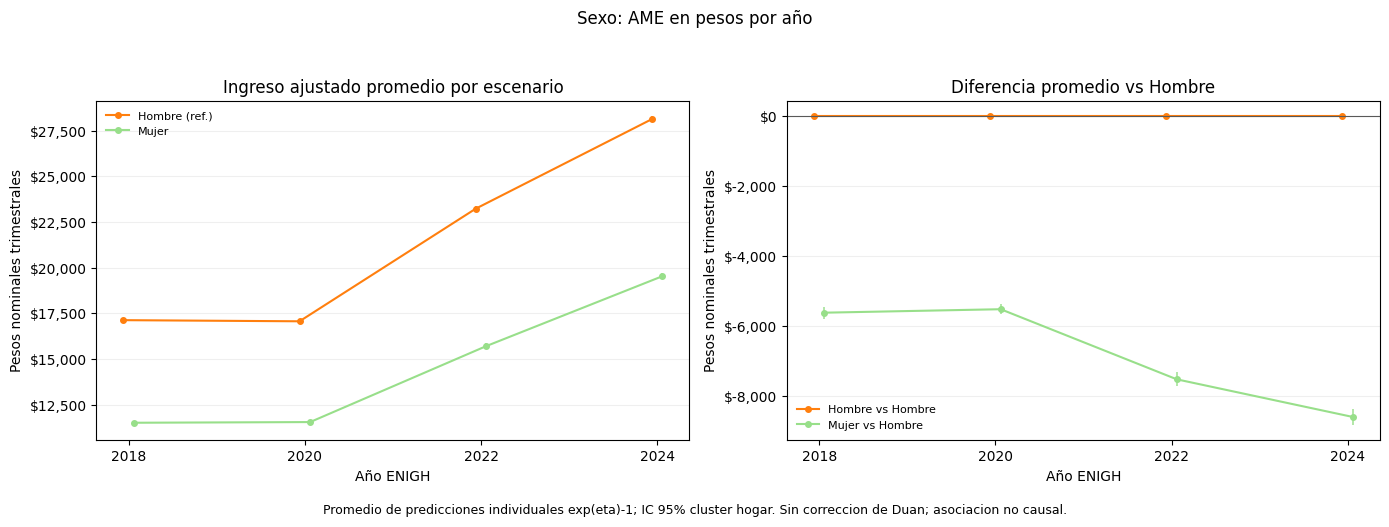

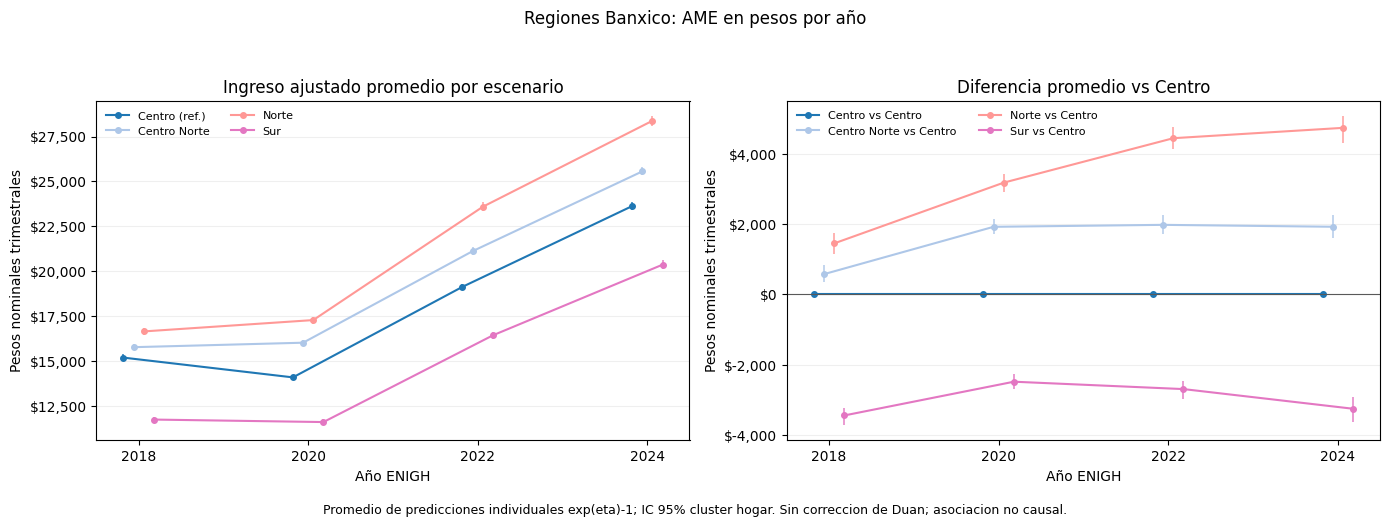

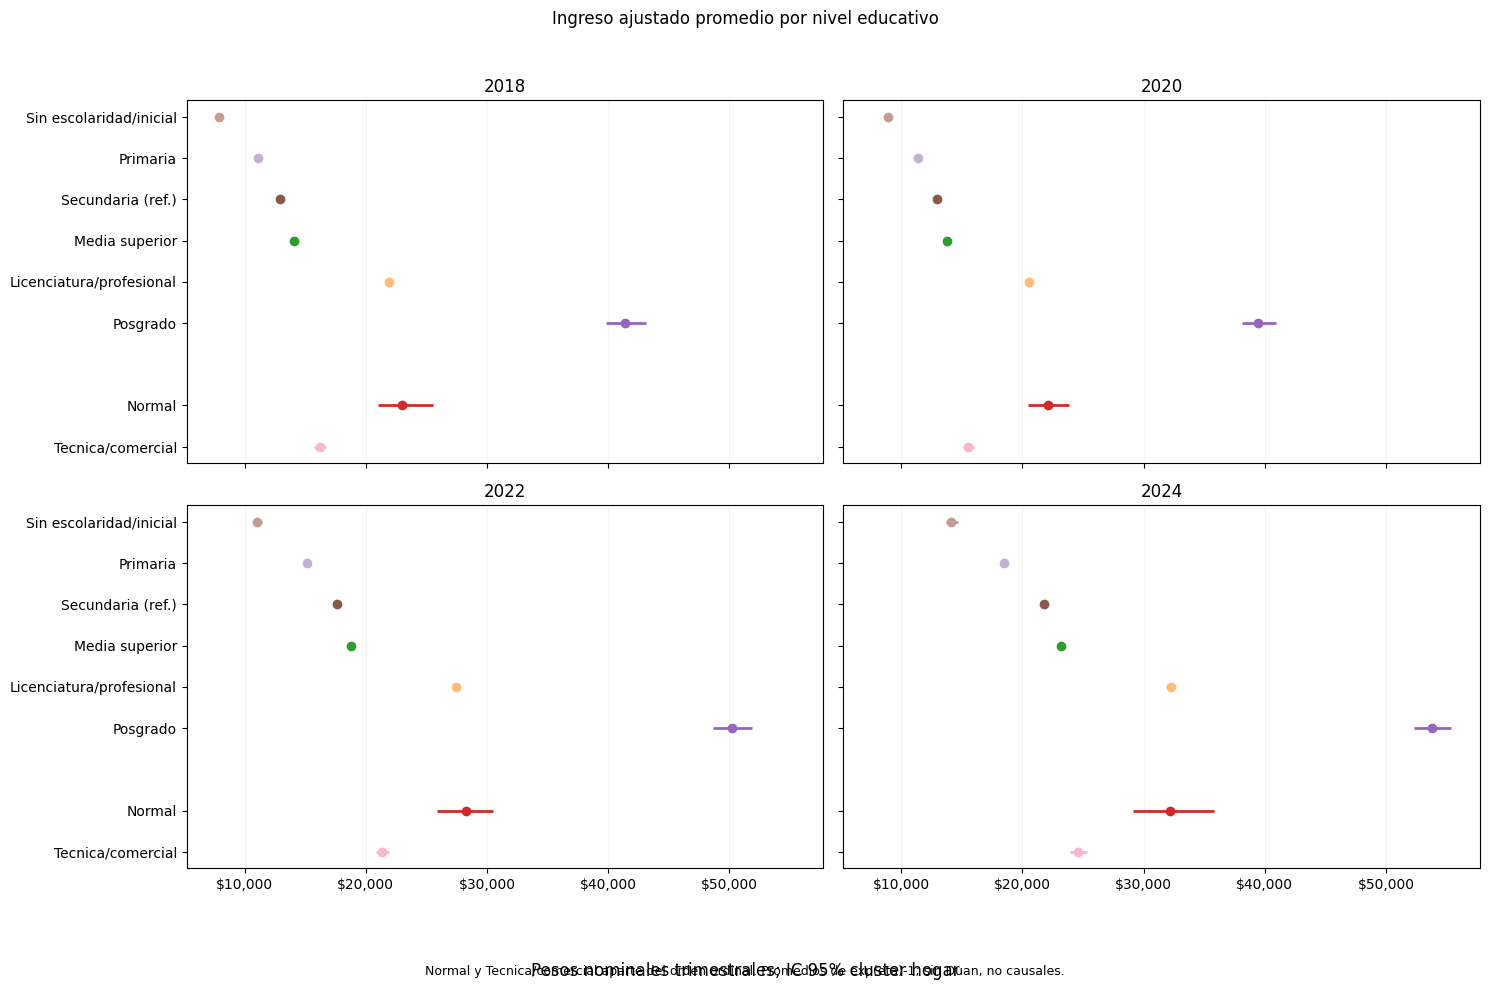

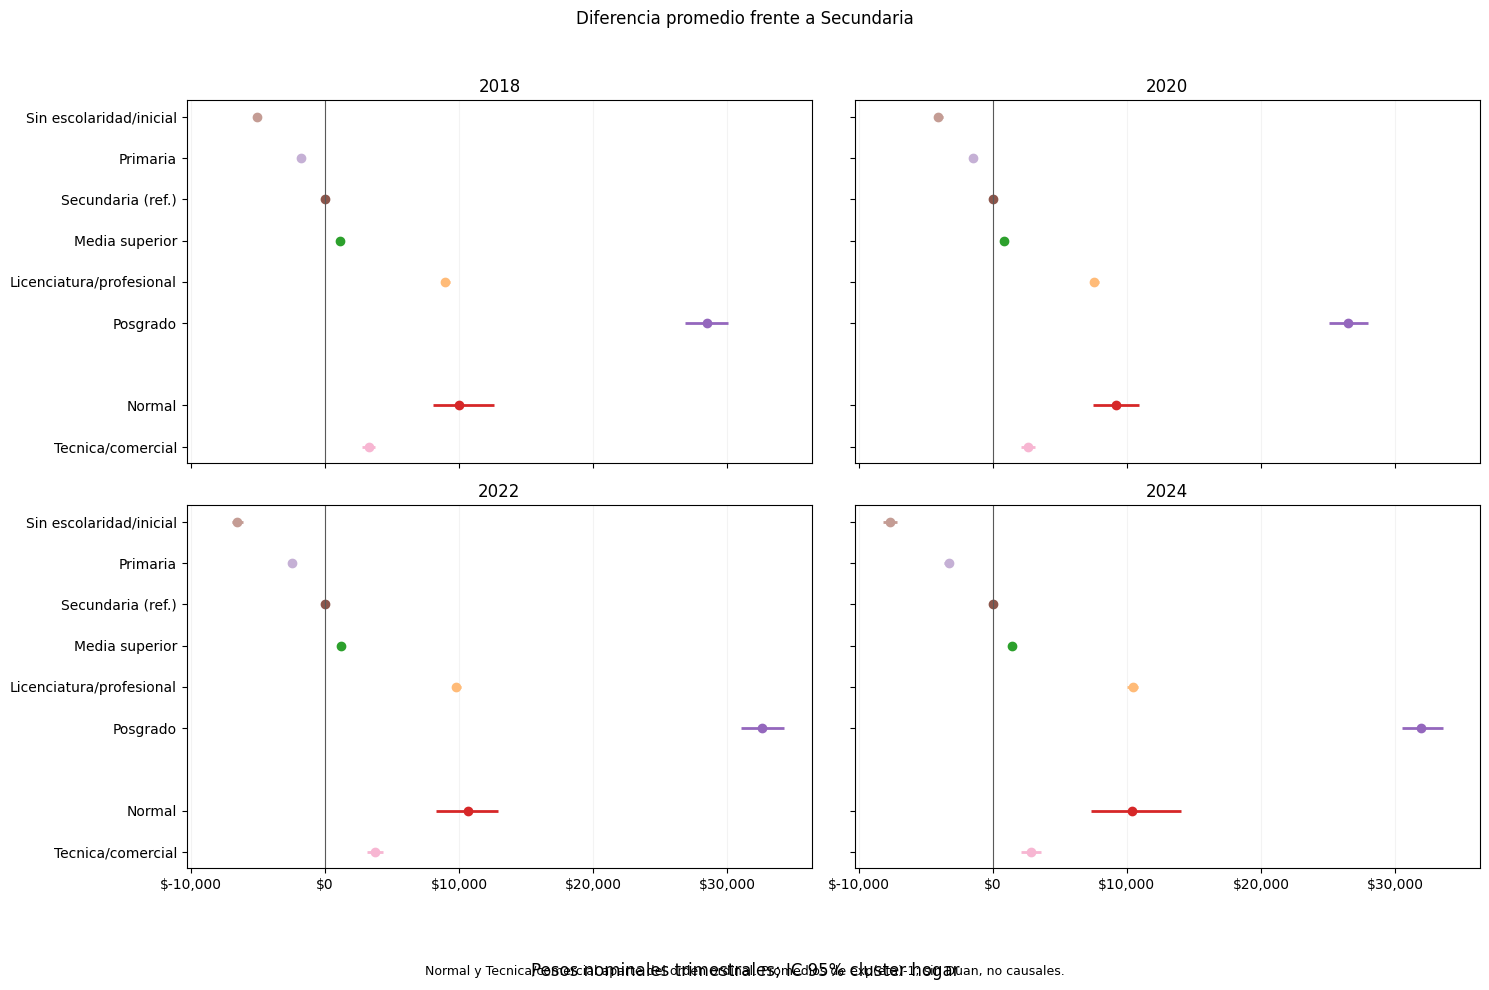

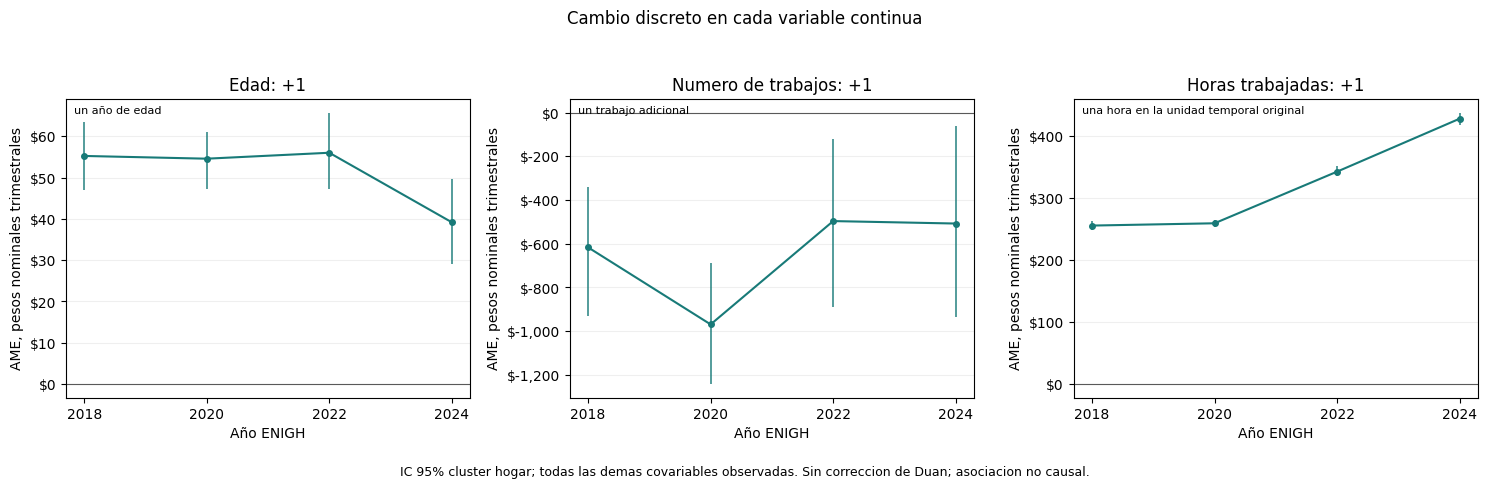

In [37]:
from matplotlib.ticker import FuncFormatter

formato_pesos = FuncFormatter(lambda x, _: "$" + format(x, ",.0f"))
colores_ame = {
    categoria: color for categoria, color in zip(
        sorted(set(
            CATEGORIAS_COMUNES["sexo_desc"]
            + CATEGORIAS_COMUNES["region_banxico"]
            + CATEGORIAS_COMUNES.get(VARIABLE_EDUCACION, [])
        )),
        sns.color_palette("tab20", 20).as_hex(),
    )
}


def trazar_serie_pesos(ax, tabla, valor, inferior, superior, etiqueta, color, desplazamiento=0):
    corte = tabla.sort_values("anio")
    if corte.anio.tolist() != ANIOS:
        raise ValueError(f"Serie monetaria incompleta: {etiqueta}")
    x = corte.anio.to_numpy(dtype=float) + desplazamiento
    y = corte[valor].to_numpy(dtype=float)
    low = corte[inferior].to_numpy(dtype=float)
    high = corte[superior].to_numpy(dtype=float)
    if not np.isfinite(np.concatenate([y, low, high])).all() or (low > high).any():
        raise ValueError(f"IC monetario invalido: {etiqueta}")
    ax.vlines(x, low, high, color=color, alpha=0.8, linewidth=1.3)
    ax.plot(x, y, "o-", color=color, linewidth=1.5, markersize=4, label=etiqueta)
    ax.set_xticks(ANIOS)
    ax.yaxis.set_major_formatter(formato_pesos)
    ax.grid(axis="y", alpha=0.2)


for variable, tabla, titulo, nombre in [
    ("sexo_desc", ingresos_ajustados_promedio_sexo, "Sexo", "sexo"),
    ("region_banxico", ingresos_ajustados_promedio_region, "Regiones Banxico", "region"),
]:
    categorias = CATEGORIAS_COMUNES[variable]
    referencia = REFERENCIAS[variable]
    if set(tabla.categoria_evaluada) != set(categorias):
        raise ValueError(f"{variable}: categorias incompletas para la figura.")
    fig, ejes = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True)
    for j, categoria in enumerate(categorias):
        corte = tabla.loc[tabla.categoria_evaluada.eq(categoria)]
        color = colores_ame[categoria]
        offset = (j - (len(categorias) - 1) / 2) * 0.12
        trazar_serie_pesos(
            ejes[0], corte, "ingreso_ajustado_promedio_categoria",
            "ci_categoria_inferior", "ci_categoria_superior",
            categoria + (" (ref.)" if categoria == referencia else ""),
            color, offset,
        )
        trazar_serie_pesos(
            ejes[1], corte, "efecto_marginal_promedio_pesos",
            "ci_inferior", "ci_superior",
            f"{categoria} vs {referencia}", color, offset,
        )
    ejes[0].set_title("Ingreso ajustado promedio por escenario")
    ejes[1].set_title(f"Diferencia promedio vs {referencia}")
    ejes[1].axhline(0, color="0.35", linewidth=0.8)
    for ax in ejes:
        ax.set_xlabel("Año ENIGH")
        ax.set_ylabel("Pesos nominales trimestrales")
        ax.legend(frameon=False, fontsize=8, ncol=2 if variable == "region_banxico" else 1)
    fig.suptitle(f"{titulo}: AME en pesos por año")
    fig.text(
        0.5, 0.01,
        "Promedio de predicciones individuales exp(eta)-1; IC 95% cluster hogar. "
        "Sin correccion de Duan; asociacion no causal.",
        ha="center", fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.04, 1, 0.94))
    figuras_temporales[f"{nombre}_ame_pesos_niveles_y_diferencias"] = fig
    display(fig)
    plt.close(fig)

if EJECUTAR_AMPLIADO:
    orden_educacion_ame = [
        "Sin escolaridad/inicial", "Primaria", "Secundaria", "Media superior",
        "Licenciatura/profesional", "Posgrado", "Normal", "Tecnica/comercial",
    ]
    if set(orden_educacion_ame) != set(CATEGORIAS_COMUNES[VARIABLE_EDUCACION]):
        raise ValueError("Revisar categorias educativas del AME.")
    posiciones_educacion_ame = {
        nivel: j + (1 if j >= 6 else 0)
        for j, nivel in enumerate(orden_educacion_ame)
    }
    for nombre_figura, valor, inferior, superior, titulo in [
        (
            "escolaridad_ame_pesos_niveles",
            "ingreso_ajustado_promedio_categoria",
            "ci_categoria_inferior", "ci_categoria_superior",
            "Ingreso ajustado promedio por nivel educativo",
        ),
        (
            "escolaridad_ame_pesos_diferencias",
            "efecto_marginal_promedio_pesos",
            "ci_inferior", "ci_superior",
            "Diferencia promedio frente a Secundaria",
        ),
    ]:
        fig, ejes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)
        for ax, anio in zip(ejes.flat, ANIOS):
            corte = ingresos_ajustados_promedio_escolaridad.loc[
                ingresos_ajustados_promedio_escolaridad.anio.eq(anio)
            ].set_index("categoria_evaluada")
            if set(corte.index) != set(orden_educacion_ame):
                raise ValueError(f"{anio}: niveles educativos faltantes en el AME.")
            for nivel in orden_educacion_ame:
                fila = corte.loc[nivel]
                y = posiciones_educacion_ame[nivel]
                ax.hlines(
                    y, float(fila[inferior]), float(fila[superior]),
                    color=colores_ame[nivel], linewidth=2,
                )
                ax.plot(float(fila[valor]), y, "o", color=colores_ame[nivel])
            if "diferencias" in nombre_figura:
                ax.axvline(0, color="0.35", linewidth=0.8)
            ax.set_yticks(
                [posiciones_educacion_ame[n] for n in orden_educacion_ame],
                [n + (" (ref.)" if n == "Secundaria" else "") for n in orden_educacion_ame],
            )
            ax.xaxis.set_major_formatter(formato_pesos)
            ax.set_title(str(anio))
            ax.grid(axis="x", alpha=0.15)
        ejes[0, 0].invert_yaxis()
        fig.suptitle(titulo)
        fig.supxlabel("Pesos nominales trimestrales; IC 95% cluster hogar")
        fig.text(
            0.5, 0.015,
            "Normal y Tecnica/comercial aparte del orden ordinal. "
            "Promedios de exp(eta)-1; sin Duan, no causales.",
            ha="center", fontsize=9,
        )
        fig.tight_layout(rect=(0, 0.05, 1, 0.96))
        figuras_temporales[nombre_figura] = fig
        display(fig)
        plt.close(fig)

continuas_cluster_ame = efectos_marginales_promedio_pesos_continuas.loc[
    efectos_marginales_promedio_pesos_continuas.origen_modelo.eq("anual")
    & efectos_marginales_promedio_pesos_continuas.tipo_covarianza.eq(
        COVARIANZA_INFERENCIA_PRINCIPAL
    )
]
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True)
nombres_continuas_ame = {
    "edad": "Edad", "horas_trabajos_total": "Horas trabajadas",
    "n_trabajos": "Numero de trabajos",
}
for ax, variable in zip(ejes, variables_comunes_numericas):
    corte = continuas_cluster_ame.loc[continuas_cluster_ame.variable.eq(variable)]
    trazar_serie_pesos(
        ax, corte, "efecto_marginal_promedio_pesos",
        "ci_inferior", "ci_superior", f"+{INCREMENTOS_AME_PESOS[variable]:g}",
        "#187a78",
    )
    ax.axhline(0, color="0.35", linewidth=0.8)
    ax.set_title(f"{nombres_continuas_ame[variable]}: +{INCREMENTOS_AME_PESOS[variable]:g}")
    ax.set_xlabel("Año ENIGH")
    ax.set_ylabel("AME, pesos nominales trimestrales")
    ax.text(0.02, 0.98, UNIDADES_CONTINUAS[variable], transform=ax.transAxes,
            va="top", fontsize=8)
fig.suptitle("Cambio discreto en cada variable continua")
fig.text(
    0.5, 0.01,
    "IC 95% cluster hogar; todas las demas covariables observadas. "
    "Sin correccion de Duan; asociacion no causal.",
    ha="center", fontsize=9,
)
fig.tight_layout(rect=(0, 0.05, 1, 0.94))
figuras_temporales["continuas_ame_pesos_por_anio"] = fig
display(fig)
plt.close(fig)

## 13. Porcentajes y perfil comun (complementarios)

Las siguientes figuras mantienen los porcentajes de 1+ingreso, las predicciones de un perfil fijo y la sensibilidad de IC HC3/cluster del analisis previo. No sustituyen los efectos marginales promedio en pesos calculados sobre todas las personas.

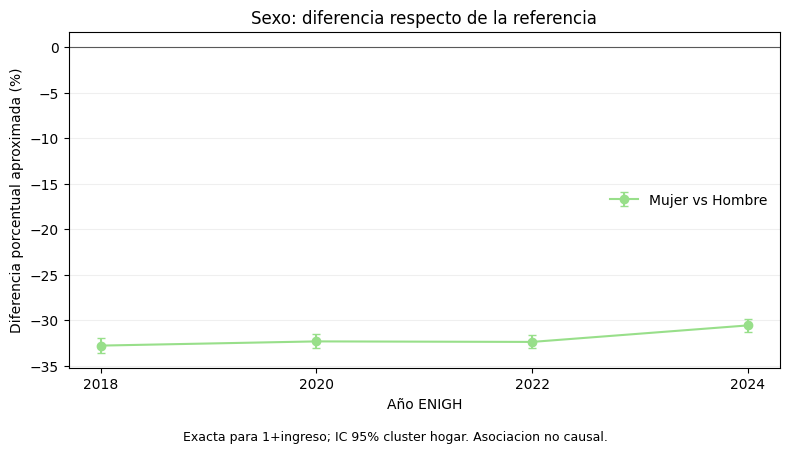

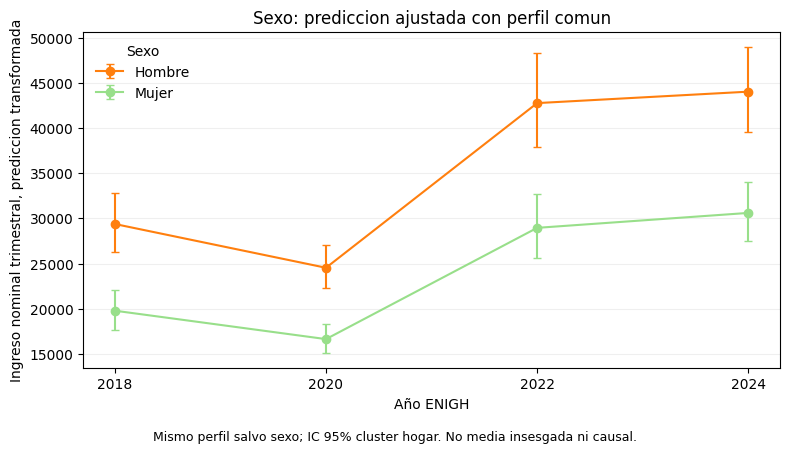

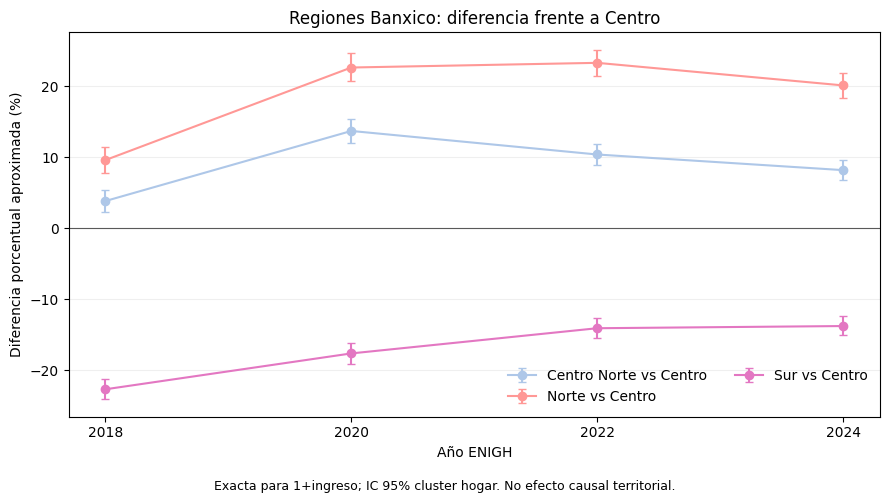

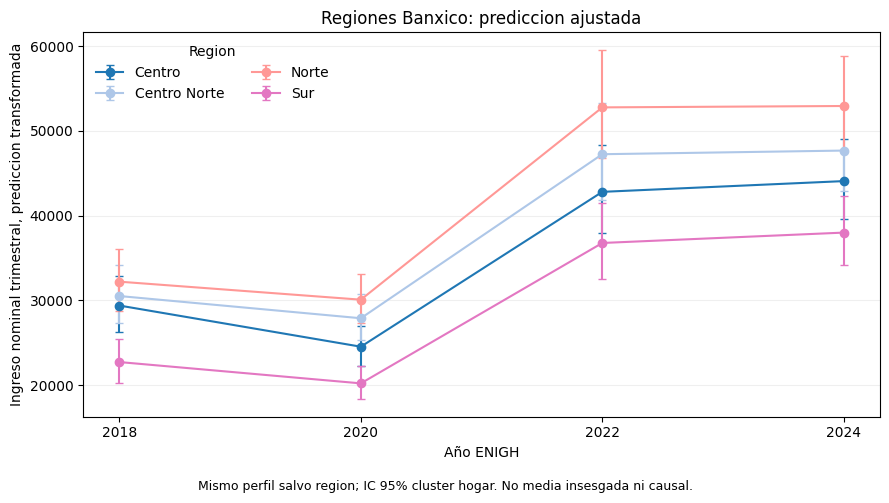

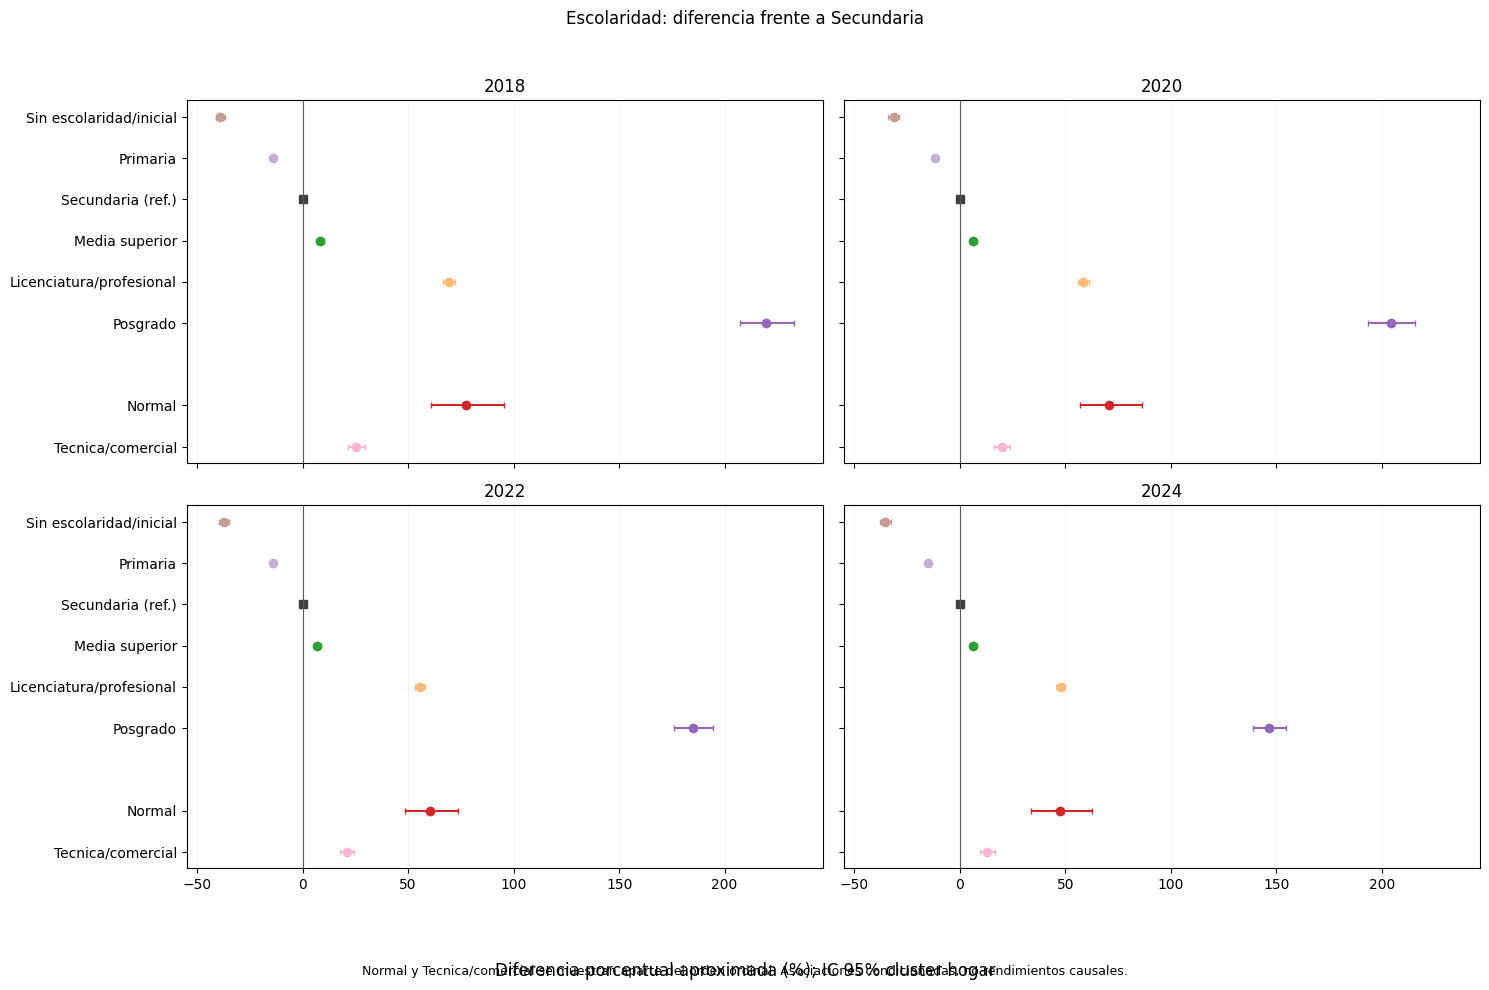

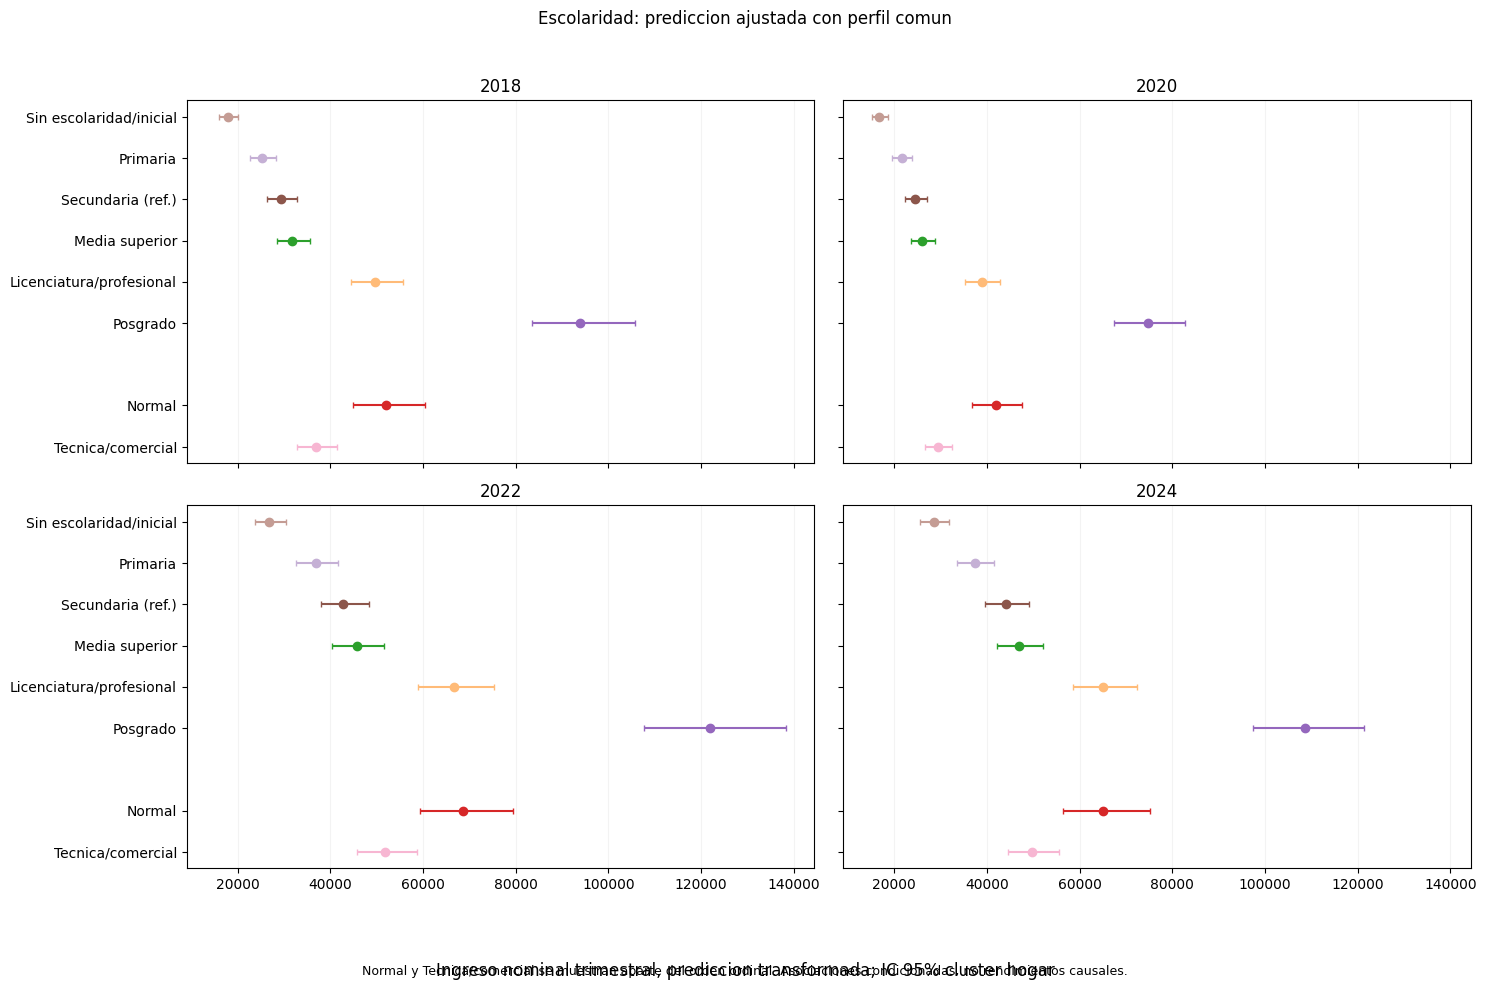

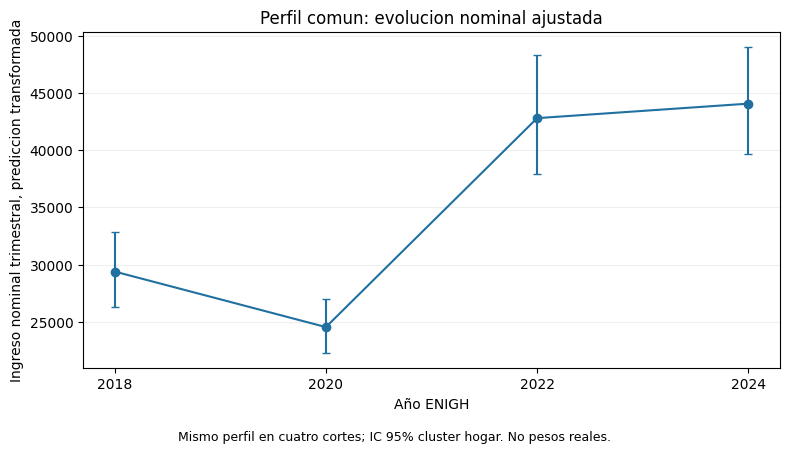

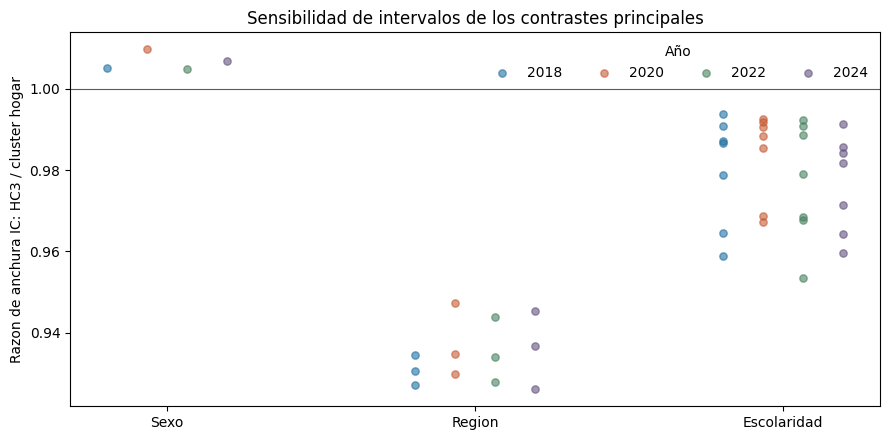

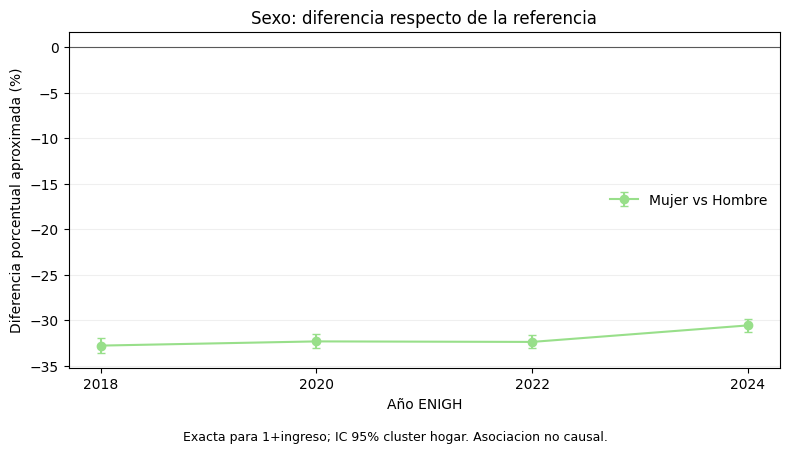

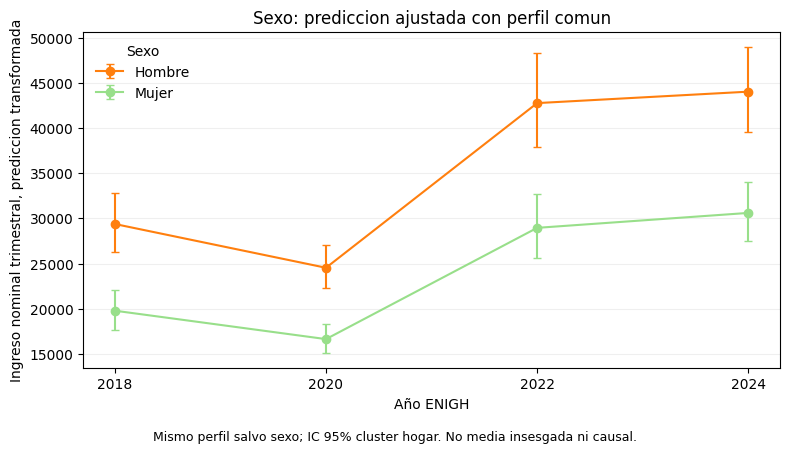

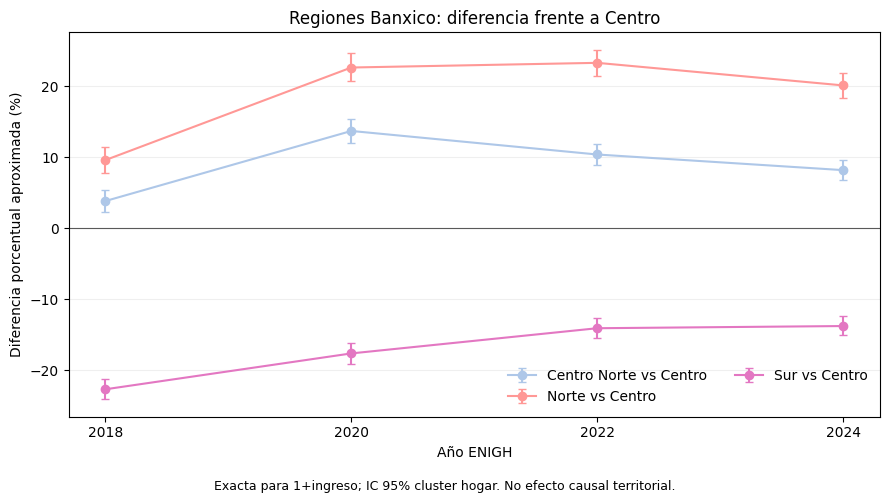

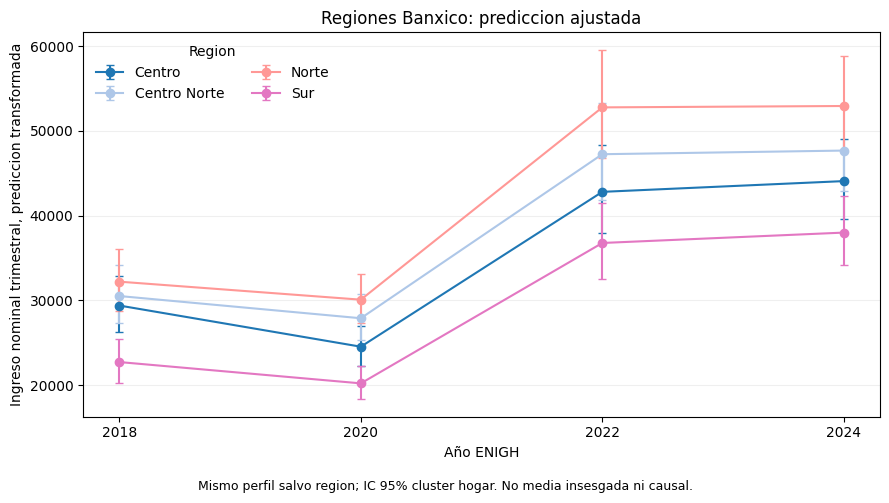

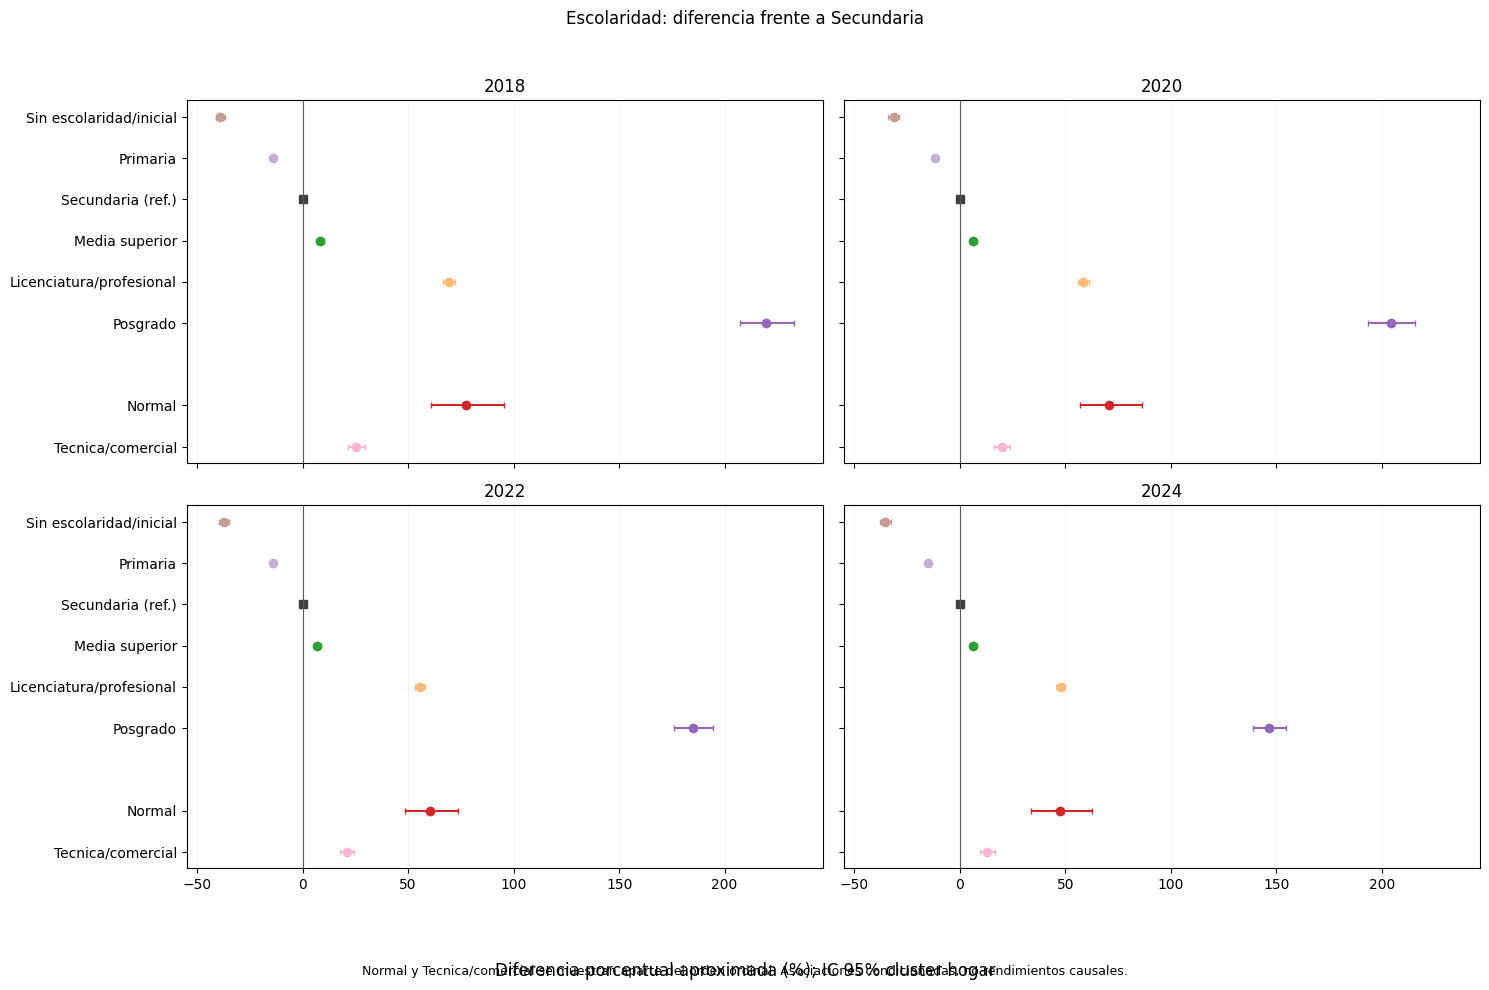

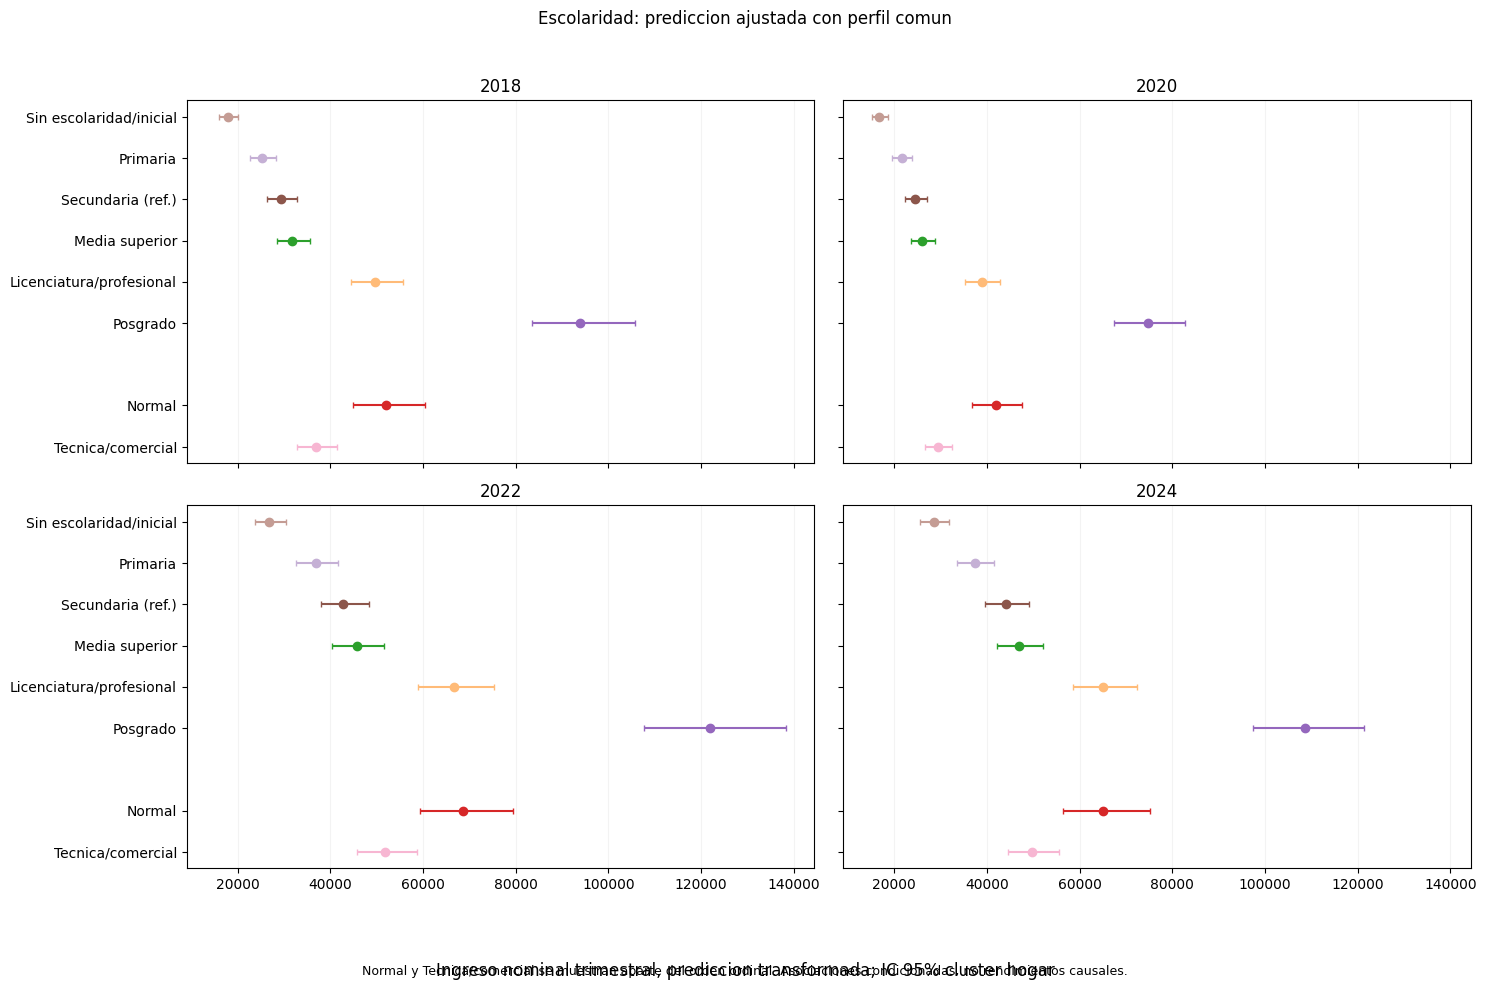

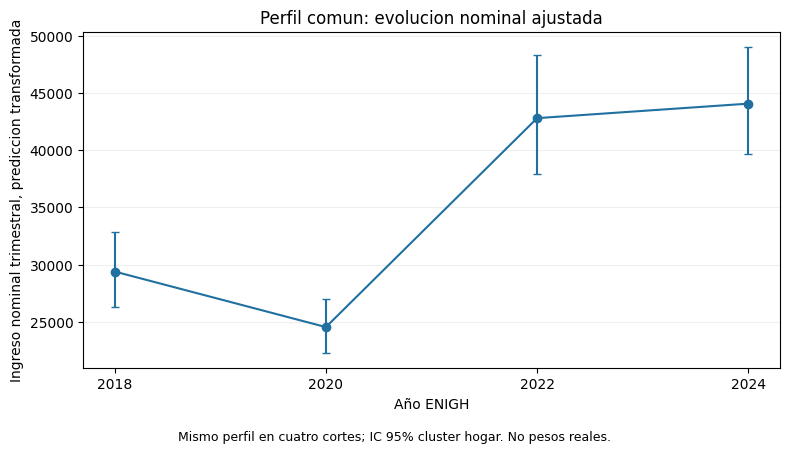

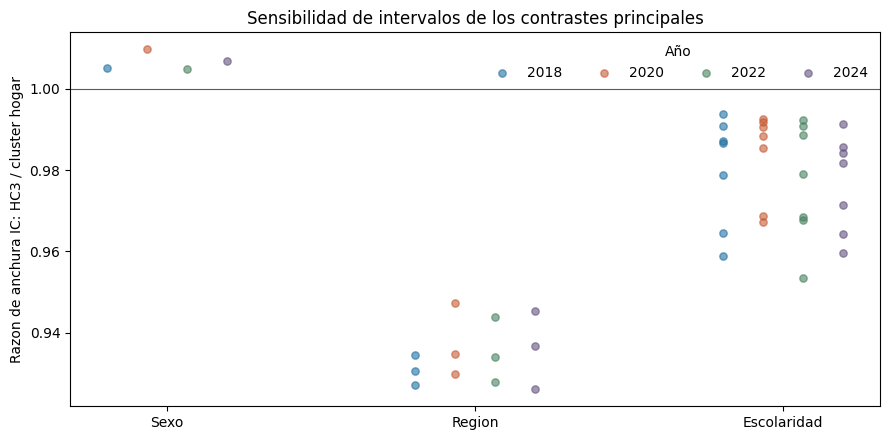

In [38]:
def dibujar_serie_anual(ax, tabla, valor, inferior, superior, etiqueta, color):
    corte = tabla.sort_values("anio")
    if corte.anio.tolist() != ANIOS:
        raise ValueError(f"Serie temporal incompleta: {etiqueta}")
    centro = corte[valor].to_numpy(dtype=float)
    ax.errorbar(
        corte.anio.to_numpy(dtype=int), centro,
        yerr=[centro - corte[inferior].to_numpy(dtype=float),
              corte[superior].to_numpy(dtype=float) - centro],
        fmt="o-", color=color, capsize=3, linewidth=1.5, label=etiqueta,
    )
    ax.set_xticks(ANIOS)
    ax.grid(axis="y", alpha=0.2)


efectos_cluster = efectos_porcentuales_modelos_anuales.loc[
    efectos_porcentuales_modelos_anuales.tipo_covarianza.eq(
        COVARIANZA_INFERENCIA_PRINCIPAL
    )
]
predicciones_cluster = {
    "perfil": predicciones_ajustadas_perfil_por_anio.loc[
        predicciones_ajustadas_perfil_por_anio.tipo_covarianza.eq(
            COVARIANZA_INFERENCIA_PRINCIPAL
        )
    ],
    "sexo": predicciones_ajustadas_sexo.loc[
        predicciones_ajustadas_sexo.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL)
    ],
    "region": predicciones_ajustadas_region.loc[
        predicciones_ajustadas_region.tipo_covarianza.eq(COVARIANZA_INFERENCIA_PRINCIPAL)
    ],
    "escolaridad": predicciones_ajustadas_escolaridad.loc[
        predicciones_ajustadas_escolaridad.tipo_covarianza.eq(
            COVARIANZA_INFERENCIA_PRINCIPAL
        )
    ],
}
colores_categoria = {
    categoria: color
    for categoria, color in zip(
        sorted(set(CATEGORIAS_COMUNES["sexo_desc"]
                   + CATEGORIAS_COMUNES["region_banxico"]
                   + CATEGORIAS_COMUNES.get(VARIABLE_EDUCACION, []))),
        sns.color_palette("tab20", 16).as_hex(),
    )
}

fig, ax = plt.subplots(figsize=(8, 4.5))
sexo_efectos = efectos_cluster.loc[efectos_cluster.variable.eq("sexo_desc")]
for categoria in CATEGORIAS_COMUNES["sexo_desc"][1:]:
    corte = sexo_efectos.loc[sexo_efectos.categoria.eq(categoria)]
    dibujar_serie_anual(
        ax, corte, "efecto_porcentual",
        "efecto_porcentual_ci_inferior", "efecto_porcentual_ci_superior",
        f"{categoria} vs {REFERENCIAS['sexo_desc']}", colores_categoria[categoria],
    )
ax.axhline(0, color="0.35", linewidth=0.8)
ax.set_title("Sexo: diferencia respecto de la referencia")
ax.set_ylabel("Diferencia porcentual aproximada (%)")
ax.set_xlabel("Año ENIGH")
ax.legend(frameon=False)
fig.text(0.5, 0.01, "Exacta para 1+ingreso; IC 95% cluster hogar. Asociacion no causal.",
         ha="center", fontsize=9)
fig.tight_layout(rect=(0, 0.04, 1, 1))
figuras_temporales["sexo_efecto_porcentual"] = fig
display(fig)

fig, ax = plt.subplots(figsize=(8, 4.5))
for categoria in CATEGORIAS_COMUNES["sexo_desc"]:
    corte = predicciones_cluster["sexo"].loc[
        predicciones_cluster["sexo"].categoria.eq(categoria)
    ]
    dibujar_serie_anual(
        ax, corte, "prediccion_transformada",
        "ci_transformado_inferior", "ci_transformado_superior",
        categoria, colores_categoria[categoria],
    )
ax.set_title("Sexo: prediccion ajustada con perfil comun")
ax.set_ylabel("Ingreso nominal trimestral, prediccion transformada")
ax.set_xlabel("Año ENIGH")
ax.legend(title="Sexo", frameon=False)
fig.text(0.5, 0.01, "Mismo perfil salvo sexo; IC 95% cluster hogar. No media insesgada ni causal.",
         ha="center", fontsize=9)
fig.tight_layout(rect=(0, 0.04, 1, 1))
figuras_temporales["sexo_prediccion_ajustada"] = fig
display(fig)

fig, ax = plt.subplots(figsize=(9, 5))
region_efectos = efectos_cluster.loc[
    efectos_cluster.variable.eq("region_banxico")
]
for categoria in CATEGORIAS_COMUNES["region_banxico"][1:]:
    corte = region_efectos.loc[region_efectos.categoria.eq(categoria)]
    dibujar_serie_anual(
        ax, corte, "efecto_porcentual",
        "efecto_porcentual_ci_inferior", "efecto_porcentual_ci_superior",
        f"{categoria} vs Centro", colores_categoria[categoria],
    )
ax.axhline(0, color="0.35", linewidth=0.8)
ax.set_title("Regiones Banxico: diferencia frente a Centro")
ax.set_ylabel("Diferencia porcentual aproximada (%)")
ax.set_xlabel("Año ENIGH")
ax.legend(frameon=False, ncol=2)
fig.text(0.5, 0.01, "Exacta para 1+ingreso; IC 95% cluster hogar. No efecto causal territorial.",
         ha="center", fontsize=9)
fig.tight_layout(rect=(0, 0.04, 1, 1))
figuras_temporales["region_efecto_porcentual"] = fig
display(fig)

fig, ax = plt.subplots(figsize=(9, 5))
for categoria in CATEGORIAS_COMUNES["region_banxico"]:
    corte = predicciones_cluster["region"].loc[
        predicciones_cluster["region"].categoria.eq(categoria)
    ]
    dibujar_serie_anual(
        ax, corte, "prediccion_transformada",
        "ci_transformado_inferior", "ci_transformado_superior",
        categoria, colores_categoria[categoria],
    )
ax.set_title("Regiones Banxico: prediccion ajustada")
ax.set_ylabel("Ingreso nominal trimestral, prediccion transformada")
ax.set_xlabel("Año ENIGH")
ax.legend(title="Region", frameon=False, ncol=2)
fig.text(0.5, 0.01, "Mismo perfil salvo region; IC 95% cluster hogar. No media insesgada ni causal.",
         ha="center", fontsize=9)
fig.tight_layout(rect=(0, 0.04, 1, 1))
figuras_temporales["region_prediccion_ajustada"] = fig
display(fig)

if EJECUTAR_AMPLIADO:
    orden_educacion = [
        "Sin escolaridad/inicial", "Primaria", "Secundaria", "Media superior",
        "Licenciatura/profesional", "Posgrado", "Normal", "Tecnica/comercial",
    ]
    if set(orden_educacion) != set(CATEGORIAS_COMUNES[VARIABLE_EDUCACION]):
        raise ValueError("Revisar orden de categorias educativas para la figura.")
    posiciones = {nivel: i + (1 if i >= 6 else 0)
                  for i, nivel in enumerate(orden_educacion)}
    for nombre_figura, tabla, valor, inferior, superior, titulo, eje_x in [
        (
            "escolaridad_prima_porcentual",
            efectos_cluster.loc[efectos_cluster.variable.eq(VARIABLE_EDUCACION)],
            "efecto_porcentual", "efecto_porcentual_ci_inferior",
            "efecto_porcentual_ci_superior",
            "Escolaridad: diferencia frente a Secundaria",
            "Diferencia porcentual aproximada (%)",
        ),
        (
            "escolaridad_prediccion_ajustada",
            predicciones_cluster["escolaridad"],
            "prediccion_transformada", "ci_transformado_inferior",
            "ci_transformado_superior",
            "Escolaridad: prediccion ajustada con perfil comun",
            "Ingreso nominal trimestral, prediccion transformada",
        ),
    ]:
        fig, ejes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)
        for ax, anio in zip(ejes.flat, ANIOS):
            corte = tabla.loc[tabla.anio.eq(anio)]
            for nivel in orden_educacion:
                if nombre_figura == "escolaridad_prima_porcentual" and nivel == "Secundaria":
                    ax.plot(0, posiciones[nivel], "s", color="0.25")
                    continue
                fila = corte.loc[corte.categoria.eq(nivel)]
                if len(fila) != 1:
                    raise ValueError(f"{anio}: categoria educativa ausente o duplicada: {nivel}")
                fila = fila.iloc[0]
                ax.errorbar(
                    float(fila[valor]), posiciones[nivel],
                    xerr=[[float(fila[valor] - fila[inferior])],
                          [float(fila[superior] - fila[valor])]],
                    fmt="o", capsize=2, color=colores_categoria[nivel],
                )
            if nombre_figura == "escolaridad_prima_porcentual":
                ax.axvline(0, color="0.35", linewidth=0.8)
            ax.set_yticks(
                [posiciones[nivel] for nivel in orden_educacion],
                [nivel + (" (ref.)" if nivel == "Secundaria" else "")
                 for nivel in orden_educacion],
            )
            ax.set_title(str(anio))
            ax.grid(axis="x", alpha=0.15)
        ejes[0, 0].invert_yaxis()
        fig.suptitle(titulo)
        fig.supxlabel(eje_x + "; IC 95% cluster hogar")
        fig.text(
            0.5, 0.015,
            "Normal y Tecnica/comercial se muestran aparte del orden ordinal. "
            "Asociaciones condicionadas, no rendimientos causales.",
            ha="center", fontsize=9,
        )
        fig.tight_layout(rect=(0, 0.05, 1, 0.96))
        figuras_temporales[nombre_figura] = fig
        display(fig)

fig, ax = plt.subplots(figsize=(8, 4.5))
dibujar_serie_anual(
    ax, predicciones_cluster["perfil"],
    "prediccion_transformada", "ci_transformado_inferior",
    "ci_transformado_superior", "Perfil comun", "#2070a0",
)
ax.set_title("Perfil comun: evolucion nominal ajustada")
ax.set_xlabel("Año ENIGH")
ax.set_ylabel("Ingreso nominal trimestral, prediccion transformada")
fig.text(0.5, 0.01, "Mismo perfil en cuatro cortes; IC 95% cluster hogar. No pesos reales.",
         ha="center", fontsize=9)
fig.tight_layout(rect=(0, 0.04, 1, 1))
figuras_temporales["perfil_comun_nominal"] = fig
display(fig)

sensibilidad_figura = sensibilidad_intervalos_cluster_hc3.loc[
    sensibilidad_intervalos_cluster_hc3.variable.isin(
        ["sexo_desc", "region_banxico", VARIABLE_EDUCACION]
    )
]
fig, ax = plt.subplots(figsize=(9, 4.5))
variables_sensibilidad = ["sexo_desc", "region_banxico"] + (
    [VARIABLE_EDUCACION] if EJECUTAR_AMPLIADO else []
)
for j, anio in enumerate(ANIOS):
    corte = sensibilidad_figura.loc[sensibilidad_figura.anio.eq(anio)]
    for i, variable in enumerate(variables_sensibilidad):
        valores = corte.loc[
            corte.variable.eq(variable), "razon_anchura_hc3_cluster"
        ].to_numpy(dtype=float)
        ax.scatter(
            np.full(len(valores), i + (j - 1.5) * 0.13), valores,
            color=colores_anio[anio], alpha=0.6, s=28,
            label=str(anio) if i == 0 else None,
        )
ax.axhline(1, color="0.35", linewidth=0.8)
ax.set_xticks(range(len(variables_sensibilidad)),
              ["Sexo", "Region", "Escolaridad"][:len(variables_sensibilidad)])
ax.set_ylabel("Razon de anchura IC: HC3 / cluster hogar")
ax.set_title("Sensibilidad de intervalos de los contrastes principales")
ax.legend(title="Año", frameon=False, ncol=4)
fig.tight_layout()
figuras_temporales["sensibilidad_intervalos_cluster_hc3"] = fig
display(fig)

## 14. Exportacion al final

Todas las tablas y figuras provienen de objetos creados durante **esta misma ejecucion manual**. El manifest registra la homologacion preparada y el estado pendiente de revision humana; esta edicion estatica no produjo resultados. Los outputs manuales previos se conservan en el archivo de trabajo, pero al ejecutar esta version deben regenerarse; no se leen coeficientes ni graficas anteriores.

In [39]:
tablas_salida = {
    "auditoria_bases_temporales": auditoria_bases_temporales,
    "comparabilidad_variables": comparabilidad_variables,
    "referencias_categoricas": referencias_categoricas,
    "auditoria_escolaridad_por_anio": auditoria_escolaridad_por_anio,
    "mapeo_escolaridad_homologada": mapeo_escolaridad_homologada,
    "frecuencias_escolaridad_homologada": frecuencias_escolaridad_homologada,
    "comparacion_modelo_nucleo_ampliado": comparacion_modelo_nucleo_ampliado,
    "coeficientes_escolaridad_por_anio": coeficientes_escolaridad_por_anio,
    "pruebas_conjuntas_escolaridad": pruebas_conjuntas_escolaridad,
    "interacciones_escolaridad_anio": interacciones_escolaridad_anio,
    "validaciones_escolaridad": validaciones_escolaridad,
    "metricas_modelos_anuales": metricas_modelos_anuales,
    "coeficientes_modelos_anuales": coeficientes_modelos_anuales,
    "pruebas_conjuntas_anuales": pruebas_conjuntas_anuales,
    "coeficientes_modelo_pooled": coeficientes_modelo_pooled,
    "efectos_totales_interacciones": efectos_totales_interacciones,
    "pruebas_wald_temporales": pruebas_wald_temporales,
    "comparacion_geografica": comparacion_geografica,
    "antecedentes_2024": antecedentes_2024,
    "efectos_porcentuales_modelos_anuales": efectos_porcentuales_modelos_anuales,
    "efectos_porcentuales_interacciones": efectos_porcentuales_interacciones,
    "interceptos_transformados": interceptos_transformados,
    "perfil_representativo_comun": perfil_representativo_comun,
    "predicciones_ajustadas_perfil_por_anio": predicciones_ajustadas_perfil_por_anio,
    "predicciones_ajustadas_sexo": predicciones_ajustadas_sexo,
    "predicciones_ajustadas_region": predicciones_ajustadas_region,
    "predicciones_ajustadas_escolaridad": predicciones_ajustadas_escolaridad,
    "sensibilidad_intervalos_cluster_hc3": sensibilidad_intervalos_cluster_hc3,
    "efectos_marginales_promedio_pesos_categoricas": efectos_marginales_promedio_pesos_categoricas,
    "efectos_marginales_promedio_pesos_continuas": efectos_marginales_promedio_pesos_continuas,
    "ingresos_ajustados_promedio_sexo": ingresos_ajustados_promedio_sexo,
    "ingresos_ajustados_promedio_region": ingresos_ajustados_promedio_region,
    "ingresos_ajustados_promedio_escolaridad": ingresos_ajustados_promedio_escolaridad,
    "interceptos_tecnicos_pesos": interceptos_tecnicos_pesos,
    "sensibilidad_ame_pesos_cluster_hc3": sensibilidad_ame_pesos_cluster_hc3,
}
manifest_comparacion_temporal = {
    "estado": "pendiente_ejecucion_manual",
    "nota_estado": "Notebook preparado; resultados requieren ejecucion y revision humana.",
    "unidad_analisis": "persona",
    "universo": "edad>=18 e ingreso laboral/de negocio individual nominal trimestral>0",
    "anios": ANIOS,
    "anio_referencia": ANIO_REFERENCIA,
    "archivos_entrada": {
        str(anio): str(ruta.relative_to(PROJECT_ROOT))
        for anio, ruta in INPUTS.items()
    },
    "variables_comunes_numericas": variables_comunes_numericas,
    "variables_comunes_categoricas": variables_comunes_categoricas,
    "geografia_principal": variable_geografica_regional,
    "geografia_sensibilidad": variable_geografica_estatal
                              if EJECUTAR_ESPECIFICACION_ENTIDAD else [],
    "variables_ampliadas": [VARIABLE_EDUCACION] if EJECUTAR_AMPLIADO else [],
    "variable_escolaridad_original": "nivelaprob_desc",
    "variable_escolaridad_homologada": VARIABLE_EDUCACION,
    "codigo_educativo_en_base": False,
    "mapeo_escolaridad": mapeo_escolaridad_homologada.to_dict(orient="records"),
    "validaciones_escolaridad": validaciones_escolaridad.to_dict(orient="records"),
    "categorias_escolaridad": CATEGORIAS_COMUNES.get(VARIABLE_EDUCACION, []),
    "referencia_escolaridad": REFERENCIAS[VARIABLE_EDUCACION],
    "anios_escolaridad": ANIOS,
    "modelo_principal": ESPECIFICACION_PRINCIPAL if EJECUTAR_AMPLIADO else "nucleo_preliminar",
    "modelo_nucleo_sin_escolaridad": "regional_nucleo",
    "modelo_ampliado_con_escolaridad": "regional_ampliado" if EJECUTAR_AMPLIADO else None,
    "estado_escolaridad": estado_escolaridad,
    "variables_pendientes": variables_pendientes,
    "referencias": REFERENCIAS,
    "categorias_comunes": CATEGORIAS_COMUNES,
    "targets": {
        str(anio): nombres_targets(anio) for anio in ANIOS
    },
    "target_modelo_principal": LOG_NOMINAL,
    "target_principal_semantico": TARGET_PRINCIPAL,
    "target_real_aprox_es_sensibilidad": TARGET_REAL_APROX_ES_SENSIBILIDAD,
    "target_real_aprox_activado": EJECUTAR_TARGET_REAL_APROX,
    "target_modelo_secundario": "nivel_nominal",
    "formula_efecto_porcentual": "100 * (exp(k * beta_log) - 1)",
    "ame_pesos_definicion": (
        "Promedio sobre todas las personas de cada año de [exp(eta_escenario)-1] "
        "menos [exp(eta_referencia)-1], conservando las demas covariables observadas."
    ),
    "ame_pesos_muestra": "muestra analitica completa del modelo OLS principal por año; peso 1 por persona",
    "ame_pesos_periodicidad": "trimestral",
    "ame_pesos_montos": "nominales",
    "ame_pesos_incrementos_continuas": INCREMENTOS_AME_PESOS,
    "ame_pesos_categorias_referencia": {
        variable: REFERENCIAS[variable] for variable in CATEGORICAS_AME_PESOS
    },
    "ame_pesos_modelos": ["anual"] + (
        ["pooled_interacciones"] if CALCULAR_AME_POOLED_INTERACCIONES else []
    ),
    "ame_pesos_metodo_ic": "simulacion normal multivariada de coeficientes, percentiles 2.5 y 97.5",
    "ame_pesos_semilla": SEMILLA_AME_PESOS,
    "ame_pesos_simulaciones": SIMULACIONES_AME_PESOS,
    "ame_pesos_tamano_lote": TAM_LOTE_AME_PESOS,
    "ame_pesos_covarianza_principal": COVARIANZA_INFERENCIA_PRINCIPAL,
    "ame_pesos_covarianza_sensibilidad": COVARIANZA_SENSIBILIDAD,
    "ame_pesos_retransformacion": (
        "exp(eta)-1 es prediccion transformada de log1p; sin correccion de Duan "
        "no es estimacion insesgada de la media condicional."
    ),
    "ame_pesos_alcance": "asociacion ajustada descriptiva, no efecto causal",
    "incremento_tablas_continuas": INCREMENTO_TABLAS_CONTINUAS,
    "transformacion_aplicable": "solo targets log; intercepto tecnico separado; interacciones como efectos totales",
    "perfil_representativo": perfil_representativo_comun.to_dict(orient="records"),
    "regla_perfil": "medianas numericas pooled y referencias categoricas; mismos valores en cuatro años",
    "prediccion_escala_original": "exp(predictor_lineal_estimado)-1; transformada, no media insesgada",
    "interpretacion_log1p": "porcentaje exacto de 1+ingreso; aproximacion para ingreso original",
    "advertencia_perfil": "intercepto tecnico en ceros no es ingreso tipico; predicciones son nominales y no causales",
    "estimadores": ["OLS"] + (
        ["WLS_sensibilidad"] if PONDERADOS_EJECUTADOS else []
    ),
    "covarianzas_anuales": ["convencional", "HC3", "cluster_hogar"],
    "covarianza_inferencia_principal": COVARIANZA_INFERENCIA_PRINCIPAL,
    "covarianza_sensibilidad": COVARIANZA_SENSIBILIDAD,
    "covarianza_interacciones": COVARIANZA_INFERENCIA_PRINCIPAL,
    "grupo_cluster_pooled": "id_hogar_anio",
    "interacciones": variables_interaccion,
    "interacciones_completas": EJECUTAR_INTERACCIONES_COMPLETAS,
    "ponderacion_sensibilidad_ejecutada": PONDERADOS_EJECUTADOS,
    "normalizacion_factor": "factor/media(factor) dentro de cada año",
    "diseno": "factor, est_dis, upm disponibles; WLS+EE hogar no es diseño complejo completo",
    "advertencia_monetaria": (
        "Factor anual calibrado al benchmark de ingreso corriente del hogar; "
        "uso en ingreso laboral individual pendiente de aprobacion metodologica."
    ),
    "limitaciones": [
        "asociaciones condicionadas, no efectos causales",
        "categorias educativas amplias pierden detalle; Especialidad solo en 2024",
        "experiencia potencial, calidad educativa y campo de estudio no controlados",
        "montos/interceptos nominales no son pesos reales comparables",
        "efectos fijos de año no sustituyen un deflactor individual aprobado",
        "log1p(factor*ingreso) no equivale exactamente a log1p(ingreso)+log(factor)",
        "EE hogar no reproduce diseño ENIGH completo",
    ],
    "metodo": "asociaciones condicionadas en cortes transversales repetidos, no causales",
    "versiones": {
        "pandas": pd.__version__, "numpy": np.__version__,
        "statsmodels": sm.__version__,
    },
}
if EXPORTAR_RESULTADOS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for nombre, tabla in tablas_salida.items():
        tabla.to_csv(OUTPUT_DIR / f"{nombre}.csv", index=False)
    figuras_dir = OUTPUT_DIR / "figures"
    figuras_dir.mkdir(parents=True, exist_ok=True)
    for nombre, figura in figuras_temporales.items():
        figura.savefig(figuras_dir / f"{nombre}.png", dpi=150,
                       bbox_inches="tight")
    (OUTPUT_DIR / "manifest_comparacion_temporal.json").write_text(
        json.dumps(manifest_comparacion_temporal, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
display(pd.DataFrame([{
    "exportacion": "preparada" if EXPORTAR_RESULTADOS else "desactivada",
    "ruta": str(OUTPUT_DIR),
    "tablas": len(tablas_salida), "figuras": len(figuras_temporales),
    "estado_metodologico": manifest_comparacion_temporal["estado"],
}]))

,exportacion,ruta,tablas,figuras,estado_metodologico
0,preparada,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...,35,26,pendiente_ejecucion_manual
